In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
df = pd.read_csv("../dataset/augmented_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (8207, 4)


,Date,Description,Amount,Category
0,2025-12-02,transaction at netflix,481.45,Entertainment
1,2025-06-08,transaction at sony center,88595.97,Electronics
2,2025-02-02,transaction at pharmeasy,19772.72,Healthcare
3,2025-08-25,transaction at h&m,1290.08,Shopping
4,2025-07-11,transaction at flipkart,12217.77,Shopping


In [3]:
print("Category counts:")
print(df["Category"].value_counts())

Category counts:
Category
Shopping         1622
Entertainment     832
Food              830
Healthcare        812
Electronics       805
Travel            797
Bills             796
Grocery           794
Transport         794
Name: count, dtype: int64


In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Date           0
Description    0
Amount         0
Category       0
dtype: int64

Duplicate rows: 0


In [5]:
df["Description"] = df["Description"].astype(str).str.lower().str.strip()

X = df["Description"]
y = df["Category"]

print("Features (X):", X.shape)
print("Target (y):", y.shape)

Features (X): (8082,)
Target (y): (8082,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6465
Testing samples: 1617


In [7]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF training shape:", X_train_tfidf.shape)
print("TF-IDF testing shape:", X_test_tfidf.shape)

TF-IDF training shape: (6465, 233)
TF-IDF testing shape: (1617, 233)


In [8]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed successfully!")

Predictions completed successfully!


In [10]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Classification Results")
print("----------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Classification Results
----------------------
Accuracy : 0.9951
Precision: 0.9951
Recall   : 0.9951
F1 Score : 0.9951


In [11]:
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

        Bills       1.00      0.99      1.00       159
  Electronics       0.99      0.98      0.99       161
Entertainment       1.00      1.00      1.00       167
         Food       1.00      0.99      1.00       166
      Grocery       1.00      1.00      1.00       159
   Healthcare       1.00      0.99      1.00       162
     Shopping       0.98      1.00      0.99       325
    Transport       1.00      0.99      0.99       159
       Travel       0.99      1.00      0.99       159

     accuracy                           1.00      1617
    macro avg       1.00      0.99      1.00      1617
 weighted avg       1.00      1.00      1.00      1617



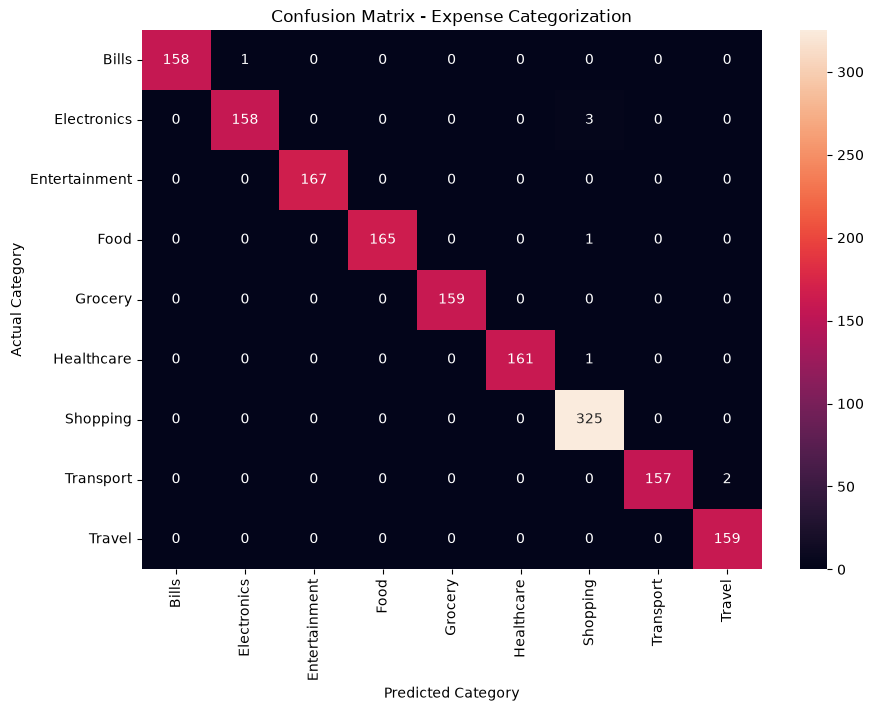

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.title("Confusion Matrix - Expense Categorization")
plt.show()

In [14]:
joblib.dump(model, "../models/category_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Category model saved successfully!")

Category model saved successfully!


In [15]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Check the date range
print("Start Date:", df["Date"].min())
print("End Date  :", df["Date"].max())

# Check amount information
print("\nAmount statistics:")
print(df["Amount"].describe())

Start Date: 2025-01-01 00:00:00
End Date  : 2026-01-01 00:00:00

Amount statistics:
count      8082.000000
mean      12434.748333
std       26089.252988
min          54.110000
25%         946.272500
50%        3236.150000
75%       11021.555000
max      149925.200000
Name: Amount, dtype: float64


In [16]:
# Load original dataset for expense prediction
regression_df = pd.read_csv(
    "../dataset/personal_finance_dataset_8000_extended.csv"
)

regression_df["Date"] = pd.to_datetime(regression_df["Date"])

print("Original dataset shape:", regression_df.shape)
print("Start Date:", regression_df["Date"].min())
print("End Date:", regression_df["Date"].max())

Original dataset shape: (8000, 15)
Start Date: 2025-01-01 00:00:00
End Date: 2025-12-31 00:00:00


In [17]:
monthly_expense = (
    regression_df.groupby(regression_df["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .reset_index()
)

monthly_expense["Date"] = monthly_expense["Date"].dt.to_timestamp()

print("Monthly spending:")
print(monthly_expense)

Monthly spending:
         Date      Amount
0  2025-01-01  8093666.23
1  2025-02-01  7327831.77
2  2025-03-01  9390091.29
3  2025-04-01  7937485.11
4  2025-05-01  8847821.63
5  2025-06-01  9018844.54
6  2025-07-01  8951073.24
7  2025-08-01  8692664.18
8  2025-09-01  8702808.39
9  2025-10-01  7022232.93
10 2025-11-01  8039843.94
11 2025-12-01  8391272.78


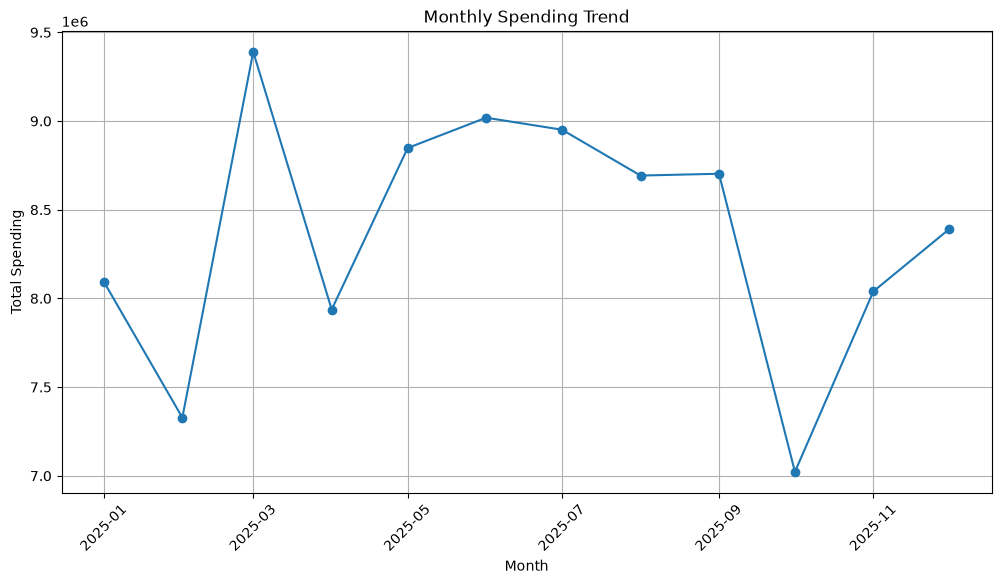

In [18]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_expense["Date"],
    monthly_expense["Amount"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Total Spending")
plt.title("Monthly Spending Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [19]:
# Create month number as the input feature
monthly_expense["Month_Number"] = range(1, len(monthly_expense) + 1)

X_reg = monthly_expense[["Month_Number"]]
y_reg = monthly_expense["Amount"]

print("X shape:", X_reg.shape)
print("y shape:", y_reg.shape)

print("\nRegression data:")
print(monthly_expense[["Date", "Month_Number", "Amount"]])

X shape: (12, 1)
y shape: (12,)

Regression data:
         Date  Month_Number      Amount
0  2025-01-01             1  8093666.23
1  2025-02-01             2  7327831.77
2  2025-03-01             3  9390091.29
3  2025-04-01             4  7937485.11
4  2025-05-01             5  8847821.63
5  2025-06-01             6  9018844.54
6  2025-07-01             7  8951073.24
7  2025-08-01             8  8692664.18
8  2025-09-01             9  8702808.39
9  2025-10-01            10  7022232.93
10 2025-11-01            11  8039843.94
11 2025-12-01            12  8391272.78


In [20]:
# Use the first 9 months for training
# Use the last 3 months for testing

X_train_reg = X_reg.iloc[:9]
X_test_reg = X_reg.iloc[9:]

y_train_reg = y_reg.iloc[:9]
y_test_reg = y_reg.iloc[9:]

print("Training data:")
print(X_train_reg)

print("\nTesting data:")
print(X_test_reg)

print("\nTraining samples:", len(X_train_reg))
print("Testing samples:", len(X_test_reg))

Training data:
   Month_Number
0             1
1             2
2             3
3             4
4             5
5             6
6             7
7             8
8             9

Testing data:
    Month_Number
9             10
10            11
11            12

Training samples: 9
Testing samples: 3


In [21]:
from sklearn.linear_model import LinearRegression

# Create and train the regression model
reg_model = LinearRegression()
reg_model.fit(X_train_reg, y_train_reg)

print("Regression model trained successfully!")

Regression model trained successfully!


In [22]:
# Predict spending for the test months
y_pred_reg = reg_model.predict(X_test_reg)

print("Actual vs Predicted Spending:\n")

for month, actual, predicted in zip(
    X_test_reg["Month_Number"],
    y_test_reg,
    y_pred_reg
):
    print(
        f"Month {month}: "
        f"Actual = ₹{actual:,.2f}, "
        f"Predicted = ₹{predicted:,.2f}"
    )

Actual vs Predicted Spending:

Month 10: Actual = ₹7,022,232.93, Predicted = ₹9,112,564.25
Month 11: Actual = ₹8,039,843.94, Predicted = ₹9,224,804.07
Month 12: Actual = ₹8,391,272.78, Predicted = ₹9,337,043.89


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate regression metrics
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Performance:")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Regression Model Performance:
MAE  : ₹1,407,020.86
RMSE : ₹1,490,872.07
R²   : -5.5949


In [24]:
# Create improved monthly regression dataset

monthly_reg = monthly_expense.copy()

# Previous month's spending
monthly_reg["Previous_Month"] = monthly_reg["Amount"].shift(1)

# Spending two months ago
monthly_reg["Two_Months_Ago"] = monthly_reg["Amount"].shift(2)

# Average spending of previous 3 months
monthly_reg["Three_Month_Average"] = (
    monthly_reg["Amount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

print("Improved regression dataset:")
print(monthly_reg)

Improved regression dataset:
         Date      Amount  Month_Number  Previous_Month  Two_Months_Ago  \
0  2025-01-01  8093666.23             1             NaN             NaN   
1  2025-02-01  7327831.77             2      8093666.23             NaN   
2  2025-03-01  9390091.29             3      7327831.77      8093666.23   
3  2025-04-01  7937485.11             4      9390091.29      7327831.77   
4  2025-05-01  8847821.63             5      7937485.11      9390091.29   
5  2025-06-01  9018844.54             6      8847821.63      7937485.11   
6  2025-07-01  8951073.24             7      9018844.54      8847821.63   
7  2025-08-01  8692664.18             8      8951073.24      9018844.54   
8  2025-09-01  8702808.39             9      8692664.18      8951073.24   
9  2025-10-01  7022232.93            10      8702808.39      8692664.18   
10 2025-11-01  8039843.94            11      7022232.93      8702808.39   
11 2025-12-01  8391272.78            12      8039843.94      7022232.93

In [25]:
# Remove rows with missing previous-spending values
monthly_reg_clean = monthly_reg.dropna().reset_index(drop=True)

print("Clean regression dataset:")
print(monthly_reg_clean)

print("\nNumber of samples:", len(monthly_reg_clean))

Clean regression dataset:
        Date      Amount  Month_Number  Previous_Month  Two_Months_Ago  \
0 2025-04-01  7937485.11             4      9390091.29      7327831.77   
1 2025-05-01  8847821.63             5      7937485.11      9390091.29   
2 2025-06-01  9018844.54             6      8847821.63      7937485.11   
3 2025-07-01  8951073.24             7      9018844.54      8847821.63   
4 2025-08-01  8692664.18             8      8951073.24      9018844.54   
5 2025-09-01  8702808.39             9      8692664.18      8951073.24   
6 2025-10-01  7022232.93            10      8702808.39      8692664.18   
7 2025-11-01  8039843.94            11      7022232.93      8702808.39   
8 2025-12-01  8391272.78            12      8039843.94      7022232.93   

   Three_Month_Average  
0         8.270530e+06  
1         8.218469e+06  
2         8.725133e+06  
3         8.601384e+06  
4         8.939246e+06  
5         8.887527e+06  
6         8.782182e+06  
7         8.139235e+06  
8       

In [26]:
# Define input features and target

X_reg_improved = monthly_reg_clean[
    ["Previous_Month", "Two_Months_Ago", "Three_Month_Average"]
]

y_reg_improved = monthly_reg_clean["Amount"]

print("Input features (X):")
print(X_reg_improved)

print("\nTarget (y):")
print(y_reg_improved)

Input features (X):
   Previous_Month  Two_Months_Ago  Three_Month_Average
0      9390091.29      7327831.77         8.270530e+06
1      7937485.11      9390091.29         8.218469e+06
2      8847821.63      7937485.11         8.725133e+06
3      9018844.54      8847821.63         8.601384e+06
4      8951073.24      9018844.54         8.939246e+06
5      8692664.18      8951073.24         8.887527e+06
6      8702808.39      8692664.18         8.782182e+06
7      7022232.93      8702808.39         8.139235e+06
8      8039843.94      7022232.93         7.921628e+06

Target (y):
0    7937485.11
1    8847821.63
2    9018844.54
3    8951073.24
4    8692664.18
5    8702808.39
6    7022232.93
7    8039843.94
8    8391272.78
Name: Amount, dtype: float64


In [27]:
# Chronological train-test split

X_train_improved = X_reg_improved.iloc[:6]
X_test_improved = X_reg_improved.iloc[6:]

y_train_improved = y_reg_improved.iloc[:6]
y_test_improved = y_reg_improved.iloc[6:]

print("Training samples:", len(X_train_improved))
print("Testing samples:", len(X_test_improved))

print("\nTraining target:")
print(y_train_improved)

print("\nTesting target:")
print(y_test_improved)

Training samples: 6
Testing samples: 3

Training target:
0    7937485.11
1    8847821.63
2    9018844.54
3    8951073.24
4    8692664.18
5    8702808.39
Name: Amount, dtype: float64

Testing target:
6    7022232.93
7    8039843.94
8    8391272.78
Name: Amount, dtype: float64


In [28]:
# Train the improved Linear Regression model

improved_reg_model = LinearRegression()

improved_reg_model.fit(
    X_train_improved,
    y_train_improved
)

print("Improved regression model trained successfully!")

Improved regression model trained successfully!


In [29]:
# Make predictions using the improved regression model

y_pred_improved = improved_reg_model.predict(X_test_improved)

print("Improved Model - Actual vs Predicted Spending:\n")

for month, actual, predicted in zip(
    monthly_reg_clean.iloc[6:]["Date"],
    y_test_improved,
    y_pred_improved
):
    print(
        f"{month.strftime('%B %Y')}: "
        f"Actual = ₹{actual:,.2f}, "
        f"Predicted = ₹{predicted:,.2f}"
    )

Improved Model - Actual vs Predicted Spending:

October 2025: Actual = ₹7,022,232.93, Predicted = ₹8,861,499.25
November 2025: Actual = ₹8,039,843.94, Predicted = ₹9,276,774.13
December 2025: Actual = ₹8,391,272.78, Predicted = ₹8,591,741.75


In [30]:
# Calculate metrics for the improved regression model

mae_improved = mean_absolute_error(
    y_test_improved,
    y_pred_improved
)

rmse_improved = np.sqrt(
    mean_squared_error(
        y_test_improved,
        y_pred_improved
    )
)

r2_improved = r2_score(
    y_test_improved,
    y_pred_improved
)

print("Improved Regression Model Performance:")
print(f"MAE  : ₹{mae_improved:,.2f}")
print(f"RMSE : ₹{rmse_improved:,.2f}")
print(f"R²   : {r2_improved:.4f}")

Improved Regression Model Performance:
MAE  : ₹1,092,221.83
RMSE : ₹1,284,923.43
R²   : -3.8987


In [31]:
# Step 30: Prepare monthly spending data for improved regression

regression_df = pd.read_csv(
    "../dataset/personal_finance_dataset_8000_extended.csv"
)

regression_df["Date"] = pd.to_datetime(regression_df["Date"])

# Aggregate daily spending
daily_expense = (
    regression_df.groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

daily_expense.head()

,Date,Amount
0,2025-01-01,296956.65
1,2025-01-02,96903.60
2,2025-01-03,203710.83
3,2025-01-04,236549.88
4,2025-01-05,96069.13


In [32]:
# Step 31: Create previous-spending features

daily_reg = daily_expense.copy()

# Previous day's spending
daily_reg["Previous_Day"] = daily_reg["Amount"].shift(1)

# Spending two days ago
daily_reg["Two_Days_Ago"] = daily_reg["Amount"].shift(2)

# 7-day average of previous spending
daily_reg["Previous_7_Day_Average"] = (
    daily_reg["Amount"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_reg.head(10)

,Date,Amount,Previous_Day,Two_Days_Ago,Previous_7_Day_Average
0,2025-01-01,296956.65,NaN,NaN,NaN
1,2025-01-02,96903.60,296956.65,NaN,NaN
2,2025-01-03,203710.83,96903.60,296956.65,NaN
3,2025-01-04,236549.88,203710.83,96903.60,NaN
4,2025-01-05,96069.13,236549.88,203710.83,NaN
5,2025-01-06,424732.41,96069.13,236549.88,NaN
6,2025-01-07,99195.59,424732.41,96069.13,NaN
7,2025-01-08,139947.53,99195.59,424732.41,207731.155714
8,2025-01-09,95557.02,139947.53,99195.59,185301.281429
9,2025-01-10,187295.74,95557.02,139947.53,185108.912857


In [33]:
# Step 32: Remove rows with missing lag/rolling features

daily_reg_clean = daily_reg.dropna().reset_index(drop=True)

print("Original rows:", len(daily_reg))
print("Rows after removing NaN:", len(daily_reg_clean))

daily_reg_clean.head()

Original rows: 365
Rows after removing NaN: 358


,Date,Amount,Previous_Day,Two_Days_Ago,Previous_7_Day_Average
0,2025-01-08,139947.53,99195.59,424732.41,207731.155714
1,2025-01-09,95557.02,139947.53,99195.59,185301.281429
2,2025-01-10,187295.74,95557.02,139947.53,185108.912857
3,2025-01-11,504532.72,187295.74,95557.02,182763.900000
4,2025-01-12,211743.88,504532.72,187295.74,221047.162857


In [34]:
# Step 33: Chronological train-test split

features = [
    "Previous_Day",
    "Two_Days_Ago",
    "Previous_7_Day_Average"
]

X_daily_reg = daily_reg_clean[features]
y_daily_reg = daily_reg_clean["Amount"]

# Use first 80% for training and last 20% for testing
split_index = int(len(daily_reg_clean) * 0.8)

X_train_daily = X_daily_reg.iloc[:split_index]
X_test_daily = X_daily_reg.iloc[split_index:]

y_train_daily = y_daily_reg.iloc[:split_index]
y_test_daily = y_daily_reg.iloc[split_index:]

print("Training samples:", len(X_train_daily))
print("Testing samples:", len(X_test_daily))

print("\nTraining period:")
print(
    daily_reg_clean.iloc[0]["Date"],
    "to",
    daily_reg_clean.iloc[split_index - 1]["Date"]
)

print("\nTesting period:")
print(
    daily_reg_clean.iloc[split_index]["Date"],
    "to",
    daily_reg_clean.iloc[-1]["Date"]
)

Training samples: 286
Testing samples: 72

Training period:
2025-01-08 00:00:00 to 2025-10-20 00:00:00

Testing period:
2025-10-21 00:00:00 to 2025-12-31 00:00:00


In [35]:
# Step 34: Train the improved regression model

from sklearn.linear_model import LinearRegression

daily_reg_model = LinearRegression()

daily_reg_model.fit(
    X_train_daily,
    y_train_daily
)

print("Improved daily regression model trained successfully.")

Improved daily regression model trained successfully.


In [36]:
# Step 35: Generate predictions on the test data

y_pred_daily = daily_reg_model.predict(X_test_daily)

print("Actual vs Predicted Daily Spending:\n")

for date, actual, predicted in zip(
    daily_reg_clean.iloc[split_index:]["Date"],
    y_test_daily,
    y_pred_daily
):
    print(
        f"{date.strftime('%d %b %Y')}: "
        f"Actual = ₹{actual:,.2f}, "
        f"Predicted = ₹{predicted:,.2f}"
    )

Actual vs Predicted Daily Spending:

21 Oct 2025: Actual = ₹143,606.29, Predicted = ₹271,692.18
22 Oct 2025: Actual = ₹260,226.30, Predicted = ₹263,638.08
23 Oct 2025: Actual = ₹409,076.17, Predicted = ₹271,496.16
24 Oct 2025: Actual = ₹294,149.87, Predicted = ₹267,442.75
25 Oct 2025: Actual = ₹272,141.62, Predicted = ₹265,312.72
26 Oct 2025: Actual = ₹206,975.24, Predicted = ₹272,941.30
27 Oct 2025: Actual = ₹620,015.89, Predicted = ₹278,293.95
28 Oct 2025: Actual = ₹139,281.26, Predicted = ₹282,443.72
29 Oct 2025: Actual = ₹309,778.08, Predicted = ₹272,530.56
30 Oct 2025: Actual = ₹258,084.89, Predicted = ₹291,681.60
31 Oct 2025: Actual = ₹179,182.76, Predicted = ₹281,052.85
01 Nov 2025: Actual = ₹318,067.51, Predicted = ₹281,377.53
02 Nov 2025: Actual = ₹378,593.20, Predicted = ₹283,747.73
03 Nov 2025: Actual = ₹179,067.38, Predicted = ₹281,560.53
04 Nov 2025: Actual = ₹368,151.95, Predicted = ₹270,038.10
05 Nov 2025: Actual = ₹583,734.51, Predicted = ₹281,811.31
06 Nov 2025: Actual

In [37]:
# Step 36: Evaluate the improved daily regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_daily = mean_absolute_error(
    y_test_daily,
    y_pred_daily
)

rmse_daily = np.sqrt(
    mean_squared_error(
        y_test_daily,
        y_pred_daily
    )
)

r2_daily = r2_score(
    y_test_daily,
    y_pred_daily
)

print("Improved Daily Regression Model Performance:")
print(f"MAE  : ₹{mae_daily:,.2f}")
print(f"RMSE : ₹{rmse_daily:,.2f}")
print(f"R²   : {r2_daily:.4f}")

Improved Daily Regression Model Performance:
MAE  : ₹110,186.33
RMSE : ₹134,095.39
R²   : 0.0078


In [38]:
# Step 37: Create monthly spending features

monthly_model = monthly_expense.copy()

# Previous spending features
monthly_model["Previous_Month"] = monthly_model["Amount"].shift(1)
monthly_model["Two_Months_Ago"] = monthly_model["Amount"].shift(2)

monthly_model["Three_Month_Average"] = (
    monthly_model["Amount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Additional monthly information from daily transactions
monthly_stats = (
    regression_df.groupby(
        regression_df["Date"].dt.to_period("M")
    )
    .agg(
        Transaction_Count=("Amount", "count"),
        Average_Transaction=("Amount", "mean")
    )
    .reset_index()
)

monthly_stats["Date"] = monthly_stats["Date"].dt.to_timestamp()

# Combine the statistics with monthly spending
monthly_model = monthly_model.merge(
    monthly_stats,
    on="Date",
    how="left"
)

# Month number
monthly_model["Month_Number"] = monthly_model["Date"].dt.month

monthly_model

,Date,Amount,Month_Number,Previous_Month,Two_Months_Ago,Three_Month_Average,Transaction_Count,Average_Transaction
0,2025-01-01,8093666.23,1,NaN,NaN,NaN,690,11729.951058
1,2025-02-01,7327831.77,2,8093666.23,NaN,NaN,617,11876.550681
2,2025-03-01,9390091.29,3,7327831.77,8093666.23,NaN,722,13005.666607
3,2025-04-01,7937485.11,4,9390091.29,7327831.77,8.270530e+06,622,12761.230080
4,2025-05-01,8847821.63,5,7937485.11,9390091.29,8.218469e+06,683,12954.350849
5,2025-06-01,9018844.54,6,8847821.63,7937485.11,8.725133e+06,689,13089.759855
6,2025-07-01,8951073.24,7,9018844.54,8847821.63,8.601384e+06,694,12897.800058
7,2025-08-01,8692664.18,8,8951073.24,9018844.54,8.939246e+06,686,12671.522128
8,2025-09-01,8702808.39,9,8692664.18,8951073.24,8.887527e+06,661,13166.124644
9,2025-10-01,7022232.93,10,8702808.39,8692664.18,8.782182e+06,651,10786.840138


In [39]:
# Step 38: Check monthly statistics

print(monthly_stats)

print("\nMissing values in monthly_model:")
print(monthly_model.isnull().sum())

         Date  Transaction_Count  Average_Transaction
0  2025-01-01                690         11729.951058
1  2025-02-01                617         11876.550681
2  2025-03-01                722         13005.666607
3  2025-04-01                622         12761.230080
4  2025-05-01                683         12954.350849
5  2025-06-01                689         13089.759855
6  2025-07-01                694         12897.800058
7  2025-08-01                686         12671.522128
8  2025-09-01                661         13166.124644
9  2025-10-01                651         10786.840138
10 2025-11-01                587         13696.497342
11 2025-12-01                698         12021.880774

Missing values in monthly_model:
Date                   0
Amount                 0
Month_Number           0
Previous_Month         1
Two_Months_Ago         2
Three_Month_Average    3
Transaction_Count      0
Average_Transaction    0
dtype: int64


In [40]:
# Step 38: Prepare final monthly regression dataset

monthly_reg_final = monthly_model.dropna().reset_index(drop=True)

features_monthly = [
    "Previous_Month",
    "Two_Months_Ago",
    "Three_Month_Average",
    "Transaction_Count",
    "Average_Transaction"
]

X_monthly = monthly_reg_final[features_monthly]
y_monthly = monthly_reg_final["Amount"]

print("Final regression dataset shape:", monthly_reg_final.shape)

print("\nFeatures:")
print(features_monthly)

print("\nTarget:")
print("Monthly Spending")

monthly_reg_final

Final regression dataset shape: (9, 8)

Features:
['Previous_Month', 'Two_Months_Ago', 'Three_Month_Average', 'Transaction_Count', 'Average_Transaction']

Target:
Monthly Spending


,Date,Amount,Month_Number,Previous_Month,Two_Months_Ago,Three_Month_Average,Transaction_Count,Average_Transaction
0,2025-04-01,7937485.11,4,9390091.29,7327831.77,8.270530e+06,622,12761.230080
1,2025-05-01,8847821.63,5,7937485.11,9390091.29,8.218469e+06,683,12954.350849
2,2025-06-01,9018844.54,6,8847821.63,7937485.11,8.725133e+06,689,13089.759855
3,2025-07-01,8951073.24,7,9018844.54,8847821.63,8.601384e+06,694,12897.800058
4,2025-08-01,8692664.18,8,8951073.24,9018844.54,8.939246e+06,686,12671.522128
5,2025-09-01,8702808.39,9,8692664.18,8951073.24,8.887527e+06,661,13166.124644
6,2025-10-01,7022232.93,10,8702808.39,8692664.18,8.782182e+06,651,10786.840138
7,2025-11-01,8039843.94,11,7022232.93,8702808.39,8.139235e+06,587,13696.497342
8,2025-12-01,8391272.78,12,8039843.94,7022232.93,7.921628e+06,698,12021.880774


In [41]:
# Step 39: Create leakage-free monthly regression features

monthly_model_clean = monthly_expense.copy()

# Previous spending features
monthly_model_clean["Previous_Month"] = monthly_model_clean["Amount"].shift(1)
monthly_model_clean["Two_Months_Ago"] = monthly_model_clean["Amount"].shift(2)

monthly_model_clean["Three_Month_Average"] = (
    monthly_model_clean["Amount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Previous month's transaction statistics
monthly_model_clean["Previous_Month_Transaction_Count"] = (
    monthly_model_clean["Transaction_Count"] if "Transaction_Count" in monthly_model_clean.columns
    else regression_df.groupby(
        regression_df["Date"].dt.to_period("M")
    )["Amount"].count().shift(1).values
)

# Create monthly transaction statistics separately
monthly_stats_clean = (
    regression_df.groupby(
        regression_df["Date"].dt.to_period("M")
    )
    .agg(
        Transaction_Count=("Amount", "count"),
        Average_Transaction=("Amount", "mean")
    )
    .reset_index()
)

monthly_stats_clean["Date"] = monthly_stats_clean["Date"].dt.to_timestamp()

# Merge statistics
monthly_model_clean = monthly_model_clean.merge(
    monthly_stats_clean,
    on="Date",
    how="left"
)

# Shift them so only previous-month information is used
monthly_model_clean["Previous_Month_Transaction_Count"] = (
    monthly_model_clean["Transaction_Count"].shift(1)
)

monthly_model_clean["Previous_Month_Average_Transaction"] = (
    monthly_model_clean["Average_Transaction"].shift(1)
)

# Keep only leakage-free features
features_monthly = [
    "Previous_Month",
    "Two_Months_Ago",
    "Three_Month_Average",
    "Previous_Month_Transaction_Count",
    "Previous_Month_Average_Transaction"
]

monthly_reg_final = (
    monthly_model_clean[
        ["Date", "Amount"] + features_monthly
    ]
    .dropna()
    .reset_index(drop=True)
)

print("Final regression dataset shape:", monthly_reg_final.shape)

print("\nFeatures used:")
print(features_monthly)

print("\nFinal monthly regression dataset:")
display(monthly_reg_final)

Final regression dataset shape: (9, 7)

Features used:
['Previous_Month', 'Two_Months_Ago', 'Three_Month_Average', 'Previous_Month_Transaction_Count', 'Previous_Month_Average_Transaction']

Final monthly regression dataset:


,Date,Amount,Previous_Month,Two_Months_Ago,Three_Month_Average,Previous_Month_Transaction_Count,Previous_Month_Average_Transaction
0,2025-04-01,7937485.11,9390091.29,7327831.77,8.270530e+06,722.0,13005.666607
1,2025-05-01,8847821.63,7937485.11,9390091.29,8.218469e+06,622.0,12761.230080
2,2025-06-01,9018844.54,8847821.63,7937485.11,8.725133e+06,683.0,12954.350849
3,2025-07-01,8951073.24,9018844.54,8847821.63,8.601384e+06,689.0,13089.759855
4,2025-08-01,8692664.18,8951073.24,9018844.54,8.939246e+06,694.0,12897.800058
5,2025-09-01,8702808.39,8692664.18,8951073.24,8.887527e+06,686.0,12671.522128
6,2025-10-01,7022232.93,8702808.39,8692664.18,8.782182e+06,661.0,13166.124644
7,2025-11-01,8039843.94,7022232.93,8702808.39,8.139235e+06,651.0,10786.840138
8,2025-12-01,8391272.78,8039843.94,7022232.93,7.921628e+06,587.0,13696.497342


In [42]:
# Step 40: Train the monthly regression model

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X_monthly = monthly_reg_final[features_monthly]
y_monthly = monthly_reg_final["Amount"]

# Chronological split
# First 6 months for training, last 3 months for testing
X_train_monthly = X_monthly.iloc[:6]
X_test_monthly = X_monthly.iloc[6:]

y_train_monthly = y_monthly.iloc[:6]
y_test_monthly = y_monthly.iloc[6:]

# Train model
monthly_reg_model = LinearRegression()
monthly_reg_model.fit(X_train_monthly, y_train_monthly)

# Predict
y_pred_monthly = monthly_reg_model.predict(X_test_monthly)

# Evaluation
mae_monthly = mean_absolute_error(y_test_monthly, y_pred_monthly)
rmse_monthly = np.sqrt(mean_squared_error(y_test_monthly, y_pred_monthly))
r2_monthly = r2_score(y_test_monthly, y_pred_monthly)

print("Monthly Regression Model Performance")
print("------------------------------------")
print(f"MAE  : ₹{mae_monthly:,.2f}")
print(f"RMSE : ₹{rmse_monthly:,.2f}")
print(f"R²   : {r2_monthly:.4f}")

# Actual vs Predicted
comparison_monthly = pd.DataFrame({
    "Date": monthly_reg_final["Date"].iloc[6:].values,
    "Actual": y_test_monthly.values,
    "Predicted": y_pred_monthly
})

print("\nActual vs Predicted Monthly Spending:")
display(comparison_monthly)

Monthly Regression Model Performance
------------------------------------
MAE  : ₹2,604,388.40
RMSE : ₹2,605,151.46
R²   : -19.1369

Actual vs Predicted Monthly Spending:


,Date,Actual,Predicted
0,2025-10-01,7022232.93,9.655001e+06
1,2025-11-01,8039843.94,5.376442e+06
2,2025-12-01,8391272.78,1.090827e+07


In [43]:
# Step 41: Train the best-performing monthly regression model

# Use the original lag-based features
best_features = [
    "Previous_Month",
    "Two_Months_Ago",
    "Three_Month_Average"
]

# Prepare data
monthly_best = monthly_expense.copy()

monthly_best["Previous_Month"] = monthly_best["Amount"].shift(1)
monthly_best["Two_Months_Ago"] = monthly_best["Amount"].shift(2)

monthly_best["Three_Month_Average"] = (
    monthly_best["Amount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

monthly_best = monthly_best.dropna().reset_index(drop=True)

X_best = monthly_best[best_features]
y_best = monthly_best["Amount"]

# Chronological split
X_train_best = X_best.iloc[:6]
X_test_best = X_best.iloc[6:]

y_train_best = y_best.iloc[:6]
y_test_best = y_best.iloc[6:]

# Train model
best_reg_model = LinearRegression()
best_reg_model.fit(X_train_best, y_train_best)

# Predictions
y_pred_best = best_reg_model.predict(X_test_best)

# Metrics
best_mae = mean_absolute_error(y_test_best, y_pred_best)
best_rmse = np.sqrt(mean_squared_error(y_test_best, y_pred_best))
best_r2 = r2_score(y_test_best, y_pred_best)

print("Best Monthly Regression Model Performance")
print("-----------------------------------------")
print(f"MAE  : ₹{best_mae:,.2f}")
print(f"RMSE : ₹{best_rmse:,.2f}")
print(f"R²   : {best_r2:.4f}")

# Actual vs Predicted
best_comparison = pd.DataFrame({
    "Date": monthly_best["Date"].iloc[6:].values,
    "Actual": y_test_best.values,
    "Predicted": y_pred_best
})

print("\nActual vs Predicted Monthly Spending:")
display(best_comparison)

Best Monthly Regression Model Performance
-----------------------------------------
MAE  : ₹1,092,221.83
RMSE : ₹1,284,923.43
R²   : -3.8987

Actual vs Predicted Monthly Spending:


,Date,Actual,Predicted
0,2025-10-01,7022232.93,8.861499e+06
1,2025-11-01,8039843.94,9.276774e+06
2,2025-12-01,8391272.78,8.591742e+06


In [44]:
# Step 43: Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

# Train the model
rf_model.fit(X_train_best, y_train_best)

# Predict test data
y_pred_rf = rf_model.predict(X_test_best)

# Evaluation
rf_mae = mean_absolute_error(y_test_best, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test_best, y_pred_rf))
rf_r2 = r2_score(y_test_best, y_pred_rf)

print("Random Forest Regression Performance")
print("------------------------------------")
print(f"MAE  : ₹{rf_mae:,.2f}")
print(f"RMSE : ₹{rf_rmse:,.2f}")
print(f"R²   : {rf_r2:.4f}")

# Actual vs Predicted
rf_comparison = pd.DataFrame({
    "Date": monthly_best["Date"].iloc[6:].values,
    "Actual": y_test_best.values,
    "Predicted": y_pred_rf
})

print("\nActual vs Predicted Monthly Spending:")
display(rf_comparison)

Random Forest Regression Performance
------------------------------------
MAE  : ₹854,303.79
RMSE : ₹1,135,411.60
R²   : -2.8250

Actual vs Predicted Monthly Spending:


,Date,Actual,Predicted
0,2025-10-01,7022232.93,8.849544e+06
1,2025-11-01,8039843.94,8.766712e+06
2,2025-12-01,8391272.78,8.400005e+06


In [45]:
# Create improved monthly regression features

monthly_rf = monthly_expense.copy()

# Previous month spending
monthly_rf["Previous_Month"] = monthly_rf["Amount"].shift(1)

# Spending two months ago
monthly_rf["Two_Months_Ago"] = monthly_rf["Amount"].shift(2)

# Spending three months ago
monthly_rf["Three_Months_Ago"] = monthly_rf["Amount"].shift(3)

# 3-month moving average of previous months
monthly_rf["Three_Month_Average"] = (
    monthly_rf["Amount"].shift(1).rolling(window=3).mean()
)

# Month number
monthly_rf["Month_Number"] = monthly_rf["Date"].dt.month

# Remove rows where historical features are unavailable
monthly_rf = monthly_rf.dropna().reset_index(drop=True)

monthly_rf

,Date,Amount,Month_Number,Previous_Month,Two_Months_Ago,Three_Months_Ago,Three_Month_Average
0,2025-04-01,7937485.11,4,9390091.29,7327831.77,8093666.23,8.270530e+06
1,2025-05-01,8847821.63,5,7937485.11,9390091.29,7327831.77,8.218469e+06
2,2025-06-01,9018844.54,6,8847821.63,7937485.11,9390091.29,8.725133e+06
3,2025-07-01,8951073.24,7,9018844.54,8847821.63,7937485.11,8.601384e+06
4,2025-08-01,8692664.18,8,8951073.24,9018844.54,8847821.63,8.939246e+06
5,2025-09-01,8702808.39,9,8692664.18,8951073.24,9018844.54,8.887527e+06
6,2025-10-01,7022232.93,10,8702808.39,8692664.18,8951073.24,8.782182e+06
7,2025-11-01,8039843.94,11,7022232.93,8702808.39,8692664.18,8.139235e+06
8,2025-12-01,8391272.78,12,8039843.94,7022232.93,8702808.39,7.921628e+06


In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features for the model
features = [
    "Previous_Month",
    "Two_Months_Ago",
    "Three_Months_Ago",
    "Three_Month_Average",
    "Month_Number"
]

X = monthly_rf[features]
y = monthly_rf["Amount"]

# Time-based split
# First 6 months for training, last 3 months for testing
X_train = X.iloc[:6]
X_test = X.iloc[6:]

y_train = y.iloc[:6]
y_test = y.iloc[6:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("\nTraining months:")
print(monthly_rf["Date"].iloc[:6].dt.strftime("%B %Y").tolist())

print("\nTesting months:")
print(monthly_rf["Date"].iloc[6:].dt.strftime("%B %Y").tolist())

Training samples: 6
Testing samples: 3

Training months:
['April 2025', 'May 2025', 'June 2025', 'July 2025', 'August 2025', 'September 2025']

Testing months:
['October 2025', 'November 2025', 'December 2025']


In [47]:
# Train Random Forest Regression model

rf_model_improved = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model_improved.fit(X_train, y_train)

# Predict on test data
y_pred_rf_improved = rf_model_improved.predict(X_test)

print("Predictions:")
for actual_date, actual, predicted in zip(
    monthly_rf["Date"].iloc[6:],
    y_test,
    y_pred_rf_improved
):
    print(
        f"{actual_date.strftime('%B %Y')}: "
        f"Actual = ₹{actual:,.2f}, "
        f"Predicted = ₹{predicted:,.2f}"
    )

Predictions:
October 2025: Actual = ₹7,022,232.93, Predicted = ₹8,790,355.71
November 2025: Actual = ₹8,039,843.94, Predicted = ₹8,751,205.17
December 2025: Actual = ₹8,391,272.78, Predicted = ₹8,615,080.94


In [48]:
# Evaluate improved Random Forest model

mae_improved = mean_absolute_error(y_test, y_pred_rf_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test, y_pred_rf_improved))
r2_improved = r2_score(y_test, y_pred_rf_improved)

print(f"MAE  : ₹{mae_improved:,.2f}")
print(f"RMSE : ₹{rmse_improved:,.2f}")
print(f"R²   : {r2_improved:.4f}")

MAE  : ₹901,097.39
RMSE : ₹1,107,908.40
R²   : -2.6420


In [49]:
# Create daily spending data

daily_expense = (
    regression_df.groupby("Date")["Amount"]
    .sum()
    .reset_index()
)

# Create historical daily features
daily_reg = daily_expense.copy()

daily_reg["Previous_Day"] = daily_reg["Amount"].shift(1)

daily_reg["Previous_7_Day_Average"] = (
    daily_reg["Amount"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_reg["Previous_30_Day_Average"] = (
    daily_reg["Amount"]
    .shift(1)
    .rolling(window=30)
    .mean()
)

daily_reg["Month_Number"] = daily_reg["Date"].dt.month

daily_reg["Day_Number"] = daily_reg["Date"].dt.day

# Remove rows where historical features are unavailable
daily_reg = daily_reg.dropna().reset_index(drop=True)

print("Daily records:", len(daily_reg))
print("\nFeatures:")
print(daily_reg.columns.tolist())

daily_reg.head()

Daily records: 335

Features:
['Date', 'Amount', 'Previous_Day', 'Previous_7_Day_Average', 'Previous_30_Day_Average', 'Month_Number', 'Day_Number']


,Date,Amount,Previous_Day,Previous_7_Day_Average,Previous_30_Day_Average,Month_Number,Day_Number
0,2025-01-31,154227.56,86819.86,214699.115714,264647.955667,1,31
1,2025-02-01,138149.01,154227.56,186019.985714,259890.319333,2,1
2,2025-02-02,114189.69,138149.01,181953.682857,261265.166333,2,2
3,2025-02-03,160032.39,114189.69,174709.980000,258281.128333,2,3
4,2025-02-04,569904.36,160032.39,187267.962857,255730.545333,2,4


In [50]:
# Create monthly regression dataset from daily spending

monthly_daily_rf = daily_expense.copy()

# Create year-month
monthly_daily_rf["YearMonth"] = monthly_daily_rf["Date"].dt.to_period("M")

# Monthly total spending
monthly_totals = (
    monthly_daily_rf
    .groupby("YearMonth")["Amount"]
    .sum()
    .reset_index()
)

monthly_totals["Date"] = monthly_totals["YearMonth"].dt.to_timestamp()

# Previous month spending
monthly_totals["Previous_Month"] = monthly_totals["Amount"].shift(1)

# Spending two months ago
monthly_totals["Two_Months_Ago"] = monthly_totals["Amount"].shift(2)

# Spending three months ago
monthly_totals["Three_Months_Ago"] = monthly_totals["Amount"].shift(3)

# Average of previous 3 months
monthly_totals["Three_Month_Average"] = (
    monthly_totals["Amount"]
    .shift(1)
    .rolling(window=3)
    .mean()
)

# Month number
monthly_totals["Month_Number"] = monthly_totals["Date"].dt.month

# Remove rows without enough historical data
monthly_daily_rf = monthly_totals.dropna().reset_index(drop=True)

print("Monthly samples:", len(monthly_daily_rf))
print("\nFeatures:")
print(monthly_daily_rf.columns.tolist())

monthly_daily_rf

Monthly samples: 9

Features:
['YearMonth', 'Amount', 'Date', 'Previous_Month', 'Two_Months_Ago', 'Three_Months_Ago', 'Three_Month_Average', 'Month_Number']


,YearMonth,Amount,Date,Previous_Month,Two_Months_Ago,Three_Months_Ago,Three_Month_Average,Month_Number
0,2025-04,7937485.11,2025-04-01,9390091.29,7327831.77,8093666.23,8.270530e+06,4
1,2025-05,8847821.63,2025-05-01,7937485.11,9390091.29,7327831.77,8.218469e+06,5
2,2025-06,9018844.54,2025-06-01,8847821.63,7937485.11,9390091.29,8.725133e+06,6
3,2025-07,8951073.24,2025-07-01,9018844.54,8847821.63,7937485.11,8.601384e+06,7
4,2025-08,8692664.18,2025-08-01,8951073.24,9018844.54,8847821.63,8.939246e+06,8
5,2025-09,8702808.39,2025-09-01,8692664.18,8951073.24,9018844.54,8.887527e+06,9
6,2025-10,7022232.93,2025-10-01,8702808.39,8692664.18,8951073.24,8.782182e+06,10
7,2025-11,8039843.94,2025-11-01,7022232.93,8702808.39,8692664.18,8.139235e+06,11
8,2025-12,8391272.78,2025-12-01,8039843.94,7022232.93,8702808.39,7.921628e+06,12


In [51]:
# Train final Random Forest Regression model

final_regression_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

final_regression_model.fit(
    monthly_daily_rf[features],
    monthly_daily_rf["Amount"]
)

# Save the final model
joblib.dump(
    final_regression_model,
    "../models/regression_model.pkl"
)

print("Final regression model saved successfully!")

Final regression model saved successfully!


In [52]:
# Load original transaction dataset for anomaly detection

anomaly_df = pd.read_csv("../dataset/personal_finance_dataset_8000_extended.csv")

# Select the transaction amount
anomaly_data = anomaly_df[["Amount"]].copy()

print("Total transactions:", len(anomaly_data))
print("\nAmount statistics:")
print(anomaly_data["Amount"].describe())

Total transactions: 8000

Amount statistics:
count      8000.000000
mean      12551.954504
std       26196.803575
min          54.110000
25%         938.920000
50%        3328.625000
75%       11173.300000
max      149925.200000
Name: Amount, dtype: float64


In [53]:
from sklearn.ensemble import IsolationForest

# Create Isolation Forest model
isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# Train the model
isolation_model.fit(anomaly_data)

# Predict anomalies
anomaly_predictions = isolation_model.predict(anomaly_data)

# Convert predictions:
#  1  = Normal
# -1  = Unusual
anomaly_df["Anomaly"] = anomaly_predictions

# Count results
normal_count = (anomaly_predictions == 1).sum()
unusual_count = (anomaly_predictions == -1).sum()

print("Normal transactions :", normal_count)
print("Unusual transactions:", unusual_count)
print("Total transactions  :", len(anomaly_predictions))

Normal transactions : 7600
Unusual transactions: 400
Total transactions  : 8000


In [54]:
# Display unusual transactions

unusual_transactions = anomaly_df[
    anomaly_df["Anomaly"] == -1
].sort_values("Amount", ascending=False)

print("Number of unusual transactions:", len(unusual_transactions))

unusual_transactions[
    ["Date", "Description", "Amount", "Category", "PaymentMethod"]
].head(20)

Number of unusual transactions: 400


,Date,Description,Amount,Category,PaymentMethod
7230,2025-01-21,Transaction at Apple Store,149925.20,Electronics,Credit Card
4046,2025-05-26,Transaction at Apple Store,149836.10,Electronics,Net Banking
6238,2025-05-28,Transaction at Dell Exclusive,149827.58,Electronics,Net Banking
513,2025-11-08,Transaction at Noise,149809.51,Electronics,UPI
3224,2025-08-29,Transaction at OnePlus,149807.19,Electronics,Debit Card
6140,2025-04-24,Transaction at HP World,149737.72,Electronics,Debit Card
5122,2025-07-14,Transaction at Croma,149593.13,Electronics,Debit Card
598,2025-10-13,Transaction at Noise,149349.96,Electronics,UPI
172,2025-02-14,Transaction at OnePlus,149197.11,Electronics,Debit Card
1546,2025-01-11,Transaction at Samsung Store,149113.60,Electronics,Net Banking


In [55]:
# Create behavioral features for anomaly detection

anomaly_features = anomaly_df.copy()

# Convert date
anomaly_features["Date"] = pd.to_datetime(anomaly_features["Date"])

# Basic spending features
anomaly_features["Amount_Log"] = np.log1p(anomaly_features["Amount"])

# Extract time-related information
anomaly_features["Hour"] = pd.to_datetime(
    anomaly_features["TimeOfDay"],
    format="%H:%M",
    errors="coerce"
).dt.hour

# Encode categorical behavior
anomaly_features["TransactionType_Code"] = (
    anomaly_features["TransactionType"].astype("category").cat.codes
)

anomaly_features["PaymentMethod_Code"] = (
    anomaly_features["PaymentMethod"].astype("category").cat.codes
)

anomaly_features["Category_Code"] = (
    anomaly_features["Category"].astype("category").cat.codes
)

# Select features for Isolation Forest
X_anomaly = anomaly_features[
    [
        "Amount",
        "Amount_Log",
        "Hour",
        "TransactionType_Code",
        "PaymentMethod_Code",
        "Category_Code"
    ]
].copy()

print("Feature dataset shape:", X_anomaly.shape)
print("\nFeatures used:")
print(X_anomaly.columns.tolist())

print("\nMissing values:")
print(X_anomaly.isnull().sum())

Feature dataset shape: (8000, 6)

Features used:
['Amount', 'Amount_Log', 'Hour', 'TransactionType_Code', 'PaymentMethod_Code', 'Category_Code']

Missing values:
Amount                     0
Amount_Log                 0
Hour                    8000
TransactionType_Code       0
PaymentMethod_Code         0
Category_Code              0
dtype: int64


In [56]:
print(anomaly_df["TimeOfDay"].head(10))
print(anomaly_df["TimeOfDay"].unique()[:20])

0        Night
1      Evening
2      Evening
3    Afternoon
4      Evening
5      Morning
6      Morning
7      Morning
8    Afternoon
9      Morning
Name: TimeOfDay, dtype: str
<StringArray>
['Night', 'Evening', 'Afternoon', 'Morning']
Length: 4, dtype: str


In [57]:
# Convert TimeOfDay into numerical values

time_mapping = {
    "Morning": 1,
    "Afternoon": 2,
    "Evening": 3,
    "Night": 4
}

anomaly_features["Hour"] = anomaly_features["TimeOfDay"].map(time_mapping)

# Check the result
print(anomaly_features["Hour"].value_counts().sort_index())

print("\nMissing values:")
print(anomaly_features["Hour"].isnull().sum())

Hour
1    1988
2    1979
3    2079
4    1954
Name: count, dtype: int64

Missing values:
0


In [58]:
# Update anomaly feature dataset after fixing TimeOfDay

X_anomaly = anomaly_features[
    [
        "Amount",
        "Amount_Log",
        "Hour",
        "TransactionType_Code",
        "PaymentMethod_Code",
        "Category_Code"
    ]
].copy()

print("Feature dataset shape:", X_anomaly.shape)
print("\nMissing values:")
print(X_anomaly.isnull().sum())

Feature dataset shape: (8000, 6)

Missing values:
Amount                  0
Amount_Log              0
Hour                    0
TransactionType_Code    0
PaymentMethod_Code      0
Category_Code           0
dtype: int64


In [59]:
# Train improved Isolation Forest model

isolation_model_improved = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

isolation_model_improved.fit(X_anomaly)

# Predict anomalies
anomaly_predictions_improved = isolation_model_improved.predict(X_anomaly)

# Add predictions to the dataset
anomaly_features["Anomaly"] = anomaly_predictions_improved

# Count normal and unusual transactions
normal_count = (anomaly_predictions_improved == 1).sum()
unusual_count = (anomaly_predictions_improved == -1).sum()

print("Normal transactions :", normal_count)
print("Unusual transactions:", unusual_count)
print("Total transactions  :", len(anomaly_predictions_improved))

Normal transactions : 7600
Unusual transactions: 400
Total transactions  : 8000


In [60]:
# View the unusual transactions detected by the improved model

unusual_transactions_improved = anomaly_features[
    anomaly_features["Anomaly"] == -1
].sort_values("Amount", ascending=False)

print("Number of unusual transactions:", len(unusual_transactions_improved))

unusual_transactions_improved[
    ["Date", "Description", "Amount", "Category", "PaymentMethod", "TimeOfDay"]
].head(20)

Number of unusual transactions: 400


,Date,Description,Amount,Category,PaymentMethod,TimeOfDay
7230,2025-01-21,Transaction at Apple Store,149925.20,Electronics,Credit Card,Night
4046,2025-05-26,Transaction at Apple Store,149836.10,Electronics,Net Banking,Morning
6238,2025-05-28,Transaction at Dell Exclusive,149827.58,Electronics,Net Banking,Afternoon
513,2025-11-08,Transaction at Noise,149809.51,Electronics,UPI,Night
3224,2025-08-29,Transaction at OnePlus,149807.19,Electronics,Debit Card,Night
6140,2025-04-24,Transaction at HP World,149737.72,Electronics,Debit Card,Afternoon
5122,2025-07-14,Transaction at Croma,149593.13,Electronics,Debit Card,Morning
598,2025-10-13,Transaction at Noise,149349.96,Electronics,UPI,Night
172,2025-02-14,Transaction at OnePlus,149197.11,Electronics,Debit Card,Morning
1546,2025-01-11,Transaction at Samsung Store,149113.60,Electronics,Net Banking,Evening


In [61]:
# Compare previous and improved anomaly detection

comparison = pd.DataFrame({
    "Previous_Model": anomaly_predictions,
    "Improved_Model": anomaly_predictions_improved
})

comparison["Changed"] = (
    comparison["Previous_Model"] != comparison["Improved_Model"]
)

print("Total transactions:", len(comparison))
print("Predictions changed:", comparison["Changed"].sum())

print("\nPrevious model:")
print(comparison["Previous_Model"].value_counts())

print("\nImproved model:")
print(comparison["Improved_Model"].value_counts())

Total transactions: 8000
Predictions changed: 184

Previous model:
Previous_Model
 1    7600
-1     400
Name: count, dtype: int64

Improved model:
Improved_Model
 1    7600
-1     400
Name: count, dtype: int64


In [62]:
# Save the improved Isolation Forest model

joblib.dump(
    isolation_model_improved,
    "../models/isolation_forest.pkl"
)

print("Isolation Forest model saved successfully!")

Isolation Forest model saved successfully!


In [63]:
# Verify all saved ML models

import os
import joblib

model_files = [
    "../models/category_model.pkl",
    "../models/tfidf_vectorizer.pkl",
    "../models/regression_model.pkl",
    "../models/isolation_forest.pkl"
]

for file in model_files:
    if os.path.exists(file):
        print("✓ Found:", file)
    else:
        print("✗ Missing:", file)

✓ Found: ../models/category_model.pkl
✓ Found: ../models/tfidf_vectorizer.pkl
✓ Found: ../models/regression_model.pkl
✓ Found: ../models/isolation_forest.pkl


In [64]:
# Load the saved categorization model and TF-IDF vectorizer

category_model = joblib.load("../models/category_model.pkl")
tfidf_vectorizer = joblib.load("../models/tfidf_vectorizer.pkl")

# New expense descriptions
test_expenses = [
    "bought a new pair of shoes",
    "paid electricity bill",
    "had lunch at a restaurant",
    "booked an uber ride",
    "bought a new laptop",
    "monthly netflix subscription",
    "bought vegetables and milk",
    "booked a flight ticket"
]

# Convert text into TF-IDF features
test_tfidf = tfidf_vectorizer.transform(test_expenses)

# Predict categories
predicted_categories = category_model.predict(test_tfidf)

# Display results
for expense, category in zip(test_expenses, predicted_categories):
    print(f"{expense} -> {category}")

bought a new pair of shoes -> Shopping
paid electricity bill -> Bills
had lunch at a restaurant -> Food
booked an uber ride -> Transport
bought a new laptop -> Shopping
monthly netflix subscription -> Entertainment
bought vegetables and milk -> Grocery
booked a flight ticket -> Travel


In [65]:
electronics_tests = [
    "bought a new laptop",
    "purchased a mobile phone",
    "bought wireless headphones",
    "purchased a smartwatch",
    "bought a phone charger",
    "bought a computer mouse",
    "purchased a keyboard",
    "bought new earbuds"
]

electronics_tfidf = tfidf_vectorizer.transform(electronics_tests)
electronics_predictions = category_model.predict(electronics_tfidf)

for expense, category in zip(electronics_tests, electronics_predictions):
    print(f"{expense} -> {category}")

bought a new laptop -> Shopping
purchased a mobile phone -> Electronics
bought wireless headphones -> Shopping
purchased a smartwatch -> Electronics
bought a phone charger -> Electronics
bought a computer mouse -> Shopping
purchased a keyboard -> Electronics
bought new earbuds -> Shopping


In [66]:
# Add more realistic Electronics descriptions

electronics_extra = [
    "bought a new laptop",
    "purchased a laptop",
    "bought a gaming laptop",
    "purchased a new computer",
    "bought a desktop computer",
    "bought wireless headphones",
    "purchased headphones",
    "bought bluetooth headphones",
    "purchased wireless earbuds",
    "bought new earbuds",
    "purchased bluetooth earbuds",
    "bought computer mouse",
    "purchased a wireless mouse",
    "bought a new mouse",
    "purchased a computer keyboard",
    "bought a mechanical keyboard",
    "purchased a new keyboard",
    "bought a tablet",
    "purchased an iPad",
    "bought a new smartphone",
    "purchased a mobile phone",
    "bought a new phone",
    "purchased a smartphone",
    "bought a smartwatch",
    "purchased a smart watch",
    "bought a phone charger",
    "purchased a laptop charger",
    "bought a power bank",
    "purchased a USB cable",
    "bought a computer monitor",
    "purchased a monitor",
    "bought a television",
    "purchased a smart TV",
    "bought a camera",
    "purchased a digital camera"
]

electronics_rows = pd.DataFrame({
    "Date": ["2026-01-01"] * len(electronics_extra),
    "Description": electronics_extra,
    "Amount": [1000.0] * len(electronics_extra),
    "Category": ["Electronics"] * len(electronics_extra)
})

print("New Electronics examples:", len(electronics_rows))
print(electronics_rows.head())

New Electronics examples: 35
         Date                Description  Amount     Category
0  2026-01-01        bought a new laptop  1000.0  Electronics
1  2026-01-01         purchased a laptop  1000.0  Electronics
2  2026-01-01     bought a gaming laptop  1000.0  Electronics
3  2026-01-01   purchased a new computer  1000.0  Electronics
4  2026-01-01  bought a desktop computer  1000.0  Electronics


In [67]:
# Add the new Electronics examples to the augmented dataset

df_classification = pd.read_csv("../dataset/augmented_dataset.csv")

print("Before adding:", len(df_classification))

df_classification = pd.concat(
    [df_classification, electronics_rows],
    ignore_index=True
)

# Shuffle the dataset
df_classification = df_classification.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Save updated dataset
df_classification.to_csv(
    "../dataset/augmented_dataset.csv",
    index=False
)

print("After adding:", len(df_classification))
print("\nUpdated category counts:")
print(df_classification["Category"].value_counts())

Before adding: 8082
After adding: 8117

Updated category counts:
Category
Shopping         1622
Electronics       840
Entertainment     832
Food              830
Healthcare        812
Travel            797
Bills             796
Transport         794
Grocery           794
Name: count, dtype: int64


In [68]:
# Prepare the updated classification dataset

df = pd.read_csv("../dataset/augmented_dataset.csv")

df["Description"] = (
    df["Description"]
    .astype(str)
    .str.lower()
    .str.strip()
)

X = df["Description"]
y = df["Category"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test, y_pred, average="weighted"
)
recall = recall_score(
    y_test, y_pred, average="weighted"
)
f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9932
Precision: 0.9934
Recall   : 0.9932
F1-score : 0.9933


In [69]:
electronics_predictions_new = model.predict(
    tfidf.transform(electronics_tests)
)

for expense, category in zip(
    electronics_tests,
    electronics_predictions_new
):
    print(f"{expense} -> {category}")

bought a new laptop -> Electronics
purchased a mobile phone -> Electronics
bought wireless headphones -> Electronics
purchased a smartwatch -> Electronics
bought a phone charger -> Electronics
bought a computer mouse -> Electronics
purchased a keyboard -> Electronics
bought new earbuds -> Electronics


In [70]:
# Fresh test: one unseen example from every category

all_category_tests = [
    "paid my monthly electricity charge",       # Bills
    "bought a new pair of jeans",                # Shopping
    "purchased a bluetooth speaker",             # Electronics
    "paid for a movie ticket",                   # Entertainment
    "ordered chicken biryani for dinner",        # Food
    "bought fresh vegetables for home",          # Grocery
    "paid for a doctor consultation",            # Healthcare
    "booked an auto to college",                 # Transport
    "reserved a hotel for my vacation"           # Travel
]

predictions = model.predict(
    tfidf.transform(all_category_tests)
)

for expense, category in zip(all_category_tests, predictions):
    print(f"{expense} -> {category}")

paid my monthly electricity charge -> Bills
bought a new pair of jeans -> Electronics
purchased a bluetooth speaker -> Electronics
paid for a movie ticket -> Bills
ordered chicken biryani for dinner -> Food
bought fresh vegetables for home -> Grocery
paid for a doctor consultation -> Healthcare
booked an auto to college -> Transport
reserved a hotel for my vacation -> Travel


In [71]:
# Add balanced examples to reduce word-based bias

balanced_examples = {
    "Shopping": [
        "bought a pair of jeans",
        "bought a new shirt",
        "bought a jacket",
        "bought a handbag",
        "purchased new clothes",
        "purchased a pair of shoes",
        "purchased a dress",
        "bought a new backpack",
        "paid for new clothes",
        "paid for a pair of shoes"
    ],

    "Electronics": [
        "bought a new laptop",
        "bought a mobile phone",
        "bought wireless headphones",
        "bought a computer mouse",
        "purchased a smartwatch",
        "purchased a keyboard",
        "purchased wireless earbuds",
        "purchased a phone charger",
        "paid for a new laptop",
        "paid for a mobile phone"
    ],

    "Bills": [
        "paid electricity bill",
        "paid water bill",
        "paid internet bill",
        "paid mobile bill",
        "paid gas bill",
        "paid broadband bill",
        "paid property tax",
        "paid monthly utility bill",
        "purchased a utility service",
        "bought a prepaid recharge"
    ],

    "Entertainment": [
        "paid for a movie ticket",
        "paid for a concert ticket",
        "paid for a streaming subscription",
        "paid for a music subscription",
        "purchased movie tickets",
        "purchased concert tickets",
        "bought a movie ticket",
        "bought tickets for a show",
        "paid for a web series subscription",
        "paid for entertainment"
    ]
}

rows = []

for category, descriptions in balanced_examples.items():
    for description in descriptions:
        rows.append({
            "Date": "2026-01-02",
            "Description": description,
            "Amount": 1000.0,
            "Category": category
        })

balanced_df = pd.DataFrame(rows)

print("New balanced examples:", len(balanced_df))
print("\nExamples per category:")
print(balanced_df["Category"].value_counts())

New balanced examples: 40

Examples per category:
Category
Shopping         10
Electronics      10
Bills            10
Entertainment    10
Name: count, dtype: int64


In [72]:
# Add balanced examples to the classification dataset

df_classification = pd.read_csv("../dataset/augmented_dataset.csv")

print("Before adding:", len(df_classification))

df_classification = pd.concat(
    [df_classification, balanced_df],
    ignore_index=True
)

df_classification = df_classification.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_classification.to_csv(
    "../dataset/augmented_dataset.csv",
    index=False
)

print("After adding:", len(df_classification))

print("\nUpdated category counts:")
print(df_classification["Category"].value_counts())

Before adding: 8117
After adding: 8157

Updated category counts:
Category
Shopping         1632
Electronics       850
Entertainment     842
Food              830
Healthcare        812
Bills             806
Travel            797
Grocery           794
Transport         794
Name: count, dtype: int64


In [73]:
# Retrain classification model with balanced examples

df = pd.read_csv("../dataset/augmented_dataset.csv")

df["Description"] = (
    df["Description"]
    .astype(str)
    .str.lower()
    .str.strip()
)

X = df["Description"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9926
Precision: 0.9931
Recall   : 0.9926
F1-score : 0.9927


In [74]:
# Final realistic test across all 9 categories

all_category_tests = [
    "paid my monthly electricity charge",
    "bought a new pair of jeans",
    "purchased a bluetooth speaker",
    "paid for a movie ticket",
    "ordered chicken biryani for dinner",
    "bought fresh vegetables for home",
    "paid for a doctor consultation",
    "booked an auto to college",
    "reserved a hotel for my vacation"
]

expected_categories = [
    "Bills",
    "Shopping",
    "Electronics",
    "Entertainment",
    "Food",
    "Grocery",
    "Healthcare",
    "Transport",
    "Travel"
]

predictions = model.predict(
    tfidf.transform(all_category_tests)
)

correct = 0

for expense, expected, predicted in zip(
    all_category_tests,
    expected_categories,
    predictions
):
    result = "✓" if expected == predicted else "✗"
    if expected == predicted:
        correct += 1

    print(
        f"{result} {expense} -> "
        f"{predicted} (Expected: {expected})"
    )

print(f"\nCorrect: {correct}/{len(expected_categories)}")
print(f"Test Accuracy: {correct / len(expected_categories) * 100:.2f}%")

✓ paid my monthly electricity charge -> Bills (Expected: Bills)
✓ bought a new pair of jeans -> Shopping (Expected: Shopping)
✓ purchased a bluetooth speaker -> Electronics (Expected: Electronics)
✓ paid for a movie ticket -> Entertainment (Expected: Entertainment)
✓ ordered chicken biryani for dinner -> Food (Expected: Food)
✓ bought fresh vegetables for home -> Grocery (Expected: Grocery)
✗ paid for a doctor consultation -> Entertainment (Expected: Healthcare)
✓ booked an auto to college -> Transport (Expected: Transport)
✓ reserved a hotel for my vacation -> Travel (Expected: Travel)

Correct: 8/9
Test Accuracy: 88.89%


In [75]:
# Test Healthcare with different natural-language descriptions

healthcare_tests = [
    "visited a doctor",
    "had a medical checkup",
    "bought prescription medicine",
    "purchased tablets from pharmacy",
    "doctor consultation",
    "hospital visit",
    "paid hospital charges",
    "paid for medicines"
]

healthcare_predictions = model.predict(
    tfidf.transform(healthcare_tests)
)

for expense, category in zip(
    healthcare_tests,
    healthcare_predictions
):
    print(f"{expense} -> {category}")

visited a doctor -> Healthcare
had a medical checkup -> Food
bought prescription medicine -> Electronics
purchased tablets from pharmacy -> Electronics
doctor consultation -> Healthcare
hospital visit -> Healthcare
paid hospital charges -> Healthcare
paid for medicines -> Entertainment


In [76]:
# Add stronger Healthcare examples

healthcare_extra = [
    "bought prescription medicine",
    "bought medicines from pharmacy",
    "purchased tablets from pharmacy",
    "purchased prescription drugs",
    "bought medical tablets",
    "bought medicines",
    "purchased medicines",
    "paid for medicines",
    "paid for prescription medicine",
    "paid pharmacy bill",
    "paid medical bill",
    "paid doctor consultation fee",
    "paid for medical checkup",
    "had a medical checkup",
    "went for a medical checkup",
    "visited a pharmacy",
    "bought medicine from pharmacy",
    "purchased medicine from pharmacy",
    "paid hospital charges",
    "paid hospital bill"
]

healthcare_rows = pd.DataFrame({
    "Date": ["2026-01-03"] * len(healthcare_extra),
    "Description": healthcare_extra,
    "Amount": [1000.0] * len(healthcare_extra),
    "Category": ["Healthcare"] * len(healthcare_extra)
})

print("New Healthcare examples:", len(healthcare_rows))
print(healthcare_rows.head())

New Healthcare examples: 20
         Date                      Description  Amount    Category
0  2026-01-03     bought prescription medicine  1000.0  Healthcare
1  2026-01-03   bought medicines from pharmacy  1000.0  Healthcare
2  2026-01-03  purchased tablets from pharmacy  1000.0  Healthcare
3  2026-01-03     purchased prescription drugs  1000.0  Healthcare
4  2026-01-03           bought medical tablets  1000.0  Healthcare


In [77]:
# Add the new Healthcare examples to the classification dataset

df_classification = pd.read_csv("../dataset/augmented_dataset.csv")

print("Before adding:", len(df_classification))

df_classification = pd.concat(
    [df_classification, healthcare_rows],
    ignore_index=True
)

df_classification = df_classification.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_classification.to_csv(
    "../dataset/augmented_dataset.csv",
    index=False
)

print("After adding:", len(df_classification))

print("\nUpdated category counts:")
print(df_classification["Category"].value_counts())

Before adding: 8157
After adding: 8177

Updated category counts:
Category
Shopping         1632
Electronics       850
Entertainment     842
Healthcare        832
Food              830
Bills             806
Travel            797
Transport         794
Grocery           794
Name: count, dtype: int64


In [78]:
# Retrain classification model after adding Healthcare examples

df = pd.read_csv("../dataset/augmented_dataset.csv")

df["Description"] = (
    df["Description"]
    .astype(str)
    .str.lower()
    .str.strip()
)

X = df["Description"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9976
Precision: 0.9976
Recall   : 0.9976
F1-score : 0.9976


In [79]:
# Test Healthcare predictions after improving the training data

healthcare_predictions = model.predict(
    tfidf.transform(healthcare_tests)
)

for expense, category in zip(
    healthcare_tests,
    healthcare_predictions
):
    print(f"{expense} -> {category}")

visited a doctor -> Healthcare
had a medical checkup -> Healthcare
bought prescription medicine -> Healthcare
purchased tablets from pharmacy -> Healthcare
doctor consultation -> Healthcare
hospital visit -> Healthcare
paid hospital charges -> Healthcare
paid for medicines -> Healthcare


In [80]:
# Fresh unseen test for all 9 categories

all_category_tests = [
    "recharged my mobile phone",                 # Bills
    "ordered a new backpack online",              # Shopping
    "purchased a new tablet",                    # Electronics
    "subscribed to a music streaming service",   # Entertainment
    "ordered noodles for dinner",                # Food
    "bought groceries for the week",              # Grocery
    "purchased medicine from a pharmacy",        # Healthcare
    "booked a cab to the railway station",       # Transport
    "booked a train ticket for my trip"          # Travel
]

expected_categories = [
    "Bills",
    "Shopping",
    "Electronics",
    "Entertainment",
    "Food",
    "Grocery",
    "Healthcare",
    "Transport",
    "Travel"
]

predictions = model.predict(
    tfidf.transform(all_category_tests)
)

correct = 0

for expense, expected, predicted in zip(
    all_category_tests,
    expected_categories,
    predictions
):
    result = "✓" if expected == predicted else "✗"

    if expected == predicted:
        correct += 1

    print(
        f"{result} {expense} -> "
        f"{predicted} (Expected: {expected})"
    )

print(f"\nCorrect: {correct}/{len(expected_categories)}")
print(f"Test Accuracy: {correct / len(expected_categories) * 100:.2f}%")

✗ recharged my mobile phone -> Electronics (Expected: Bills)
✓ ordered a new backpack online -> Shopping (Expected: Shopping)
✓ purchased a new tablet -> Electronics (Expected: Electronics)
✓ subscribed to a music streaming service -> Entertainment (Expected: Entertainment)
✓ ordered noodles for dinner -> Food (Expected: Food)
✗ bought groceries for the week -> Electronics (Expected: Grocery)
✓ purchased medicine from a pharmacy -> Healthcare (Expected: Healthcare)
✗ booked a cab to the railway station -> Travel (Expected: Transport)
✓ booked a train ticket for my trip -> Travel (Expected: Travel)

Correct: 6/9
Test Accuracy: 66.67%


In [81]:
# Add more varied examples for Bills, Grocery and Transport

extra_examples = {
    "Bills": [
        "recharged my phone",
        "mobile phone recharge",
        "recharged my mobile number",
        "paid my phone bill",
        "paid mobile recharge",
        "recharged internet connection",
        "paid internet recharge",
        "paid broadband bill",
        "paid monthly phone bill",
        "mobile recharge payment"
    ],

    "Grocery": [
        "bought groceries",
        "bought groceries for home",
        "purchased groceries from supermarket",
        "bought vegetables and fruits",
        "purchased vegetables",
        "bought fruits from supermarket",
        "bought household groceries",
        "weekly grocery purchase",
        "shopping for groceries",
        "purchased food items from supermarket"
    ],

    "Transport": [
        "booked a cab",
        "booked a taxi",
        "took a cab to college",
        "booked an auto",
        "took an auto ride",
        "paid for a taxi ride",
        "paid for an uber ride",
        "booked a rapido ride",
        "paid metro fare",
        "travelled by bus"
    ]
}

rows = []

for category, descriptions in extra_examples.items():
    for description in descriptions:
        rows.append({
            "Date": "2026-01-04",
            "Description": description,
            "Amount": 1000.0,
            "Category": category
        })

extra_df = pd.DataFrame(rows)

print("New examples:", len(extra_df))
print("\nExamples per category:")
print(extra_df["Category"].value_counts())

New examples: 30

Examples per category:
Category
Bills        10
Grocery      10
Transport    10
Name: count, dtype: int64


In [82]:
# Add the new Bills, Grocery and Transport examples

df_classification = pd.read_csv("../dataset/augmented_dataset.csv")

print("Before adding:", len(df_classification))

df_classification = pd.concat(
    [df_classification, extra_df],
    ignore_index=True
)

df_classification = df_classification.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

df_classification.to_csv(
    "../dataset/augmented_dataset.csv",
    index=False
)

print("After adding:", len(df_classification))

print("\nUpdated category counts:")
print(df_classification["Category"].value_counts())

Before adding: 8177
After adding: 8207

Updated category counts:
Category
Shopping         1632
Electronics       850
Entertainment     842
Healthcare        832
Food              830
Bills             816
Transport         804
Grocery           804
Travel            797
Name: count, dtype: int64


In [83]:
# Retrain classification model with the improved dataset

df = pd.read_csv("../dataset/augmented_dataset.csv")

df["Description"] = (
    df["Description"]
    .astype(str)
    .str.lower()
    .str.strip()
)

X = df["Description"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TF-IDF
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

# Predictions
y_pred = model.predict(X_test_tfidf)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))

Accuracy : 0.9951
Precision: 0.9953
Recall   : 0.9951
F1-score : 0.9952


In [84]:
# Test the updated classification model with unseen examples

test_expenses = [
    "recharged my mobile phone",
    "ordered a new backpack online",
    "purchased a new tablet",
    "subscribed to a music streaming service",
    "ordered noodles for dinner",
    "bought groceries for the week",
    "purchased medicine from a pharmacy",
    "booked a cab to the railway station",
    "booked a train ticket for my trip"
]

expected_categories = [
    "Bills",
    "Shopping",
    "Electronics",
    "Entertainment",
    "Food",
    "Grocery",
    "Healthcare",
    "Transport",
    "Travel"
]

test_tfidf = tfidf.transform(test_expenses)
predictions = model.predict(test_tfidf)

correct = 0

print("Prediction Results:\n")

for expense, expected, predicted in zip(
    test_expenses,
    expected_categories,
    predictions
):
    result = "✓" if expected == predicted else "✗"

    if expected == predicted:
        correct += 1

    print(f"{result} {expense}")
    print(f"   Expected : {expected}")
    print(f"   Predicted: {predicted}\n")

accuracy = correct / len(test_expenses) * 100

print(f"Manual Test Accuracy: {accuracy:.2f}%")
print(f"Correct: {correct}/{len(test_expenses)}")

Prediction Results:

✓ recharged my mobile phone
   Expected : Bills
   Predicted: Bills

✓ ordered a new backpack online
   Expected : Shopping
   Predicted: Shopping

✓ purchased a new tablet
   Expected : Electronics
   Predicted: Electronics

✓ subscribed to a music streaming service
   Expected : Entertainment
   Predicted: Entertainment

✓ ordered noodles for dinner
   Expected : Food
   Predicted: Food

✓ bought groceries for the week
   Expected : Grocery
   Predicted: Grocery

✓ purchased medicine from a pharmacy
   Expected : Healthcare
   Predicted: Healthcare

✓ booked a cab to the railway station
   Expected : Transport
   Predicted: Transport

✓ booked a train ticket for my trip
   Expected : Travel
   Predicted: Travel

Manual Test Accuracy: 100.00%
Correct: 9/9


In [85]:
# Save the final classification model and TF-IDF vectorizer

joblib.dump(model, "../models/category_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("Classification model saved successfully!")
print("TF-IDF vectorizer saved successfully!")

Classification model saved successfully!
TF-IDF vectorizer saved successfully!


In [7]:
# Check one transaction using the saved Isolation Forest model

import pandas as pd
import numpy as np
import joblib

# Load saved Isolation Forest
isolation_model = joblib.load("../models/isolation_forest.pkl")

# One test transaction
test_transaction = pd.DataFrame([{
    "Amount": 500,
    "Amount_Log": np.log1p(500),
    "Hour": 2,                    # Afternoon
    "TransactionType_Code": 0,
    "PaymentMethod_Code": 0,
    "Category_Code": 0
}])

# Predict
prediction = isolation_model.predict(test_transaction)

if prediction[0] == 1:
    print("Normal spending ✅")
else:
    print("Unusual spending ⚠️")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Hour
Feature names seen at fit time, yet now missing:
- Hour_Code


In [87]:
# Test a high-value transaction

test_transaction = pd.DataFrame([{
    "Amount": 149000,
    "Amount_Log": np.log1p(149000),
    "Hour": 2,                    # Afternoon
    "TransactionType_Code": 0,
    "PaymentMethod_Code": 0,
    "Category_Code": 0
}])

prediction = isolation_model.predict(test_transaction)

if prediction[0] == 1:
    print("Normal spending ✅")
else:
    print("Unusual spending ⚠️")

Unusual spending ⚠️


In [1]:
import sqlite3

# Create/connect to SQLite database
connection = sqlite3.connect("../expense_intelligence.db")

cursor = connection.cursor()

# Create expenses table
cursor.execute("""
CREATE TABLE IF NOT EXISTS expenses (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    date TEXT NOT NULL,
    description TEXT NOT NULL,
    amount REAL NOT NULL,
    category TEXT,
    anomaly_status TEXT
)
""")

connection.commit()

print("Database created successfully!")
print("Expenses table created successfully!")

connection.close()

Database created successfully!
Expenses table created successfully!


In [2]:
import sqlite3

connection = sqlite3.connect("../expense_intelligence.db")
cursor = connection.cursor()

cursor.execute("""
INSERT INTO expenses
(date, description, amount, category, anomaly_status)
VALUES (?, ?, ?, ?, ?)
""", (
    "2026-09-08",
    "bought groceries for the week",
    850,
    "Grocery",
    "Normal"
))

connection.commit()

print("Expense inserted successfully!")

connection.close()

Expense inserted successfully!


In [3]:
import sqlite3
import pandas as pd

connection = sqlite3.connect("../expense_intelligence.db")

expenses = pd.read_sql_query(
    "SELECT * FROM expenses",
    connection
)

connection.close()

print(expenses)

   id        date                    description  amount category  \
0   1  2026-09-08  bought groceries for the week   850.0  Grocery   

  anomaly_status  
0         Normal  


In [4]:
# Check the categorical values used in the original dataset

original_df = pd.read_csv(
    "../dataset/personal_finance_dataset_8000_extended.csv"
)

print("Transaction Types:")
print(original_df["TransactionType"].unique())

print("\nPayment Methods:")
print(original_df["PaymentMethod"].unique())

print("\nCategories:")
print(original_df["Category"].unique())

print("\nTime of Day:")
print(original_df["TimeOfDay"].unique())

Transaction Types:
<StringArray>
['Debit']
Length: 1, dtype: str

Payment Methods:
<StringArray>
['Debit Card', 'Net Banking', 'Credit Card', 'UPI']
Length: 4, dtype: str

Categories:
<StringArray>
[         'Travel', 'Online Shopping',         'Grocery',           'Bills',
     'Electronics',        'Clothing',   'Entertainment',            'Food',
       'Transport',      'Healthcare']
Length: 10, dtype: str

Time of Day:
<StringArray>
['Night', 'Evening', 'Afternoon', 'Morning']
Length: 4, dtype: str


In [5]:
# Create mappings for the final application

# Time of Day mapping
time_mapping = {
    "Morning": 1,
    "Afternoon": 2,
    "Evening": 3,
    "Night": 4
}

# Payment Method mapping
# Cash is included for the final application
payment_mapping = {
    "Debit Card": 0,
    "Net Banking": 1,
    "Credit Card": 2,
    "UPI": 3,
    "Cash": 4
}

# Transaction Type mapping
# Dataset currently contains only Debit transactions
transaction_mapping = {
    "Debit": 0
}

# Category mapping used by the current Isolation Forest
# These are based on the original 10-category dataset
category_mapping = {
    "Travel": 0,
    "Online Shopping": 1,
    "Grocery": 2,
    "Bills": 3,
    "Electronics": 4,
    "Clothing": 5,
    "Entertainment": 6,
    "Food": 7,
    "Transport": 8,
    "Healthcare": 9
}

print("Mappings created successfully!")

print("\nTime Mapping:")
print(time_mapping)

print("\nPayment Mapping:")
print(payment_mapping)

print("\nTransaction Mapping:")
print(transaction_mapping)

print("\nCategory Mapping:")
print(category_mapping)

Mappings created successfully!

Time Mapping:
{'Morning': 1, 'Afternoon': 2, 'Evening': 3, 'Night': 4}

Payment Mapping:
{'Debit Card': 0, 'Net Banking': 1, 'Credit Card': 2, 'UPI': 3, 'Cash': 4}

Transaction Mapping:
{'Debit': 0}

Category Mapping:
{'Travel': 0, 'Online Shopping': 1, 'Grocery': 2, 'Bills': 3, 'Electronics': 4, 'Clothing': 5, 'Entertainment': 6, 'Food': 7, 'Transport': 8, 'Healthcare': 9}


In [6]:
# Check payment method distribution

print(
    original_df["PaymentMethod"].value_counts()
)

PaymentMethod
Net Banking    2023
Credit Card    2023
Debit Card     1993
UPI            1961
Name: count, dtype: int64


In [8]:
import numpy as np

In [9]:
cash_data = pd.DataFrame({
    "PaymentMethod": ["Cash"] * 100,
    "Amount": np.random.randint(100, 5000, 100)
})

cash_data.head()

,PaymentMethod,Amount
0,Cash,4504
1,Cash,4855
2,Cash,2832
3,Cash,4967
4,Cash,4707


In [10]:
cash_data["Date"] = "2026-01-05"
cash_data["Description"] = "cash transaction"
cash_data["Category"] = "Grocery"
cash_data["TransactionType"] = "Debit"
cash_data["TimeOfDay"] = "Afternoon"

cash_data["PaymentMethod"] = "Cash"

# Add the Cash records to the original dataset
anomaly_training_df = pd.concat(
    [original_df, cash_data],
    ignore_index=True
)

print("Original records:", len(original_df))
print("After adding Cash:", len(anomaly_training_df))
print(anomaly_training_df["PaymentMethod"].value_counts())

Original records: 8000
After adding Cash: 8100
PaymentMethod
Net Banking    2023
Credit Card    2023
Debit Card     1993
UPI            1961
Cash            100
Name: count, dtype: int64


In [11]:
time_mapping = {
    "Morning": 1,
    "Afternoon": 2,
    "Evening": 3,
    "Night": 4
}

payment_mapping = {
    "Debit Card": 0,
    "Net Banking": 1,
    "Credit Card": 2,
    "UPI": 3,
    "Cash": 4
}

transaction_mapping = {
    "Debit": 0
}

category_mapping = {
    "Travel": 0,
    "Online Shopping": 1,
    "Grocery": 2,
    "Bills": 3,
    "Electronics": 4,
    "Clothing": 5,
    "Entertainment": 6,
    "Food": 7,
    "Transport": 8,
    "Healthcare": 9
}

anomaly_training_df["Amount_Log"] = np.log1p(
    anomaly_training_df["Amount"]
)

anomaly_training_df["Hour_Code"] = (
    anomaly_training_df["TimeOfDay"].map(time_mapping)
)

anomaly_training_df["TransactionType_Code"] = (
    anomaly_training_df["TransactionType"].map(transaction_mapping)
)

anomaly_training_df["PaymentMethod_Code"] = (
    anomaly_training_df["PaymentMethod"].map(payment_mapping)
)

anomaly_training_df["Category_Code"] = (
    anomaly_training_df["Category"].map(category_mapping)
)

X_anomaly_new = anomaly_training_df[
    [
        "Amount",
        "Amount_Log",
        "Hour_Code",
        "TransactionType_Code",
        "PaymentMethod_Code",
        "Category_Code"
    ]
]

print("Feature shape:", X_anomaly_new.shape)
print(X_anomaly_new.isnull().sum())

Feature shape: (8100, 6)
Amount                  0
Amount_Log              0
Hour_Code               0
TransactionType_Code    0
PaymentMethod_Code      0
Category_Code           0
dtype: int64


In [12]:
from sklearn.ensemble import IsolationForest

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

isolation_model.fit(X_anomaly_new)

anomaly_predictions = isolation_model.predict(X_anomaly_new)

anomaly_training_df["Anomaly_Status"] = np.where(
    anomaly_predictions == -1,
    "Unusual",
    "Normal"
)

print(anomaly_training_df["Anomaly_Status"].value_counts())

Anomaly_Status
Normal     7695
Unusual     405
Name: count, dtype: int64


In [13]:
cash_results = anomaly_training_df[
    anomaly_training_df["PaymentMethod"] == "Cash"
]

print(cash_results["Anomaly_Status"].value_counts())

Anomaly_Status
Normal     88
Unusual    12
Name: count, dtype: int64


In [15]:
import joblib

In [16]:
joblib.dump(isolation_model, "../models/isolation_forest.pkl")

print("Updated Isolation Forest saved successfully!")

Updated Isolation Forest saved successfully!


In [17]:
# ==========================================
# NEW REGRESSION MODEL - NEXT MONTH PREDICTION
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load original dataset
regression_df = pd.read_csv(
    r"D:\Smart_Expense_Intelligence\dataset\personal_finance_dataset_8000_extended.csv"
)

# Convert Date to datetime
regression_df["Date"] = pd.to_datetime(regression_df["Date"])

# Create monthly spending totals
monthly = (
    regression_df
    .groupby(regression_df["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .reset_index()
)

monthly.columns = ["Month", "Total_Spending"]

monthly["Month"] = monthly["Month"].astype(str)

print(monthly)

      Month  Total_Spending
0   2025-01      8093666.23
1   2025-02      7327831.77
2   2025-03      9390091.29
3   2025-04      7937485.11
4   2025-05      8847821.63
5   2025-06      9018844.54
6   2025-07      8951073.24
7   2025-08      8692664.18
8   2025-09      8702808.39
9   2025-10      7022232.93
10  2025-11      8039843.94
11  2025-12      8391272.78


In [18]:
# ==========================================
# CREATE FEATURES FOR NEXT MONTH PREDICTION
# ==========================================

# Previous month's spending
monthly["Previous_Month"] = monthly["Total_Spending"].shift(1)

# Current month's spending
monthly["Current_Month"] = monthly["Total_Spending"]

# Month number
monthly["Month_Number"] = pd.to_datetime(
    monthly["Month"]
).dt.month

# Target = next month's spending
monthly["Next_Month"] = monthly["Total_Spending"].shift(-1)

# Remove rows where previous/next month is unavailable
model_data = monthly.dropna().copy()

print(model_data)

      Month  Total_Spending  Previous_Month  Current_Month  Month_Number  \
1   2025-02      7327831.77      8093666.23     7327831.77             2   
2   2025-03      9390091.29      7327831.77     9390091.29             3   
3   2025-04      7937485.11      9390091.29     7937485.11             4   
4   2025-05      8847821.63      7937485.11     8847821.63             5   
5   2025-06      9018844.54      8847821.63     9018844.54             6   
6   2025-07      8951073.24      9018844.54     8951073.24             7   
7   2025-08      8692664.18      8951073.24     8692664.18             8   
8   2025-09      8702808.39      8692664.18     8702808.39             9   
9   2025-10      7022232.93      8702808.39     7022232.93            10   
10  2025-11      8039843.94      7022232.93     8039843.94            11   

    Next_Month  
1   9390091.29  
2   7937485.11  
3   8847821.63  
4   9018844.54  
5   8951073.24  
6   8692664.18  
7   8702808.39  
8   7022232.93  
9   803984

In [19]:
# ==========================================
# TRAIN RANDOM FOREST FOR NEXT MONTH
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features
X = model_data[
    [
        "Previous_Month",
        "Current_Month",
        "Month_Number"
    ]
]

# Target
y = model_data["Next_Month"]

# Use chronological split
# First 7 months for training
# Last 3 months for testing
X_train = X.iloc[:-3]
X_test = X.iloc[-3:]

y_train = y.iloc[:-3]
y_test = y.iloc[-3:]

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Next Month Prediction")
print("-----------------------------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

print("\nActual vs Predicted")
print("-----------------------------------")

for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: ₹{actual:,.2f} | "
        f"Predicted: ₹{predicted:,.2f}"
    )

Random Forest Next Month Prediction
-----------------------------------
MAE  : ₹928,238.75
RMSE : ₹1,149,599.51
R²   : -2.9212

Actual vs Predicted
-----------------------------------
Actual: ₹7,022,232.93 | Predicted: ₹8,772,377.65
Actual: ₹8,039,843.94 | Predicted: ₹8,985,242.66
Actual: ₹8,391,272.78 | Predicted: ₹8,480,445.59


In [20]:
# ==========================================
# CHECK DAILY TRANSACTION DATA
# ==========================================

daily_data = regression_df.copy()

daily_data["Date"] = pd.to_datetime(daily_data["Date"])

daily_summary = (
    daily_data
    .groupby("Date")
    .agg(
        Daily_Spending=("Amount", "sum"),
        Transaction_Count=("Amount", "count")
    )
    .reset_index()
)

print("Number of days:", len(daily_summary))
print("\nFirst 10 days:")
print(daily_summary.head(10))

print("\nLast 10 days:")
print(daily_summary.tail(10))

Number of days: 365

First 10 days:
        Date  Daily_Spending  Transaction_Count
0 2025-01-01       296956.65                 23
1 2025-01-02        96903.60                 16
2 2025-01-03       203710.83                 21
3 2025-01-04       236549.88                 17
4 2025-01-05        96069.13                 18
5 2025-01-06       424732.41                 23
6 2025-01-07        99195.59                 21
7 2025-01-08       139947.53                 24
8 2025-01-09        95557.02                 21
9 2025-01-10       187295.74                 21

Last 10 days:
          Date  Daily_Spending  Transaction_Count
355 2025-12-22       120722.06                 23
356 2025-12-23       455692.90                 25
357 2025-12-24       145624.52                 15
358 2025-12-25        83754.58                 13
359 2025-12-26       187764.68                 41
360 2025-12-27       241593.98                 22
361 2025-12-28       349178.34                 25
362 2025-12-29       

In [21]:
# ==========================================
# CREATE DAILY FEATURES
# ==========================================

daily_data["Day"] = daily_data["Date"].dt.day
daily_data["Month"] = daily_data["Date"].dt.month

# Cumulative spending within each month
daily_data["Month_Spending_So_Far"] = (
    daily_data.groupby(
        daily_data["Date"].dt.to_period("M")
    )["Amount"].cumsum()
)

# Cumulative transaction count within each month
daily_data["Transactions_So_Far"] = (
    daily_data.groupby(
        daily_data["Date"].dt.to_period("M")
    ).cumcount() + 1
)

# Average spending per day so far
daily_data["Average_Daily_Spending"] = (
    daily_data["Month_Spending_So_Far"] /
    daily_data["Day"]
)

print(daily_data[
    [
        "Date",
        "Amount",
        "Day",
        "Month",
        "Month_Spending_So_Far",
        "Transactions_So_Far",
        "Average_Daily_Spending"
    ]
].head(15))

         Date    Amount  Day  Month  Month_Spending_So_Far  \
0  2025-04-05  20666.49    5      4               20666.49   
1  2025-12-06   1919.05    6     12                1919.05   
2  2025-06-20   2837.68   20      6                2837.68   
3  2025-04-23   1071.04   23      4               21737.53   
4  2025-03-06  10722.80    6      3               10722.80   
5  2025-10-30   3502.77   30     10                3502.77   
6  2025-06-11   5334.34   11      6                8172.02   
7  2025-01-03   1472.58    3      1                1472.58   
8  2025-07-27   1965.86   27      7                1965.86   
9  2025-08-16    250.69   16      8                 250.69   
10 2025-03-04   3989.88    4      3               14712.68   
11 2025-06-23    525.94   23      6                8697.96   
12 2025-06-24    393.35   24      6                9091.31   
13 2025-05-10  24147.34   10      5               24147.34   
14 2025-07-28   1295.25   28      7                3261.11   

    Tra

In [22]:
# ==========================================
# CREATE NEXT-MONTH TRAINING DATA
# ==========================================

# Create month period
daily_data["Month_Period"] = daily_data["Date"].dt.to_period("M")

# Create daily summary
daily_summary = (
    daily_data
    .groupby(["Month_Period", "Date"])
    .agg(
        Daily_Spending=("Amount", "sum"),
        Daily_Transactions=("Amount", "count")
    )
    .reset_index()
)

# Add day and month number
daily_summary["Day"] = daily_summary["Date"].dt.day
daily_summary["Month_Number"] = daily_summary["Date"].dt.month

# Calculate cumulative spending within each month
daily_summary["Month_Spending_So_Far"] = (
    daily_summary
    .groupby("Month_Period")["Daily_Spending"]
    .cumsum()
)

# Calculate cumulative transactions
daily_summary["Transactions_So_Far"] = (
    daily_summary
    .groupby("Month_Period")["Daily_Transactions"]
    .cumsum()
)

# Average daily spending so far
daily_summary["Average_Daily_Spending"] = (
    daily_summary["Month_Spending_So_Far"] /
    daily_summary["Day"]
)

# Monthly totals
monthly_totals = (
    daily_summary
    .groupby("Month_Period")["Daily_Spending"]
    .sum()
)

# Next month's total spending
daily_summary["Next_Month"] = (
    daily_summary["Month_Period"]
    .map(monthly_totals.shift(-1))
)

# Remove rows without a next month
training_data = daily_summary.dropna(
    subset=["Next_Month"]
).copy()

print("Training rows:", len(training_data))

print("\nSample training data:")
print(
    training_data[
        [
            "Date",
            "Day",
            "Month_Number",
            "Month_Spending_So_Far",
            "Transactions_So_Far",
            "Average_Daily_Spending",
            "Next_Month"
        ]
    ].head(15)
)

Training rows: 334

Sample training data:
         Date  Day  Month_Number  Month_Spending_So_Far  Transactions_So_Far  \
0  2025-01-01    1             1              296956.65                   23   
1  2025-01-02    2             1              393860.25                   39   
2  2025-01-03    3             1              597571.08                   60   
3  2025-01-04    4             1              834120.96                   77   
4  2025-01-05    5             1              930190.09                   95   
5  2025-01-06    6             1             1354922.50                  118   
6  2025-01-07    7             1             1454118.09                  139   
7  2025-01-08    8             1             1594065.62                  163   
8  2025-01-09    9             1             1689622.64                  184   
9  2025-01-10   10             1             1876918.38                  205   
10 2025-01-11   11             1             2381451.10                  234  

In [23]:
# ==========================================
# TRAIN IMPROVED RANDOM FOREST
# ==========================================

# Features
features = [
    "Day",
    "Month_Number",
    "Month_Spending_So_Far",
    "Transactions_So_Far",
    "Average_Daily_Spending"
]

X = training_data[features]
y = training_data["Next_Month"]

# Chronological split
# Use the first 80% for training
# Use the last 20% for testing
split_index = int(len(training_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Random Forest
improved_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

# Train
improved_rf.fit(X_train, y_train)

# Predict
y_pred = improved_rf.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Improved Random Forest")
print("-----------------------------------")
print(f"Training rows: {len(X_train)}")
print(f"Testing rows : {len(X_test)}")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Improved Random Forest
-----------------------------------
Training rows: 267
Testing rows : 67
MAE  : ₹1,083,837.86
RMSE : ₹1,148,195.21
R²   : -8.1777


In [24]:
# ==========================================
# CHECK MONTHLY DAILY DATA
# ==========================================

monthly_days = (
    daily_summary
    .groupby("Month_Period")
    .agg(
        Days=("Date", "count"),
        Total_Spending=("Daily_Spending", "sum"),
        Avg_Daily_Spending=("Daily_Spending", "mean")
    )
    .reset_index()
)

print(monthly_days)

   Month_Period  Days  Total_Spending  Avg_Daily_Spending
0       2025-01    31      8093666.23       261086.007419
1       2025-02    28      7327831.77       261708.277500
2       2025-03    31      9390091.29       302906.170645
3       2025-04    30      7937485.11       264582.837000
4       2025-05    31      8847821.63       285413.600968
5       2025-06    30      9018844.54       300628.151333
6       2025-07    31      8951073.24       288744.298065
7       2025-08    31      8692664.18       280408.521935
8       2025-09    30      8702808.39       290093.613000
9       2025-10    31      7022232.93       226523.642903
10      2025-11    30      8039843.94       267994.798000
11      2025-12    31      8391272.78       270686.218710


In [25]:
# ==========================================
# BASELINE: AVERAGE DAILY SPENDING
# ==========================================

# Predict each month's spending using
# the previous month's average daily spending

baseline_results = []

for i in range(1, len(monthly_days)):

    previous_month = monthly_days.iloc[i - 1]
    current_month = monthly_days.iloc[i]

    previous_avg_daily = previous_month["Avg_Daily_Spending"]
    current_month_days = current_month["Days"]

    predicted = previous_avg_daily * current_month_days
    actual = current_month["Total_Spending"]

    baseline_results.append({
        "Month": str(current_month["Month_Period"]),
        "Actual": actual,
        "Predicted": predicted
    })

baseline_df = pd.DataFrame(baseline_results)

baseline_mae = mean_absolute_error(
    baseline_df["Actual"],
    baseline_df["Predicted"]
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        baseline_df["Actual"],
        baseline_df["Predicted"]
    )
)

baseline_r2 = r2_score(
    baseline_df["Actual"],
    baseline_df["Predicted"]
)

print("Baseline Prediction")
print("-----------------------------------")
print(f"MAE  : ₹{baseline_mae:,.2f}")
print(f"RMSE : ₹{baseline_rmse:,.2f}")
print(f"R²   : {baseline_r2:.4f}")

print("\nActual vs Predicted")
print("-----------------------------------")
print(baseline_df)

Baseline Prediction
-----------------------------------
MAE  : ₹705,640.68
RMSE : ₹919,673.95
R²   : -0.7116

Actual vs Predicted
-----------------------------------
      Month      Actual     Predicted
0   2025-02  7327831.77  7.310408e+06
1   2025-03  9390091.29  8.112957e+06
2   2025-04  7937485.11  9.087185e+06
3   2025-05  8847821.63  8.202068e+06
4   2025-06  9018844.54  8.562408e+06
5   2025-07  8951073.24  9.319473e+06
6   2025-08  8692664.18  8.951073e+06
7   2025-09  8702808.39  8.412256e+06
8   2025-10  7022232.93  8.992902e+06
9   2025-11  8039843.94  6.795709e+06
10  2025-12  8391272.78  8.307839e+06


In [26]:
# ==========================================
# FINAL TRAINING DATA FOR NEXT-MONTH MODEL
# ==========================================

# Monthly totals
monthly_totals = (
    daily_summary
    .groupby("Month_Period")["Daily_Spending"]
    .sum()
)

# Previous month's total
daily_summary["Previous_Month_Spending"] = (
    daily_summary["Month_Period"]
    .map(monthly_totals.shift(1))
)

# Next month's total = target
daily_summary["Next_Month_Spending"] = (
    daily_summary["Month_Period"]
    .map(monthly_totals.shift(-1))
)

# Current month spending rate
daily_summary["Current_Average_Daily"] = (
    daily_summary["Month_Spending_So_Far"] /
    daily_summary["Day"]
)

# Current month projected total
daily_summary["Current_Month_Projection"] = (
    daily_summary["Current_Average_Daily"] *
    daily_summary["Month_Period"].dt.days_in_month
)

# Remove rows where there is no future month
final_training_data = daily_summary.dropna(
    subset=["Next_Month_Spending"]
).copy()

print("Training rows:", len(final_training_data))

print("\nFeatures:")
print(final_training_data[
    [
        "Date",
        "Day",
        "Month_Number",
        "Month_Spending_So_Far",
        "Transactions_So_Far",
        "Current_Average_Daily",
        "Current_Month_Projection",
        "Previous_Month_Spending",
        "Next_Month_Spending"
    ]
].head(15))

Training rows: 334

Features:
         Date  Day  Month_Number  Month_Spending_So_Far  Transactions_So_Far  \
0  2025-01-01    1             1              296956.65                   23   
1  2025-01-02    2             1              393860.25                   39   
2  2025-01-03    3             1              597571.08                   60   
3  2025-01-04    4             1              834120.96                   77   
4  2025-01-05    5             1              930190.09                   95   
5  2025-01-06    6             1             1354922.50                  118   
6  2025-01-07    7             1             1454118.09                  139   
7  2025-01-08    8             1             1594065.62                  163   
8  2025-01-09    9             1             1689622.64                  184   
9  2025-01-10   10             1             1876918.38                  205   
10 2025-01-11   11             1             2381451.10                  234   
11 2025-01

In [27]:
# ==========================================
# TRAIN RANDOM FOREST NEXT-MONTH MODEL
# ==========================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

features = [
    "Day",
    "Month_Number",
    "Month_Spending_So_Far",
    "Transactions_So_Far",
    "Current_Average_Daily",
    "Current_Month_Projection",
    "Previous_Month_Spending"
]

X = final_training_data[features]
y = final_training_data["Next_Month_Spending"]

# Fill missing previous-month values
X = X.fillna(0)

# Chronological split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Results")
print("---------------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Results
---------------------
MAE  : ₹881,752.59
RMSE : ₹925,334.19
R²   : -4.9607


In [28]:
# ==========================================
# CREATE NEXT-MONTH SPENDING RATIO
# ==========================================

final_training_data["Next_Month_Ratio"] = (
    final_training_data["Next_Month_Spending"] /
    final_training_data["Current_Month_Projection"]
)

print(final_training_data[
    [
        "Date",
        "Current_Month_Projection",
        "Next_Month_Spending",
        "Next_Month_Ratio"
    ]
].head(15))

         Date  Current_Month_Projection  Next_Month_Spending  Next_Month_Ratio
0  2025-01-01              9.205656e+06           7327831.77          0.796014
1  2025-01-02              6.104834e+06           7327831.77          1.200333
2  2025-01-03              6.174901e+06           7327831.77          1.186712
3  2025-01-04              6.464437e+06           7327831.77          1.133561
4  2025-01-05              5.767179e+06           7327831.77          1.270609
5  2025-01-06              7.000433e+06           7327831.77          1.046768
6  2025-01-07              6.439666e+06           7327831.77          1.137921
7  2025-01-08              6.177004e+06           7327831.77          1.186308
8  2025-01-09              5.819811e+06           7327831.77          1.259118
9  2025-01-10              5.818447e+06           7327831.77          1.259414
10 2025-01-11              6.711362e+06           7327831.77          1.091855
11 2025-01-12              6.699087e+06           73

In [29]:
# ==========================================
# TRAIN RANDOM FOREST ON NEXT-MONTH RATIO
# ==========================================

features = [
    "Day",
    "Month_Number",
    "Month_Spending_So_Far",
    "Transactions_So_Far",
    "Current_Average_Daily",
    "Current_Month_Projection",
    "Previous_Month_Spending"
]

X = final_training_data[features].copy()
y = final_training_data["Next_Month_Ratio"]

# Previous month is optional
X["Previous_Month_Spending"] = X["Previous_Month_Spending"].fillna(0)

# Chronological split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Random Forest
rf_ratio_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_ratio_model.fit(X_train, y_train)

# Predict ratio
ratio_pred = rf_ratio_model.predict(X_test)

# Convert ratio back to spending
spending_pred = (
    ratio_pred *
    X_test["Current_Month_Projection"].values
)

actual_spending = (
    final_training_data.iloc[split_index:]["Next_Month_Spending"].values
)

# Evaluation
mae = mean_absolute_error(actual_spending, spending_pred)
rmse = np.sqrt(mean_squared_error(actual_spending, spending_pred))
r2 = r2_score(actual_spending, spending_pred)

print("Random Forest Ratio Model Results")
print("----------------------------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Ratio Model Results
----------------------------------
MAE  : ₹931,026.38
RMSE : ₹1,004,425.97
R²   : -6.0232


In [30]:
# ==========================================
# CREATE NORMALIZED SPENDING FEATURES
# ==========================================

normalized_data = final_training_data.copy()

# Previous month relative to current month
normalized_data["Previous_vs_Current"] = (
    normalized_data["Previous_Month_Spending"] /
    normalized_data["Current_Month_Projection"]
)

# Current spending progress
normalized_data["Spending_Progress"] = (
    normalized_data["Month_Spending_So_Far"] /
    normalized_data["Current_Month_Projection"]
)

# Transaction rate
normalized_data["Transaction_Rate"] = (
    normalized_data["Transactions_So_Far"] /
    normalized_data["Day"]
)

# Target: next month relative to current month
normalized_data["Next_Month_Ratio"] = (
    normalized_data["Next_Month_Spending"] /
    normalized_data["Current_Month_Projection"]
)

print("Normalized training data created.")
print("\nFeatures:")
print(normalized_data[
    [
        "Date",
        "Day",
        "Month_Number",
        "Previous_vs_Current",
        "Spending_Progress",
        "Transaction_Rate",
        "Next_Month_Ratio"
    ]
].head(15))

Normalized training data created.

Features:
         Date  Day  Month_Number  Previous_vs_Current  Spending_Progress  \
0  2025-01-01    1             1                  NaN           0.032258   
1  2025-01-02    2             1                  NaN           0.064516   
2  2025-01-03    3             1                  NaN           0.096774   
3  2025-01-04    4             1                  NaN           0.129032   
4  2025-01-05    5             1                  NaN           0.161290   
5  2025-01-06    6             1                  NaN           0.193548   
6  2025-01-07    7             1                  NaN           0.225806   
7  2025-01-08    8             1                  NaN           0.258065   
8  2025-01-09    9             1                  NaN           0.290323   
9  2025-01-10   10             1                  NaN           0.322581   
10 2025-01-11   11             1                  NaN           0.354839   
11 2025-01-12   12             1           

In [31]:
# ==========================================
# TRAIN RANDOM FOREST - NORMALIZED MODEL
# ==========================================

features = [
    "Day",
    "Month_Number",
    "Previous_vs_Current",
    "Spending_Progress",
    "Transaction_Rate"
]

X = normalized_data[features].copy()
y = normalized_data["Next_Month_Ratio"]

# Previous month is optional
X["Previous_vs_Current"] = X["Previous_vs_Current"].fillna(0)

# Chronological split
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Random Forest
rf_normalized_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_normalized_model.fit(X_train, y_train)

# Predict next-month ratio
ratio_pred = rf_normalized_model.predict(X_test)

# Convert ratio into actual spending
current_projection = (
    normalized_data.iloc[split_index:]
    ["Current_Month_Projection"]
    .values
)

spending_pred = ratio_pred * current_projection

actual_spending = (
    normalized_data.iloc[split_index:]
    ["Next_Month_Spending"]
    .values
)

# Evaluation
mae = mean_absolute_error(actual_spending, spending_pred)
rmse = np.sqrt(mean_squared_error(actual_spending, spending_pred))
r2 = r2_score(actual_spending, spending_pred)

print("Normalized Random Forest Results")
print("---------------------------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Normalized Random Forest Results
---------------------------------
MAE  : ₹1,035,003.36
RMSE : ₹1,263,108.22
R²   : -10.1066


In [32]:
# ==========================================
# CHECK USER/ACCOUNT STRUCTURE
# ==========================================

print("Available columns:")
print(original_df.columns.tolist())

print("\nUnique Account Types:")
print(original_df["AccountType"].value_counts())

print("\nUnique currencies:")
print(original_df["Currency"].value_counts())

print("\nNumber of unique AccountType values:",
      original_df["AccountType"].nunique())

Available columns:
['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']

Unique Account Types:
AccountType
Salary         2072
Current        2013
Savings        1971
Credit Card    1944
Name: count, dtype: int64

Unique currencies:
Currency
INR    8000
Name: count, dtype: int64

Number of unique AccountType values: 4


In [33]:
# ==========================================
# CHECK USER EXPENSE DATABASE
# ==========================================

import sqlite3
import pandas as pd

connection = sqlite3.connect("expense_intelligence.db")

user_expenses = pd.read_sql_query(
    "SELECT * FROM expenses",
    connection
)

connection.close()

print("Number of expenses:", len(user_expenses))

print("\nColumns:")
print(user_expenses.columns.tolist())

print("\nSample expenses:")
print(user_expenses.head(10))

DatabaseError: Execution failed on sql 'SELECT * FROM expenses': no such table: expenses

In [34]:
# ==========================================
# CONNECT TO THE ACTUAL FLASK DATABASE
# ==========================================

import sqlite3
import pandas as pd

DATABASE = r"D:\Smart_Expense_Intelligence\expense_intelligence.db"

connection = sqlite3.connect(DATABASE)

user_expenses = pd.read_sql_query(
    "SELECT * FROM expenses",
    connection
)

connection.close()

print("Number of expenses:", len(user_expenses))

print("\nColumns:")
print(user_expenses.columns.tolist())

print("\nSample expenses:")
print(user_expenses.head(10))

Number of expenses: 10

Columns:
['id', 'date', 'description', 'amount', 'category', 'anomaly_status']

Sample expenses:
   id        date                     description    amount     category  \
0   1  2026-09-08   bought groceries for the week     850.0      Grocery   
1   2  2026-09-08      ordered a pizza for dinner     450.0         Food   
2   3  2026-09-08          purchased a new laptop  149000.0  Electronics   
3   4  2026-09-08        ordered pizza for dinner     450.0         Food   
4   5  2026-09-08        ordered pizza for dinner     450.0         Food   
5   6  2026-09-08  brought groceries for the week     850.0      Grocery   
6   7  2026-09-08         paid cash for groceries     850.0      Grocery   
7   8  2026-09-08          order burger for lunch     350.0         Food   
8   9  2026-09-08          order burger for lunch     350.0         Food   
9  10  2026-09-08          order burger for lunch     350.0         Food   

  anomaly_status  
0         Normal  
1   

In [35]:
# ==========================================
# CHECK MONTHLY USER SPENDING HISTORY
# ==========================================

connection = sqlite3.connect(DATABASE)

monthly_user_spending = pd.read_sql_query("""
    SELECT
        substr(date, 1, 7) AS month,
        SUM(amount) AS total_spending,
        COUNT(*) AS transaction_count
    FROM expenses
    GROUP BY month
    ORDER BY month
""", connection)

connection.close()

print(monthly_user_spending)

     month  total_spending  transaction_count
0  2026-09        153950.0                 10


In [36]:
# ==========================================
# CURRENT-MONTH SPENDING PROJECTION
# ==========================================

current_month = user_expenses["date"].max()[:7]

current_month_data = user_expenses[
    user_expenses["date"].str.startswith(current_month)
].copy()

total_current = current_month_data["amount"].sum()

days_recorded = (
    pd.to_datetime(current_month_data["date"]).dt.day.max()
)

days_in_month = pd.to_datetime(
    current_month + "-01"
).days_in_month

if days_recorded > 0:
    average_daily = total_current / days_recorded
    projected_next_month = average_daily * days_in_month
else:
    projected_next_month = 0

print("Current month:", current_month)
print(f"Current spending: ₹{total_current:,.2f}")
print("Days recorded:", days_recorded)
print("Days in month:", days_in_month)
print(f"Average daily spending: ₹{average_daily:,.2f}")
print(f"Projected next month: ₹{projected_next_month:,.2f}")

Current month: 2026-09
Current spending: ₹153,950.00
Days recorded: 8
Days in month: 30
Average daily spending: ₹19,243.75
Projected next month: ₹577,312.50


In [37]:
# ==========================================
# NORMAL VS UNUSUAL CURRENT-MONTH SPENDING
# ==========================================

normal_current = current_month_data[
    current_month_data["anomaly_status"] != "Unusual"
]

unusual_current = current_month_data[
    current_month_data["anomaly_status"] == "Unusual"
]

normal_spending = normal_current["amount"].sum()
unusual_spending = unusual_current["amount"].sum()

print(f"Normal spending: ₹{normal_spending:,.2f}")
print(f"Unusual spending: ₹{unusual_spending:,.2f}")
print(f"Total spending: ₹{total_current:,.2f}")

Normal spending: ₹4,950.00
Unusual spending: ₹149,000.00
Total spending: ₹153,950.00


In [38]:
# ==========================================
# NORMAL SPENDING PROJECTION
# ==========================================

normal_daily_average = normal_spending / days_recorded

normal_projection = (
    normal_daily_average * days_in_month
)

print(f"Normal daily spending: ₹{normal_daily_average:,.2f}")
print(f"Projected normal spending: ₹{normal_projection:,.2f}")

Normal daily spending: ₹618.75
Projected normal spending: ₹18,562.50


In [39]:
# ==========================================
# CHECK MONTHLY SPENDING HISTORY
# ==========================================

monthly_history = (
    user_expenses
    .assign(
        month=pd.to_datetime(user_expenses["date"]).dt.to_period("M")
    )
    .groupby("month")["amount"]
    .sum()
    .sort_index()
)

print("Monthly spending history:\n")
print(monthly_history)

Monthly spending history:

month
2026-09    153950.0
Freq: M, Name: amount, dtype: float64


In [41]:
# ==========================================
# SMART NEXT-MONTH PREDICTION
# ==========================================

def predict_next_month(user_expenses):

    data = user_expenses.copy()

    data["date"] = pd.to_datetime(data["date"])

    # Current month
    current_month = data["date"].max().to_period("M")

    current_data = data[
        data["date"].dt.to_period("M") == current_month
    ]

    # Current month spending
    current_total = current_data["amount"].sum()

    # Ignore unusual expenses for the baseline
    normal_data = current_data[
        current_data["anomaly_status"] != "Unusual"
    ]

    normal_total = normal_data["amount"].sum()

    # Number of days elapsed
    days_recorded = current_data["date"].dt.day.max()

    # Days in current month
    days_in_month = current_month.days_in_month

    # Current normal spending pace
    if days_recorded > 0:
        normal_daily_average = normal_total / days_recorded
        current_projection = (
            normal_daily_average * days_in_month
        )
    else:
        current_projection = 0

    # Find previous month
    previous_month = current_month - 1

    previous_data = data[
        data["date"].dt.to_period("M") == previous_month
    ]

    previous_month_total = previous_data["amount"].sum()

    # Prediction logic
    if previous_data.empty:

        prediction = current_projection
        method = "Current-month spending pace"

    else:

        prediction = (
            0.7 * current_projection
            + 0.3 * previous_month_total
        )

        method = "Current month + previous month"

    prediction = max(0, prediction)

    return {
        "current_month": str(current_month),
        "current_total": current_total,
        "normal_total": normal_total,
        "previous_month_total": previous_month_total,
        "prediction": prediction,
        "method": method
    }


# Test prediction
prediction_result = predict_next_month(user_expenses)

print("Prediction method:",
      prediction_result["method"])

print(
    f"Predicted next month: "
    f"₹{prediction_result['prediction']:,.2f}"
)

Prediction method: Current-month spending pace
Predicted next month: ₹18,562.50


In [42]:
# ==========================================
# CHECK MONTHLY DATA FOR RF TRAINING
# ==========================================

monthly_rf_data = (
    original_df.copy()
)

monthly_rf_data["Date"] = pd.to_datetime(
    monthly_rf_data["Date"]
)

monthly_totals = (
    monthly_rf_data
    .groupby(monthly_rf_data["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .sort_index()
)

print("Number of months:", len(monthly_totals))
print("\nMonthly totals:")
print(monthly_totals)

Number of months: 12

Monthly totals:
Date
2025-01    8093666.23
2025-02    7327831.77
2025-03    9390091.29
2025-04    7937485.11
2025-05    8847821.63
2025-06    9018844.54
2025-07    8951073.24
2025-08    8692664.18
2025-09    8702808.39
2025-10    7022232.93
2025-11    8039843.94
2025-12    8391272.78
Freq: M, Name: Amount, dtype: float64


In [2]:
import pandas as pd

In [4]:
# Load the processed dataset
processed_df = pd.read_csv("processed_dataset.csv")

# Convert Date column
processed_df["Date"] = pd.to_datetime(processed_df["Date"])

# Create monthly spending
monthly_spending = (
    processed_df
    .groupby(processed_df["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .reset_index()
)

monthly_spending.columns = ["Month", "Total_Spending"]

print(monthly_spending)

FileNotFoundError: [Errno 2] No such file or directory: 'processed_dataset.csv'

In [5]:
import pandas as pd

processed_df = pd.read_csv(
    "../dataset/processed_dataset.csv"
)

processed_df["Date"] = pd.to_datetime(processed_df["Date"])

monthly_spending = (
    processed_df
    .groupby(processed_df["Date"].dt.to_period("M"))["Amount"]
    .sum()
    .reset_index()
)

monthly_spending.columns = ["Month", "Total_Spending"]

print(monthly_spending)

      Month  Total_Spending
0   2025-01      8093666.23
1   2025-02      7327831.77
2   2025-03      9390091.29
3   2025-04      7937485.11
4   2025-05      8847821.63
5   2025-06      9018844.54
6   2025-07      8951073.24
7   2025-08      8692664.18
8   2025-09      8702808.39
9   2025-10      7022232.93
10  2025-11      8039843.94
11  2025-12      8391272.78


In [6]:
# Create previous-month and next-month features

rf_data = monthly_spending.copy()

rf_data["Previous_Month"] = rf_data["Total_Spending"].shift(1)
rf_data["Two_Months_Ago"] = rf_data["Total_Spending"].shift(2)
rf_data["Three_Months_Ago"] = rf_data["Total_Spending"].shift(3)

rf_data["Next_Month"] = rf_data["Total_Spending"].shift(-1)

# Remove rows where required history/target is unavailable
rf_training_data = rf_data.dropna().copy()

print(rf_training_data)
print("\nNumber of training samples:", len(rf_training_data))

      Month  Total_Spending  Previous_Month  Two_Months_Ago  Three_Months_Ago  \
3   2025-04      7937485.11      9390091.29      7327831.77        8093666.23   
4   2025-05      8847821.63      7937485.11      9390091.29        7327831.77   
5   2025-06      9018844.54      8847821.63      7937485.11        9390091.29   
6   2025-07      8951073.24      9018844.54      8847821.63        7937485.11   
7   2025-08      8692664.18      8951073.24      9018844.54        8847821.63   
8   2025-09      8702808.39      8692664.18      8951073.24        9018844.54   
9   2025-10      7022232.93      8702808.39      8692664.18        8951073.24   
10  2025-11      8039843.94      7022232.93      8702808.39        8692664.18   

    Next_Month  
3   8847821.63  
4   9018844.54  
5   8951073.24  
6   8692664.18  
7   8702808.39  
8   7022232.93  
9   8039843.94  
10  8391272.78  

Number of training samples: 8


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features and target
X = rf_training_data[
    [
        "Previous_Month",
        "Two_Months_Ago",
        "Three_Months_Ago"
    ]
]

y = rf_training_data["Next_Month"]

# Chronological split
X_train = X.iloc[:6]
X_test = X.iloc[6:]

y_train = y.iloc[:6]
y_test = y.iloc[6:]

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

print("\nMAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Actual values:
[8039843.94 8391272.78]

Predicted values:
[7607807.4916 8126723.7814]

MAE: 348292.72349999705
RMSE: 358218.97312003496
R²: -3.1560652997332355


In [8]:
def fallback_prediction(current_total, days_recorded, days_in_month,
                        previous_month_total=0):

    # Current-month spending pace
    daily_average = current_total / days_recorded

    current_month_projection = (
        daily_average * days_in_month
    )

    # If previous month exists, give current month more importance
    if previous_month_total > 0:
        prediction = (
            0.7 * current_month_projection
            + 0.3 * previous_month_total
        )
        method = "Current month + previous month"
    else:
        prediction = current_month_projection
        method = "Current-month spending pace"

    return prediction, method


# Example 1: Only current month available
prediction, method = fallback_prediction(
    current_total=15000,
    days_recorded=15,
    days_in_month=30
)

print("Example 1")
print("Method:", method)
print(f"Prediction: ₹{prediction:,.2f}")


# Example 2: Current + previous month available
prediction, method = fallback_prediction(
    current_total=15000,
    days_recorded=15,
    days_in_month=30,
    previous_month_total=18000
)

print("\nExample 2")
print("Method:", method)
print(f"Prediction: ₹{prediction:,.2f}")

Example 1
Method: Current-month spending pace
Prediction: ₹30,000.00

Example 2
Method: Current month + previous month
Prediction: ₹26,400.00


In [9]:
# Prepare monthly data for Random Forest training

rf_final = monthly_spending.copy()

rf_final["Previous_Month"] = rf_final["Total_Spending"].shift(1)
rf_final["Next_Month"] = rf_final["Total_Spending"].shift(-1)

rf_final = rf_final.dropna().copy()

print(rf_final)
print("\nTraining samples:", len(rf_final))

      Month  Total_Spending  Previous_Month  Next_Month
1   2025-02      7327831.77      8093666.23  9390091.29
2   2025-03      9390091.29      7327831.77  7937485.11
3   2025-04      7937485.11      9390091.29  8847821.63
4   2025-05      8847821.63      7937485.11  9018844.54
5   2025-06      9018844.54      8847821.63  8951073.24
6   2025-07      8951073.24      9018844.54  8692664.18
7   2025-08      8692664.18      8951073.24  8702808.39
8   2025-09      8702808.39      8692664.18  7022232.93
9   2025-10      7022232.93      8702808.39  8039843.94
10  2025-11      8039843.94      7022232.93  8391272.78

Training samples: 10


In [10]:
# Select features and target for Random Forest

X = rf_final[
    [
        "Previous_Month",
        "Total_Spending"
    ]
]

y = rf_final["Next_Month"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Previous_Month  Total_Spending
1      8093666.23      7327831.77
2      7327831.77      9390091.29
3      9390091.29      7937485.11
4      7937485.11      8847821.63
5      8847821.63      9018844.54

Target:
1    9390091.29
2    7937485.11
3    8847821.63
4    9018844.54
5    8951073.24
Name: Next_Month, dtype: float64


In [11]:
# Chronological train-test split

X_train = X.iloc[:8]
X_test = X.iloc[8:]

y_train = y.iloc[:8]
y_test = y.iloc[8:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining months:")
print(rf_final["Month"].iloc[:8].values)

print("\nTesting months:")
print(rf_final["Month"].iloc[8:].values)

Training samples: 8
Testing samples: 2

Training months:
[Period('2025-02', 'M') Period('2025-03', 'M') Period('2025-04', 'M')
 Period('2025-05', 'M') Period('2025-06', 'M') Period('2025-07', 'M')
 Period('2025-08', 'M') Period('2025-09', 'M')]

Testing months:
[Period('2025-10', 'M') Period('2025-11', 'M')]


In [12]:
# Train Random Forest regression model

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [13]:
# Predict next-month spending

y_pred = rf_model.predict(X_test)

print("Actual values:")
print(y_test.values)

print("\nPredicted values:")
print(y_pred)

Actual values:
[8039843.94 8391272.78]

Predicted values:
[8479178.2821     8458112.72194999]


In [14]:
# Evaluate Random Forest regression model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: ₹253,087.14
RMSE: ₹314,231.00
R²: -2.1980


In [15]:
# Create training data using daily spending progress

daily_rf = daily_summary.copy()

# Monthly total spending
monthly_totals = (
    daily_rf
    .groupby("Month_Period")["Daily_Spending"]
    .sum()
)

# Previous month's total
daily_rf["Previous_Month_Spending"] = (
    daily_rf["Month_Period"]
    .map(monthly_totals.shift(1))
)

# Next month's total — this is our target
daily_rf["Next_Month_Spending"] = (
    daily_rf["Month_Period"]
    .map(monthly_totals.shift(-1))
)

# Current spending pace
daily_rf["Current_Average_Daily"] = (
    daily_rf["Month_Spending_So_Far"] /
    daily_rf["Day"]
)

# Remove rows where next-month target doesn't exist
daily_rf = daily_rf.dropna(
    subset=["Next_Month_Spending"]
).copy()

print(daily_rf[
    [
        "Month_Period",
        "Day",
        "Month_Spending_So_Far",
        "Transactions_So_Far",
        "Previous_Month_Spending",
        "Current_Average_Daily",
        "Next_Month_Spending"
    ]
].head(10))

print("\nTraining rows:", len(daily_rf))

NameError: name 'daily_summary' is not defined

In [16]:
import pandas as pd

processed_df = pd.read_csv(
    "../dataset/processed_dataset.csv"
)

processed_df["Date"] = pd.to_datetime(processed_df["Date"])

print(processed_df.head())
print("\nRows:", len(processed_df))

        Date                         Description    Amount         Category
0 2025-04-05                transaction at irctc  20666.49           Travel
1 2025-12-06               transaction at myntra   1919.05  Online Shopping
2 2025-06-20            transaction at bigbazaar   2837.68          Grocery
3 2025-04-23  transaction at property tax online   1071.04            Bills
4 2025-03-06           transaction at asus store  10722.80      Electronics

Rows: 8000


In [17]:
# Create daily spending summary

daily_summary = (
    processed_df
    .groupby("Date")
    .agg(
        Daily_Spending=("Amount", "sum"),
        Transactions=("Amount", "count")
    )
    .reset_index()
)

daily_summary["Month_Period"] = (
    daily_summary["Date"].dt.to_period("M")
)

daily_summary["Day"] = (
    daily_summary["Date"].dt.day
)

daily_summary["Month_Spending_So_Far"] = (
    daily_summary
    .groupby("Month_Period")["Daily_Spending"]
    .cumsum()
)

daily_summary["Transactions_So_Far"] = (
    daily_summary
    .groupby("Month_Period")["Transactions"]
    .cumsum()
)

print(daily_summary.head(10))
print("\nNumber of daily rows:", len(daily_summary))

        Date  Daily_Spending  Transactions Month_Period  Day  \
0 2025-01-01       296956.65            23      2025-01    1   
1 2025-01-02        96903.60            16      2025-01    2   
2 2025-01-03       203710.83            21      2025-01    3   
3 2025-01-04       236549.88            17      2025-01    4   
4 2025-01-05        96069.13            18      2025-01    5   
5 2025-01-06       424732.41            23      2025-01    6   
6 2025-01-07        99195.59            21      2025-01    7   
7 2025-01-08       139947.53            24      2025-01    8   
8 2025-01-09        95557.02            21      2025-01    9   
9 2025-01-10       187295.74            21      2025-01   10   

   Month_Spending_So_Far  Transactions_So_Far  
0              296956.65                   23  
1              393860.25                   39  
2              597571.08                   60  
3              834120.96                   77  
4              930190.09                   95  
5      

In [18]:
# Add previous-month and next-month totals

monthly_totals = (
    daily_summary
    .groupby("Month_Period")["Daily_Spending"]
    .sum()
)

daily_summary["Previous_Month_Spending"] = (
    daily_summary["Month_Period"]
    .map(monthly_totals.shift(1))
)

daily_summary["Next_Month_Spending"] = (
    daily_summary["Month_Period"]
    .map(monthly_totals.shift(-1))
)

print(
    daily_summary[
        [
            "Month_Period",
            "Day",
            "Month_Spending_So_Far",
            "Transactions_So_Far",
            "Previous_Month_Spending",
            "Next_Month_Spending"
        ]
    ].head(10)
)

  Month_Period  Day  Month_Spending_So_Far  Transactions_So_Far  \
0      2025-01    1              296956.65                   23   
1      2025-01    2              393860.25                   39   
2      2025-01    3              597571.08                   60   
3      2025-01    4              834120.96                   77   
4      2025-01    5              930190.09                   95   
5      2025-01    6             1354922.50                  118   
6      2025-01    7             1454118.09                  139   
7      2025-01    8             1594065.62                  163   
8      2025-01    9             1689622.64                  184   
9      2025-01   10             1876918.38                  205   

   Previous_Month_Spending  Next_Month_Spending  
0                      NaN           7327831.77  
1                      NaN           7327831.77  
2                      NaN           7327831.77  
3                      NaN           7327831.77  
4           

In [19]:
# Calculate current-month spending pace

daily_summary["Current_Average_Daily"] = (
    daily_summary["Month_Spending_So_Far"]
    / daily_summary["Day"]
)

print(
    daily_summary[
        [
            "Month_Period",
            "Day",
            "Month_Spending_So_Far",
            "Current_Average_Daily",
            "Next_Month_Spending"
        ]
    ].head(10)
)

  Month_Period  Day  Month_Spending_So_Far  Current_Average_Daily  \
0      2025-01    1              296956.65          296956.650000   
1      2025-01    2              393860.25          196930.125000   
2      2025-01    3              597571.08          199190.360000   
3      2025-01    4              834120.96          208530.240000   
4      2025-01    5              930190.09          186038.018000   
5      2025-01    6             1354922.50          225820.416667   
6      2025-01    7             1454118.09          207731.155714   
7      2025-01    8             1594065.62          199258.202500   
8      2025-01    9             1689622.64          187735.848889   
9      2025-01   10             1876918.38          187691.838000   

   Next_Month_Spending  
0           7327831.77  
1           7327831.77  
2           7327831.77  
3           7327831.77  
4           7327831.77  
5           7327831.77  
6           7327831.77  
7           7327831.77  
8           732

In [20]:
# Create final Random Forest features

daily_rf = daily_summary.dropna(
    subset=["Next_Month_Spending"]
).copy()

X = daily_rf[
    [
        "Day",
        "Month_Spending_So_Far",
        "Transactions_So_Far",
        "Current_Average_Daily",
        "Previous_Month_Spending"
    ]
].copy()

y = daily_rf["Next_Month_Spending"]

# Use 0 when there is no previous month
X["Previous_Month_Spending"] = (
    X["Previous_Month_Spending"].fillna(0)
)

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

print("\nTraining rows:", len(X))

Features:
   Day  Month_Spending_So_Far  Transactions_So_Far  Current_Average_Daily  \
0    1              296956.65                   23             296956.650   
1    2              393860.25                   39             196930.125   
2    3              597571.08                   60             199190.360   
3    4              834120.96                   77             208530.240   
4    5              930190.09                   95             186038.018   

   Previous_Month_Spending  
0                      0.0  
1                      0.0  
2                      0.0  
3                      0.0  
4                      0.0  

Target:
0    7327831.77
1    7327831.77
2    7327831.77
3    7327831.77
4    7327831.77
Name: Next_Month_Spending, dtype: float64

Training rows: 334


In [21]:
# Chronological train-test split

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(daily_rf["Month_Period"].iloc[:split_index].min(),
      "to",
      daily_rf["Month_Period"].iloc[:split_index].max())

print("\nTesting period:")
print(daily_rf["Month_Period"].iloc[split_index:].min(),
      "to",
      daily_rf["Month_Period"].iloc[split_index:].max())

Training samples: 267
Testing samples: 67

Training period:
2025-01 to 2025-09

Testing period:
2025-09 to 2025-11


In [22]:
# Split by complete months to avoid data leakage

unique_months = sorted(daily_rf["Month_Period"].unique())

train_months = unique_months[:9]
test_months = unique_months[9:]

train_mask = daily_rf["Month_Period"].isin(train_months)
test_mask = daily_rf["Month_Period"].isin(test_months)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining months:")
print(train_months)

print("\nTesting months:")
print(test_months)

Training samples: 273
Testing samples: 61

Training months:
[Period('2025-01', 'M'), Period('2025-02', 'M'), Period('2025-03', 'M'), Period('2025-04', 'M'), Period('2025-05', 'M'), Period('2025-06', 'M'), Period('2025-07', 'M'), Period('2025-08', 'M'), Period('2025-09', 'M')]

Testing months:
[Period('2025-10', 'M'), Period('2025-11', 'M')]


In [23]:
# Train the final Random Forest regression model

from sklearn.ensemble import RandomForestRegressor

rf_final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)

rf_final_model.fit(X_train, y_train)

print("Final Random Forest model trained successfully.")

Final Random Forest model trained successfully.


In [24]:
# Evaluate the final Random Forest model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = rf_final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse:,.2f}")
print(f"R²: {r2:.4f}")

MAE: ₹702,864.09
RMSE: ₹743,043.74
R²: -16.8867


In [25]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../expense_intelligence.db")

user_data = pd.read_sql_query(
    "SELECT * FROM expenses",
    conn
)

conn.close()

print(user_data.columns.tolist())
print(user_data)

['id', 'date', 'description', 'amount', 'category', 'anomaly_status']
   id        date                     description    amount     category  \
0   1  2026-09-08   bought groceries for the week     850.0      Grocery   
1   2  2026-09-08      ordered a pizza for dinner     450.0         Food   
2   3  2026-09-08          purchased a new laptop  149000.0  Electronics   
3   4  2026-09-08        ordered pizza for dinner     450.0         Food   
4   5  2026-09-08        ordered pizza for dinner     450.0         Food   
5   6  2026-09-08  brought groceries for the week     850.0      Grocery   
6   7  2026-09-08         paid cash for groceries     850.0      Grocery   
7   8  2026-09-08          order burger for lunch     350.0         Food   
8   9  2026-09-08          order burger for lunch     350.0         Food   
9  10  2026-09-08          order burger for lunch     350.0         Food   

  anomaly_status  
0         Normal  
1        Pending  
2        Unusual  
3         Normal 

In [26]:
user_data["date"] = pd.to_datetime(user_data["date"])

monthly_user = (
    user_data
    .groupby(user_data["date"].dt.to_period("M"))["amount"]
    .sum()
    .reset_index()
)

monthly_user.columns = ["Month", "Total_Spending"]

print(monthly_user)

     Month  Total_Spending
0  2026-09        153950.0


In [27]:
import pandas as pd

processed = pd.read_csv("../dataset/processed_dataset.csv")
augmented = pd.read_csv("../dataset/augmented_dataset.csv")

print("PROCESSED:")
print(processed.shape)
print(processed.columns.tolist())

print("\nAUGMENTED:")
print(augmented.shape)
print(augmented.columns.tolist())

PROCESSED:
(8000, 4)
['Date', 'Description', 'Amount', 'Category']

AUGMENTED:
(8207, 4)
['Date', 'Description', 'Amount', 'Category']


In [28]:
processed_df["Date"] = pd.to_datetime(processed_df["Date"])

print("Date range:")
print(processed_df["Date"].min(), "to", processed_df["Date"].max())

print("\nTransactions per month:")
print(
    processed_df.groupby(
        processed_df["Date"].dt.to_period("M")
    ).size()
)

Date range:
2025-01-01 00:00:00 to 2025-12-31 00:00:00

Transactions per month:
Date
2025-01    690
2025-02    617
2025-03    722
2025-04    622
2025-05    683
2025-06    689
2025-07    694
2025-08    686
2025-09    661
2025-10    651
2025-11    587
2025-12    698
Freq: M, dtype: int64


In [29]:
import pandas as pd

bank_df = pd.read_csv(
    "../dataset/indian_banking_transactions.csv"
)

print(bank_df.shape)
print(bank_df.columns.tolist())

(550000, 20)
['transaction_id', 'customer_id', 'transaction_date', 'transaction_time', 'account_type', 'transaction_type', 'transaction_amount', 'transaction_direction', 'account_balance', 'merchant_category', 'state', 'credit_score', 'has_loan', 'loan_type', 'emi_amount', 'transaction_status', 'channel', 'kyc_status', 'is_fraud', 'transaction_hour']


In [30]:
print("Transaction direction:")
print(bank_df["transaction_direction"].value_counts())

print("\nUnique customers:")
print(bank_df["customer_id"].nunique())

print("\nDate range:")
print(bank_df["transaction_date"].min(), "to", bank_df["transaction_date"].max())

Transaction direction:
transaction_direction
Debit     370394
Credit    179606
Name: count, dtype: int64

Unique customers:
79916

Date range:
2019-01-01 to 2024-01-01


In [31]:
debit_df = bank_df[
    bank_df["transaction_direction"] == "Debit"
].copy()

print("Debit transactions:", len(debit_df))
print("Unique customers:", debit_df["customer_id"].nunique())

Debit transactions: 370394
Unique customers: 79204


In [32]:
customer_counts = debit_df.groupby("customer_id").size()

print("Average transactions per customer:",
      customer_counts.mean())

print("Median transactions per customer:",
      customer_counts.median())

print("Maximum transactions by one customer:",
      customer_counts.max())

print("\nCustomers with at least 10 transactions:",
      (customer_counts >= 10).sum())

print("Customers with at least 20 transactions:",
      (customer_counts >= 20).sum())

Average transactions per customer: 4.676455734558861
Median transactions per customer: 4.0
Maximum transactions by one customer: 16

Customers with at least 10 transactions: 1616
Customers with at least 20 transactions: 0


In [33]:
monthly_customer = (
    debit_df.assign(
        Month=pd.to_datetime(debit_df["transaction_date"]).dt.to_period("M")
    )
    .groupby("customer_id")["Month"]
    .nunique()
)

print("Average months per customer:", monthly_customer.mean())
print("Median months per customer:", monthly_customer.median())
print("Maximum months for one customer:", monthly_customer.max())

print("\nCustomers with at least 3 months:",
      (monthly_customer >= 3).sum())

print("Customers with at least 6 months:",
      (monthly_customer >= 6).sum())

print("Customers with at least 12 months:",
      (monthly_customer >= 12).sum())

Average months per customer: 4.501679208120802
Median months per customer: 4.0
Maximum months for one customer: 14

Customers with at least 3 months: 66611
Customers with at least 6 months: 22924
Customers with at least 12 months: 87


In [34]:
print(debit_df[
    ["customer_id",
     "transaction_date",
     "transaction_amount",
     "merchant_category"]
].head(10))

   customer_id transaction_date  transaction_amount merchant_category
0   CUST015796       2019-01-01             1820.17     Food & Dining
2   CUST076821       2019-01-01             1255.97         Utilities
3   CUST054887       2019-01-01             2580.68            Travel
4   CUST006266       2019-01-01             2573.80         Utilities
5   CUST037195       2019-01-01            39172.48        Government
7   CUST060264       2019-01-01            17797.85        Healthcare
8   CUST016024       2019-01-01             3284.62     Food & Dining
9   CUST041091       2019-01-01              921.64       Real Estate
10  CUST067222       2019-01-01            95223.86        Government
11  CUST064821       2019-01-01             1000.00        E-Commerce


In [6]:
debit_df["transaction_date"] = pd.to_datetime(
    debit_df["transaction_date"]
)

monthly_customer_spending = (
    debit_df
    .groupby([
        "customer_id",
        debit_df["transaction_date"].dt.to_period("M")
    ])["transaction_amount"]
    .sum()
    .reset_index()
)

monthly_customer_spending.columns = [
    "customer_id",
    "month",
    "monthly_spending"
]

print(monthly_customer_spending.head(10))
print("\nShape:", monthly_customer_spending.shape)

NameError: name 'pd' is not defined

In [36]:
monthly_customer_spending = monthly_customer_spending.sort_values(
    ["customer_id", "month"]
)

monthly_customer_spending["next_month"] = (
    monthly_customer_spending
    .groupby("customer_id")["month"]
    .shift(-1)
)

monthly_customer_spending["next_spending"] = (
    monthly_customer_spending
    .groupby("customer_id")["monthly_spending"]
    .shift(-1)
)

training_candidates = monthly_customer_spending.dropna(
    subset=["next_spending"]
).copy()

print("Training candidates:", len(training_candidates))
print("Customers represented:",
      training_candidates["customer_id"].nunique())

print("\nSample:")
print(training_candidates.head(10))

Training candidates: 277347
Customers represented: 75472

Sample:
   customer_id    month  monthly_spending next_month  next_spending
0   CUST000001  2020-03            892.86    2021-08        1000.00
1   CUST000001  2021-08           1000.00    2023-02         584.18
2   CUST000001  2023-02            584.18    2023-12         470.63
4   CUST000002  2019-11            186.60    2020-09         384.28
5   CUST000002  2020-09            384.28    2021-09       69059.80
6   CUST000002  2021-09          69059.80    2021-12         663.06
8   CUST000003  2019-01           1148.15    2019-06         934.85
9   CUST000003  2019-06            934.85    2020-06       13092.95
10  CUST000003  2020-06          13092.95    2021-09          96.63
11  CUST000003  2021-09             96.63    2023-07       35137.53


In [5]:
monthly_customer_spending["expected_next_month"] = (
    monthly_customer_spending["month"] + 1
)

valid_training_data = monthly_customer_spending[
    monthly_customer_spending["next_month"] ==
    monthly_customer_spending["expected_next_month"]
].copy()

print("Valid next-month records:", len(valid_training_data))
print("Customers represented:",
      valid_training_data["customer_id"].nunique())

print("\nSample:")
print(valid_training_data.head(10))

NameError: name 'monthly_customer_spending' is not defined

In [38]:
valid_training_data = valid_training_data.sort_values(
    ["customer_id", "month"]
).copy()

valid_training_data["previous_month_spending"] = (
    valid_training_data
    .groupby("customer_id")["monthly_spending"]
    .shift(1)
)

valid_training_data["two_month_average"] = (
    valid_training_data
    .groupby("customer_id")["monthly_spending"]
    .transform(
        lambda x: x.shift(1).rolling(2).mean()
    )
)

valid_training_data["month_number"] = (
    valid_training_data["month"].dt.month
)

print(valid_training_data[
    [
        "customer_id",
        "month",
        "monthly_spending",
        "previous_month_spending",
        "two_month_average",
        "month_number",
        "next_spending"
    ]
].head(15))

    customer_id    month  monthly_spending  previous_month_spending  \
13   CUST000004  2019-10            280.33                      NaN   
19   CUST000005  2020-09            597.76                      NaN   
27   CUST000006  2021-03            346.78                      NaN   
28   CUST000006  2021-04          87741.54                   346.78   
69   CUST000016  2019-04           2165.56                      NaN   
75   CUST000017  2021-07            642.45                      NaN   
85   CUST000020  2019-05            550.32                      NaN   
88   CUST000020  2021-05           5428.57                   550.32   
97   CUST000022  2022-01           2000.00                      NaN   
115  CUST000026  2020-10          10283.99                      NaN   
125  CUST000027  2022-11           2916.07                      NaN   
132  CUST000029  2021-10           7457.89                      NaN   
142  CUST000031  2019-05            298.82                      NaN   
145  C

In [39]:
print("Total training candidates:", len(valid_training_data))

print(
    "Rows with previous month:",
    valid_training_data["previous_month_spending"].notna().sum()
)

print(
    "Rows with 2-month average:",
    valid_training_data["two_month_average"].notna().sum()
)

Total training candidates: 25968
Rows with previous month: 4928
Rows with 2-month average: 799


In [40]:
monthly_transaction_count = (
    debit_df
    .groupby([
        "customer_id",
        debit_df["transaction_date"].dt.to_period("M")
    ])
    .size()
    .reset_index(name="transaction_count")
)

monthly_transaction_count.columns = [
    "customer_id",
    "month",
    "transaction_count"
]

valid_training_data = valid_training_data.merge(
    monthly_transaction_count,
    on=["customer_id", "month"],
    how="left"
)

print(
    valid_training_data[
        [
            "customer_id",
            "month",
            "monthly_spending",
            "transaction_count",
            "next_spending"
        ]
    ].head(10)
)

  customer_id    month  monthly_spending  transaction_count  next_spending
0  CUST000004  2019-10            280.33                  1       94579.25
1  CUST000005  2020-09            597.76                  1       19515.95
2  CUST000006  2021-03            346.78                  1       87741.54
3  CUST000006  2021-04          87741.54                  1       83473.69
4  CUST000016  2019-04           2165.56                  1       11539.08
5  CUST000017  2021-07            642.45                  1       39929.40
6  CUST000020  2019-05            550.32                  1        1797.61
7  CUST000020  2021-05           5428.57                  2        2310.46
8  CUST000022  2022-01           2000.00                  1        1633.43
9  CUST000026  2020-10          10283.99                  1         367.01


In [41]:
print("Current spending:")
print(valid_training_data["monthly_spending"].describe())

print("\nNext-month spending:")
print(valid_training_data["next_spending"].describe())

Current spending:
count    2.596800e+04
mean     2.525521e+04
std      1.457506e+05
min      9.590000e+00
25%      8.141600e+02
50%      2.000000e+03
75%      6.348460e+03
max      1.000000e+07
Name: monthly_spending, dtype: float64

Next-month spending:
count    2.596800e+04
mean     2.322771e+04
std      1.088752e+05
min      6.650000e+00
25%      8.123500e+02
50%      2.000000e+03
75%      6.387648e+03
max      8.009499e+06
Name: next_spending, dtype: float64


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_data = valid_training_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number",
        "next_spending"
    ]
].dropna()

X = rf_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number"
    ]
]

y = rf_data["next_spending"]

split = int(len(rf_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Training rows: 20774
Testing rows: 5194
MAE: 34986.728355393316
RMSE: 104228.9613912063
R²: -0.4594466203985321


In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_log_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Train using log-transformed target
rf_log_model.fit(
    X_train,
    np.log1p(y_train)
)

# Convert predictions back to rupees
y_pred_log = np.expm1(
    rf_log_model.predict(X_test)
)

mae_log = mean_absolute_error(y_test, y_pred_log)
rmse_log = np.sqrt(
    mean_squared_error(y_test, y_pred_log)
)
r2_log = r2_score(y_test, y_pred_log)

print("MAE:", mae_log)
print("RMSE:", rmse_log)
print("R²:", r2_log)

MAE: 21895.391667379277
RMSE: 88575.15141306918
R²: -0.05398687226265131


In [44]:
# Create exact previous-calendar-month spending

monthly_base = monthly_customer_spending[
    ["customer_id", "month", "monthly_spending"]
].copy()

previous_lookup = monthly_base.rename(
    columns={
        "month": "previous_month",
        "monthly_spending": "previous_month_spending"
    }
)

valid_training_data = valid_training_data.drop(
    columns=["previous_month_spending"],
    errors="ignore"
)

valid_training_data["previous_month"] = (
    valid_training_data["month"] - 1
)

valid_training_data = valid_training_data.merge(
    previous_lookup,
    on=["customer_id", "previous_month"],
    how="left"
)

print(
    valid_training_data[
        [
            "customer_id",
            "month",
            "monthly_spending",
            "previous_month_spending",
            "next_spending"
        ]
    ].head(15)
)

   customer_id    month  monthly_spending  previous_month_spending  \
0   CUST000004  2019-10            280.33                      NaN   
1   CUST000005  2020-09            597.76                      NaN   
2   CUST000006  2021-03            346.78                      NaN   
3   CUST000006  2021-04          87741.54                   346.78   
4   CUST000016  2019-04           2165.56                      NaN   
5   CUST000017  2021-07            642.45                      NaN   
6   CUST000020  2019-05            550.32                      NaN   
7   CUST000020  2021-05           5428.57                      NaN   
8   CUST000022  2022-01           2000.00                      NaN   
9   CUST000026  2020-10          10283.99                      NaN   
10  CUST000027  2022-11           2916.07                      NaN   
11  CUST000029  2021-10           7457.89                      NaN   
12  CUST000031  2019-05            298.82                      NaN   
13  CUST000031  2022

In [4]:
rf_data = valid_training_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number",
        "previous_month_spending",
        "next_spending"
    ]
].copy()

# Indicator: whether previous-month spending actually exists
rf_data["has_previous_month"] = (
    rf_data["previous_month_spending"].notna().astype(int)
)

# Fill missing previous-month spending only after creating the indicator
rf_data["previous_month_spending"] = (
    rf_data["previous_month_spending"].fillna(0)
)

X = rf_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number",
        "previous_month_spending",
        "has_previous_month"
    ]
]

y = rf_data["next_spending"]

split = int(len(rf_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

rf_history_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_history_model.fit(
    X_train,
    np.log1p(y_train)
)

y_pred = np.expm1(
    rf_history_model.predict(X_test)
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

NameError: name 'valid_training_data' is not defined

In [46]:
baseline_pred = X_test["monthly_spending"].values

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 42162.37226992684
Baseline RMSE: 155578.19448968003
Baseline R²: -2.251687856138766


In [47]:
test_results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred
})

test_results["absolute_error"] = (
    abs(test_results["actual"] - test_results["predicted"])
)

normal = test_results[
    test_results["actual"] < 10000
]

high = test_results[
    test_results["actual"] >= 10000
]

print("Cases below ₹10,000:", len(normal))
print(
    "MAE below ₹10,000:",
    normal["absolute_error"].mean()
)

print("\nCases ₹10,000 and above:", len(high))
print(
    "MAE ₹10,000+:",
    high["absolute_error"].mean()
)

Cases below ₹10,000: 4115
MAE below ₹10,000: 1828.5177525999284

Cases ₹10,000 and above: 1079
MAE ₹10,000+: 98409.81348108036


In [1]:
X_log = X.copy()

X_log["monthly_spending"] = np.log1p(
    X_log["monthly_spending"]
)

X_log["previous_month_spending"] = np.log1p(
    X_log["previous_month_spending"]
)

X_train_log = X_log.iloc[:split]
X_test_log = X_log.iloc[split:]

rf_log_features = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_log_features.fit(
    X_train_log,
    np.log1p(y_train)
)

y_pred_log_features = np.expm1(
    rf_log_features.predict(X_test_log)
)

print(
    "MAE:",
    mean_absolute_error(y_test, y_pred_log_features)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test,
            y_pred_log_features
        )
    )
)

print(
    "R²:",
    r2_score(
        y_test,
        y_pred_log_features
    )
)

NameError: name 'X' is not defined

In [3]:
# Make sure data is sorted by month
rf_data = rf_data.copy()

rf_data["month"] = valid_training_data.loc[
    rf_data.index, "month"
]

rf_data = rf_data.sort_values("month")

# Use the first 80% of time periods for training
split_date = rf_data["month"].quantile(0.80)

train_data = rf_data[
    rf_data["month"] < split_date
]

test_data = rf_data[
    rf_data["month"] >= split_date
]

X_train = train_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number",
        "previous_month_spending",
        "has_previous_month"
    ]
]

y_train = train_data["next_spending"]

X_test = test_data[
    [
        "monthly_spending",
        "transaction_count",
        "month_number",
        "previous_month_spending",
        "has_previous_month"
    ]
]

y_test = test_data["next_spending"]

# Final Random Forest
rf_final = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Log-transform target
rf_final.fit(
    X_train,
    np.log1p(y_train)
)

# Predict and convert back to rupees
y_pred = np.expm1(
    rf_final.predict(X_test)
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training period:", train_data["month"].min(), "to", train_data["month"].max())
print("Testing period:", test_data["month"].min(), "to", test_data["month"].max())

print("\nMAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

NameError: name 'rf_data' is not defined

In [50]:
import joblib

joblib.dump(
    rf_final,
    "../models/regression_model.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [10]:
import joblib
import pandas as pd
import numpy as np

model = joblib.load("../models/regression_model.pkl")

print("Model loaded successfully")
print("Features:", model.feature_names_in_)

Model loaded successfully
Features: ['monthly_spending' 'transaction_count' 'month_number'
 'previous_month_spending' 'has_previous_month']


In [11]:
x = pd.DataFrame([{
    "monthly_spending": 5550,
    "transaction_count": 4,
    "month_number": 9,
    "previous_month_spending": 0,
    "has_previous_month": 0
}])

prediction = np.expm1(model.predict(x)[0])

print("Prediction: ₹", round(prediction, 2))

Prediction: ₹ 2988.83


In [12]:
for amount in [2000, 4000, 5550, 8000, 10000]:
    x = pd.DataFrame([{
        "monthly_spending": amount,
        "transaction_count": 4,
        "month_number": 9,
        "previous_month_spending": 0,
        "has_previous_month": 0
    }])

    prediction = np.expm1(model.predict(x)[0])
    print(f"Current ₹{amount:,.0f} → Predicted ₹{prediction:,.2f}")

Current ₹2,000 → Predicted ₹2,868.41
Current ₹4,000 → Predicted ₹2,936.27
Current ₹5,550 → Predicted ₹2,988.83
Current ₹8,000 → Predicted ₹3,185.50
Current ₹10,000 → Predicted ₹2,862.99


In [13]:
print("Correlation between current and next-month spending:")
print(
    rf_data["monthly_spending"].corr(
        rf_data["next_spending"]
    )
)

Correlation between current and next-month spending:


NameError: name 'rf_data' is not defined

In [14]:
# Load the banking transaction dataset
bank_df = pd.read_csv("../dataset/indian_banking_transactions.csv")

bank_df["transaction_date"] = pd.to_datetime(bank_df["transaction_date"])

# Keep only debit transactions
debit_df = bank_df[
    bank_df["transaction_direction"].str.lower() == "debit"
].copy()

# Monthly spending per customer
monthly_customer_spending = (
    debit_df
    .groupby([
        "customer_id",
        debit_df["transaction_date"].dt.to_period("M")
    ])["transaction_amount"]
    .sum()
    .reset_index()
)

monthly_customer_spending.columns = [
    "customer_id",
    "month",
    "monthly_spending"
]

# Find consecutive months
monthly_customer_spending = monthly_customer_spending.sort_values(
    ["customer_id", "month"]
)

monthly_customer_spending["next_month"] = (
    monthly_customer_spending
    .groupby("customer_id")["month"]
    .shift(-1)
)

monthly_customer_spending["next_spending"] = (
    monthly_customer_spending
    .groupby("customer_id")["monthly_spending"]
    .shift(-1)
)

monthly_customer_spending["expected_next_month"] = (
    monthly_customer_spending["month"] + 1
)

valid_training_data = monthly_customer_spending[
    monthly_customer_spending["next_month"]
    == monthly_customer_spending["expected_next_month"]
].copy()

print("Valid records:", len(valid_training_data))

Valid records: 25968


In [15]:
print(
    "Correlation:",
    valid_training_data["monthly_spending"].corr(
        valid_training_data["next_spending"]
    )
)

Correlation: 0.009201336137681777


In [16]:
print(
    "Previous vs Next Month Correlation:",
    valid_training_data["previous_month_spending"].corr(
        valid_training_data["next_spending"]
    )
)

KeyError: 'previous_month_spending'

In [17]:
monthly_base = monthly_customer_spending[
    ["customer_id", "month", "monthly_spending"]
].copy()

previous_lookup = monthly_base.rename(
    columns={
        "month": "previous_month",
        "monthly_spending": "previous_month_spending"
    }
)

valid_training_data["previous_month"] = (
    valid_training_data["month"] - 1
)

valid_training_data = valid_training_data.merge(
    previous_lookup,
    on=["customer_id", "previous_month"],
    how="left"
)

print(valid_training_data[
    ["monthly_spending", "previous_month_spending", "next_spending"]
].head())

   monthly_spending  previous_month_spending  next_spending
0            280.33                      NaN       94579.25
1            597.76                      NaN       19515.95
2            346.78                      NaN       87741.54
3          87741.54                   346.78       83473.69
4           2165.56                      NaN       11539.08


In [18]:
data_with_previous = valid_training_data.dropna(
    subset=["previous_month_spending"]
)

print(
    "Previous vs Next Month Correlation:",
    data_with_previous["previous_month_spending"].corr(
        data_with_previous["next_spending"]
    )
)

Previous vs Next Month Correlation: -0.011308754962122618


In [19]:
print(
    "Log correlation:",
    np.log1p(valid_training_data["monthly_spending"]).corr(
        np.log1p(valid_training_data["next_spending"])
    )
)

Log correlation: 0.005192963914474092


In [20]:
print(
    valid_training_data["next_spending"].describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    2.596800e+04
mean     2.322771e+04
std      1.088752e+05
min      6.650000e+00
50%      2.000000e+03
75%      6.387648e+03
90%      3.541457e+04
95%      1.077643e+05
99%      4.471779e+05
max      8.009499e+06
Name: next_spending, dtype: float64


In [21]:
print(
    monthly_customer_spending
    .groupby("customer_id")
    .size()
    .describe()
)

count    79204.000000
mean         4.501679
std          1.988213
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         14.000000
dtype: float64


In [22]:
print(
    "Customers with 6+ months:",
    (monthly_customer_spending.groupby("customer_id").size() >= 6).sum()
)

print(
    "Customers with 12+ months:",
    (monthly_customer_spending.groupby("customer_id").size() >= 12).sum()
)

Customers with 6+ months: 22924
Customers with 12+ months: 87


In [23]:
normal_cases = valid_training_data[
    valid_training_data["next_spending"] <= 10000
]

print("Normal cases:", len(normal_cases))
print(
    "Percentage:",
    len(normal_cases) / len(valid_training_data) * 100
)

Normal cases: 20945
Percentage: 80.65696241528035


In [24]:
customers_6plus = (
    monthly_customer_spending
    .groupby("customer_id")
    .size()
)

customers_6plus = customers_6plus[
    customers_6plus >= 6
].index

data_6plus = valid_training_data[
    valid_training_data["customer_id"].isin(customers_6plus)
]

print("Records:", len(data_6plus))

print(
    "Correlation:",
    data_6plus["monthly_spending"].corr(
        data_6plus["next_spending"]
    )
)

Records: 16459
Correlation: -0.0028794490085589227


In [25]:
import pandas as pd
import numpy as np

# Load personal finance dataset
df = pd.read_csv("../dataset/personal_finance_dataset_8000_extended.csv")

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Columns:", df.columns.tolist())

Dataset shape: (8000, 15)
Date range: 2025-01-01 to 2025-12-31
Columns: ['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']


In [26]:
print("Amount statistics:")
print(df["Amount"].describe())

print("\nSelected spending levels:")
print(
    df["Amount"]
    .quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

Amount statistics:
count      8000.000000
mean      12551.954504
std       26196.803575
min          54.110000
25%         938.920000
50%        3328.625000
75%       11173.300000
max      149925.200000
Name: Amount, dtype: float64

Selected spending levels:
0.25       938.9200
0.50      3328.6250
0.75     11173.3000
0.90     25679.8680
0.95     79495.0965
0.99    134566.6650
Name: Amount, dtype: float64


In [27]:
print(df.nunique().sort_values())

TransactionType       1
Currency              1
LoyaltyProgram        2
DeviceUsed            3
TimeOfDay             4
PaymentMethod         4
AccountType           4
MerchantType          5
Location              7
Weekday               7
Category             10
Month                12
Description         108
Date                365
Amount             7963
dtype: int64


In [28]:
monthly = (
    df.groupby(df["Date"].dt.to_period("M"))["Amount"]
      .agg(["sum", "count", "mean", "median"])
      .reset_index()
)

print(monthly)

       Date         sum  count          mean    median
0   2025-01  8093666.23    690  11729.951058  3076.750
1   2025-02  7327831.77    617  11876.550681  3225.300
2   2025-03  9390091.29    722  13005.666607  3294.415
3   2025-04  7937485.11    622  12761.230080  3200.600
4   2025-05  8847821.63    683  12954.350849  3711.920
5   2025-06  9018844.54    689  13089.759855  3731.280
6   2025-07  8951073.24    694  12897.800058  3323.170
7   2025-08  8692664.18    686  12671.522128  3060.880
8   2025-09  8702808.39    661  13166.124644  3719.110
9   2025-10  7022232.93    651  10786.840138  3065.200
10  2025-11  8039843.94    587  13696.497342  3995.220
11  2025-12  8391272.78    698  12021.880774  2767.565


In [29]:
# Generate realistic synthetic user-level monthly spending data
# ONLY for the regression model

import pandas as pd
import numpy as np

np.random.seed(42)

# Use the transaction amounts from the personal-finance dataset
amounts = df["Amount"].dropna().values

n_users = 3000
n_months = 12

records = []

for user_id in range(1, n_users + 1):

    # Each user gets a different spending tendency.
    # This creates low, medium and high spenders naturally.
    user_scale = np.random.lognormal(mean=0, sigma=0.8)

    # Keep a persistent spending level for the user
    base_transactions = np.random.randint(3, 18)

    previous_factor = 1.0

    for month in range(1, n_months + 1):

        # Month-to-month variation, but still related to previous spending
        monthly_factor = (
            0.75 * previous_factor +
            0.25 * np.random.lognormal(mean=0, sigma=0.25)
        )

        # Number of transactions varies by month
        transaction_count = max(
            1,
            int(
                base_transactions *
                np.random.lognormal(mean=0, sigma=0.25)
            )
        )

        # Sample realistic transaction amounts from the real dataset
        sampled_amounts = np.random.choice(
            amounts,
            size=transaction_count,
            replace=True
        )

        monthly_spending = (
            sampled_amounts.sum()
            * user_scale
            * monthly_factor
        )

        records.append([
            user_id,
            month,
            transaction_count,
            monthly_spending
        ])

        previous_factor = monthly_factor


regression_data = pd.DataFrame(
    records,
    columns=[
        "user_id",
        "month",
        "transaction_count",
        "monthly_spending"
    ]
)

print("Generated regression data:", regression_data.shape)
print("\nFirst 10 rows:")
print(regression_data.head(10))

print("\nMonthly spending statistics:")
print(regression_data["monthly_spending"].describe())

print("\nNumber of users:", regression_data["user_id"].nunique())
print("Months per user:", regression_data.groupby("user_id").size().unique())

Generated regression data: (36000, 4)

First 10 rows:
   user_id  month  transaction_count  monthly_spending
0        1      1                 14     104081.375975
1        1      2                 13     303321.593718
2        1      3                 10     117572.374787
3        1      4                 24     351000.529691
4        1      5                 11     223666.781650
5        1      6                 11     377585.833089
6        1      7                 15     128127.774347
7        1      8                 14     509315.295072
8        1      9                 10     173358.047069
9        1     10                 17     365914.099226

Monthly spending statistics:
count    3.600000e+04
mean     1.664100e+05
std      2.485673e+05
min      6.601013e+01
25%      3.181901e+04
50%      8.506794e+04
75%      2.000134e+05
max      5.980669e+06
Name: monthly_spending, dtype: float64

Number of users: 3000
Months per user: [12]


In [30]:
# Improved synthetic user-level data for regression
# ONLY affects the regression section

np.random.seed(42)

n_users = 3000
n_months = 12

records = []

for user_id in range(1, n_users + 1):

    # Wide range of personal monthly spending levels.
    # Log-normal gives more low/medium spenders and fewer high spenders.
    base_spending = np.random.lognormal(
        mean=np.log(12000),
        sigma=1.0
    )

    # Different users have different numbers of monthly transactions
    base_transactions = np.random.randint(5, 25)

    previous_spending = base_spending

    for month in range(1, n_months + 1):

        # Spending remains related to the user's previous month,
        # but naturally changes from month to month.
        change_factor = np.random.lognormal(
            mean=0,
            sigma=0.20
        )

        monthly_spending = (
            0.75 * previous_spending +
            0.25 * base_spending
        ) * change_factor

        transaction_count = max(
            1,
            int(
                base_transactions *
                np.random.lognormal(mean=0, sigma=0.20)
            )
        )

        records.append([
            user_id,
            month,
            transaction_count,
            monthly_spending
        ])

        previous_spending = monthly_spending


regression_data = pd.DataFrame(
    records,
    columns=[
        "user_id",
        "month",
        "transaction_count",
        "monthly_spending"
    ]
)

print("Shape:", regression_data.shape)
print("\nMonthly spending statistics:")
print(regression_data["monthly_spending"].describe())

print("\nSelected spending levels:")
print(
    regression_data["monthly_spending"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
)

Shape: (36000, 4)

Monthly spending statistics:
count     36000.000000
mean      21661.804343
std       28831.660800
min         343.752972
25%        6362.779736
50%       12783.414396
75%       25608.794443
max      490509.287328
Name: monthly_spending, dtype: float64

Selected spending levels:
0.10      3463.432621
0.25      6362.779736
0.50     12783.414396
0.75     25608.794443
0.90     47547.098739
0.95     69447.712164
0.99    139613.836222
Name: monthly_spending, dtype: float64


In [31]:
# Create supervised training data for next-month prediction

model_data = regression_data.copy()

# Previous month's spending
model_data["previous_month_spending"] = (
    model_data.groupby("user_id")["monthly_spending"].shift(1)
)

# Previous month's transaction count
model_data["previous_transaction_count"] = (
    model_data.groupby("user_id")["transaction_count"].shift(1)
)

# Next month's spending = target
model_data["next_month_spending"] = (
    model_data.groupby("user_id")["monthly_spending"].shift(-1)
)

# Remove rows where previous/next month does not exist
model_data = model_data.dropna().reset_index(drop=True)

print("Training examples:", len(model_data))
print("\nColumns:")
print(model_data.columns.tolist())

print("\nFirst 5 training examples:")
print(model_data.head())

print("\nTarget statistics:")
print(model_data["next_month_spending"].describe())

Training examples: 30000

Columns:
['user_id', 'month', 'transaction_count', 'monthly_spending', 'previous_month_spending', 'previous_transaction_count', 'next_month_spending']

First 5 training examples:
   user_id  month  transaction_count  monthly_spending  \
0        1      2                 12      25397.308425   
1        1      3                 10      23389.891657   
2        1      4                 16      20363.117243   
3        1      5                 15      16776.151794   
4        1      6                 15      16962.177778   

   previous_month_spending  previous_transaction_count  next_month_spending  
0             19181.915662                        16.0         23389.891657  
1             25397.308425                        12.0         20363.117243  
2             23389.891657                        10.0         16776.151794  
3             20363.117243                        16.0         16962.177778  
4             16776.151794                        15.0  

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
features = [
    "monthly_spending",
    "previous_month_spending",
    "transaction_count",
    "previous_transaction_count",
    "month"
]

X = model_data[features]
y = model_data["next_month_spending"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Random Forest Regression
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Prediction
y_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("--------------------------------")
print(f"MAE  : ₹{mae:,.2f}")
print(f"RMSE : ₹{rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Regression Results
--------------------------------
MAE  : ₹3,707.62
RMSE : ₹7,975.58
R²   : 0.9347


In [33]:
# Test how the model responds to different current spending levels

test_cases = pd.DataFrame({
    "monthly_spending": [2000, 5000, 10000, 20000, 50000, 100000],
    "previous_month_spending": [2000, 5000, 10000, 20000, 50000, 100000],
    "transaction_count": [10, 10, 15, 15, 20, 20],
    "previous_transaction_count": [10, 10, 15, 15, 20, 20],
    "month": [9, 9, 9, 9, 9, 9]
})

test_cases["predicted_next_month"] = rf_model.predict(test_cases)

print(test_cases[
    ["monthly_spending", "predicted_next_month"]
].to_string(index=False))

 monthly_spending  predicted_next_month
             2000           2195.873906
             5000           5300.551586
            10000          10420.145067
            20000          20326.235633
            50000          48202.634512
           100000          93098.944721


In [34]:
# Feature importance

importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.to_string(index=False))

                   Feature  Importance
          monthly_spending    0.979154
   previous_month_spending    0.011445
previous_transaction_count    0.003740
         transaction_count    0.003045
                     month    0.002615


In [35]:
# Validate on completely unseen users

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Split users instead of individual rows
unique_users = regression_data["user_id"].unique()

train_users, test_users = train_test_split(
    unique_users,
    test_size=0.2,
    random_state=42
)

train_data = model_data[model_data["user_id"].isin(train_users)]
test_data = model_data[model_data["user_id"].isin(test_users)]

X_train_user = train_data[features]
y_train_user = train_data["next_month_spending"]

X_test_user = test_data[features]
y_test_user = test_data["next_month_spending"]

# Train a fresh Random Forest
rf_user_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_user_model.fit(X_train_user, y_train_user)

# Predict unseen users
y_pred_user = rf_user_model.predict(X_test_user)

# Metrics
mae_user = mean_absolute_error(y_test_user, y_pred_user)
rmse_user = np.sqrt(mean_squared_error(y_test_user, y_pred_user))
r2_user = r2_score(y_test_user, y_pred_user)

print("Unseen User Validation")
print("----------------------")
print(f"MAE  : ₹{mae_user:,.2f}")
print(f"RMSE : ₹{rmse_user:,.2f}")
print(f"R²   : {r2_user:.4f}")

Unseen User Validation
----------------------
MAE  : ₹3,780.28
RMSE : ₹7,467.55
R²   : 0.9408


In [36]:
# Test effect of previous month's spending

previous_tests = pd.DataFrame({
    "monthly_spending": [10000] * 6,
    "previous_month_spending": [
        5000,
        8000,
        10000,
        12000,
        15000,
        20000
    ],
    "transaction_count": [10] * 6,
    "previous_transaction_count": [10] * 6,
    "month": [9] * 6
})

previous_tests["predicted_next_month"] = rf_user_model.predict(
    previous_tests[features]
)

print(
    previous_tests[
        ["monthly_spending",
         "previous_month_spending",
         "predicted_next_month"]
    ].to_string(index=False)
)

 monthly_spending  previous_month_spending  predicted_next_month
            10000                     5000           9532.488168
            10000                     8000           9725.086268
            10000                    10000          10504.128136
            10000                    12000          11024.489330
            10000                    15000          11067.319185
            10000                    20000          11097.903645


In [37]:
# Test prediction when there is NO previous month

no_previous_tests = pd.DataFrame({
    "monthly_spending": [
        2000,
        5000,
        10000,
        20000,
        50000,
        100000
    ],
    "previous_month_spending": [0] * 6,
    "transaction_count": [
        3,
        5,
        10,
        15,
        20,
        25
    ],
    "previous_transaction_count": [0] * 6,
    "month": [9] * 6
})

no_previous_tests["predicted_next_month"] = rf_user_model.predict(
    no_previous_tests[features]
)

print(
    no_previous_tests[
        ["monthly_spending",
         "transaction_count",
         "predicted_next_month"]
    ].to_string(index=False)
)

 monthly_spending  transaction_count  predicted_next_month
             2000                  3           1956.575963
             5000                  5           5300.171984
            10000                 10           9522.389818
            20000                 15          19946.810371
            50000                 20          45687.756740
           100000                 25         100224.107540


In [38]:
# Test users with several months of spending history

history_tests = pd.DataFrame({
    "monthly_spending": [
        15000,   # increasing history
        15000,   # decreasing history
        15000,   # stable history
        15000    # high previous month
    ],
    "previous_month_spending": [
        12000,
        18000,
        15000,
        50000
    ],
    "transaction_count": [15, 15, 15, 15],
    "previous_transaction_count": [12, 18, 15, 20],
    "month": [9, 9, 9, 9]
})

history_tests["predicted_next_month"] = rf_user_model.predict(
    history_tests[features]
)

print(
    history_tests[
        ["monthly_spending",
         "previous_month_spending",
         "transaction_count",
         "previous_transaction_count",
         "predicted_next_month"]
    ].to_string(index=False)
)

 monthly_spending  previous_month_spending  transaction_count  previous_transaction_count  predicted_next_month
            15000                    12000                 15                          12          15382.829294
            15000                    18000                 15                          18          15364.770604
            15000                    15000                 15                          15          15577.301616
            15000                    50000                 15                          20          17306.434930


In [39]:
# Check correlation of recent spending history with next-month spending

history_check = regression_data.copy()

history_check["prev_1"] = (
    history_check.groupby("user_id")["monthly_spending"].shift(1)
)

history_check["prev_2"] = (
    history_check.groupby("user_id")["monthly_spending"].shift(2)
)

history_check["prev_3"] = (
    history_check.groupby("user_id")["monthly_spending"].shift(3)
)

history_check["next_month"] = (
    history_check.groupby("user_id")["monthly_spending"].shift(-1)
)

history_check = history_check.dropna()

print("Correlation with next month spending:")
print(
    history_check[
        ["monthly_spending", "prev_1", "prev_2", "prev_3", "next_month"]
    ].corr()["next_month"].sort_values(ascending=False)
)

Correlation with next month spending:
next_month          1.000000
monthly_spending    0.966392
prev_1              0.939759
prev_2              0.919739
prev_3              0.907792
Name: next_month, dtype: float64


In [40]:
# Create a 3-month recent spending average

history_model_data = regression_data.copy()

history_model_data["previous_month_spending"] = (
    history_model_data.groupby("user_id")["monthly_spending"].shift(1)
)

history_model_data["previous_transaction_count"] = (
    history_model_data.groupby("user_id")["transaction_count"].shift(1)
)

history_model_data["three_month_average"] = (
    history_model_data.groupby("user_id")["monthly_spending"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

history_model_data["next_month_spending"] = (
    history_model_data.groupby("user_id")["monthly_spending"].shift(-1)
)

history_model_data = history_model_data.dropna().reset_index(drop=True)

print("Training examples:", len(history_model_data))

print("\nFeatures:")
print([
    "monthly_spending",
    "previous_month_spending",
    "three_month_average",
    "transaction_count",
    "previous_transaction_count",
    "month"
])

Training examples: 24000

Features:
['monthly_spending', 'previous_month_spending', 'three_month_average', 'transaction_count', 'previous_transaction_count', 'month']


In [41]:
# Train Random Forest with 3-month history

history_features = [
    "monthly_spending",
    "previous_month_spending",
    "three_month_average",
    "transaction_count",
    "previous_transaction_count",
    "month"
]

X_history = history_model_data[history_features]
y_history = history_model_data["next_month_spending"]

# Split by user so test users are completely unseen
unique_users_history = history_model_data["user_id"].unique()

train_users_history, test_users_history = train_test_split(
    unique_users_history,
    test_size=0.2,
    random_state=42
)

train_history = history_model_data[
    history_model_data["user_id"].isin(train_users_history)
]

test_history = history_model_data[
    history_model_data["user_id"].isin(test_users_history)
]

X_train_history = train_history[history_features]
y_train_history = train_history["next_month_spending"]

X_test_history = test_history[history_features]
y_test_history = test_history["next_month_spending"]

# Random Forest
rf_history_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_history_model.fit(
    X_train_history,
    y_train_history
)

# Prediction
y_pred_history = rf_history_model.predict(X_test_history)

# Metrics
mae_history = mean_absolute_error(
    y_test_history,
    y_pred_history
)

rmse_history = np.sqrt(
    mean_squared_error(
        y_test_history,
        y_pred_history
    )
)

r2_history = r2_score(
    y_test_history,
    y_pred_history
)

print("3-Month History Random Forest")
print("-----------------------------")
print(f"MAE  : ₹{mae_history:,.2f}")
print(f"RMSE : ₹{rmse_history:,.2f}")
print(f"R²   : {r2_history:.4f}")

print("\nPrevious model (1-month history)")
print("--------------------------------")
print(f"MAE  : ₹{mae_user:,.2f}")
print(f"RMSE : ₹{rmse_user:,.2f}")
print(f"R²   : {r2_user:.4f}")

3-Month History Random Forest
-----------------------------
MAE  : ₹3,785.49
RMSE : ₹7,548.37
R²   : 0.9397

Previous model (1-month history)
--------------------------------
MAE  : ₹3,780.28
RMSE : ₹7,467.55
R²   : 0.9408


In [42]:
# Test final 1-month-history model on different spending levels

final_test_cases = pd.DataFrame({
    "monthly_spending": [2000, 5000, 10000, 20000, 50000, 100000, 200000],
    "previous_month_spending": [2000, 5000, 10000, 20000, 50000, 100000, 200000],
    "transaction_count": [5, 8, 10, 15, 20, 25, 30],
    "previous_transaction_count": [5, 8, 10, 15, 20, 25, 30],
    "month": [9, 9, 9, 9, 9, 9, 9]
})

final_test_cases["predicted_next_month"] = rf_user_model.predict(
    final_test_cases[features]
)

print(final_test_cases[
    [
        "monthly_spending",
        "previous_month_spending",
        "predicted_next_month"
    ]
].to_string(index=False))

 monthly_spending  previous_month_spending  predicted_next_month
             2000                     2000           2243.432814
             5000                     5000           5306.437885
            10000                    10000          10504.128136
            20000                    20000          20670.033394
            50000                    50000          48422.926199
           100000                   100000          93691.972848
           200000                   200000         182973.912266


In [43]:
# Feature importance of the final regression model

final_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_user_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(final_importance.to_string(index=False))

                   Feature  Importance
          monthly_spending    0.980698
   previous_month_spending    0.010174
         transaction_count    0.003341
previous_transaction_count    0.003067
                     month    0.002720


In [44]:
# Compare Random Forest with a simple current-month baseline

baseline_pred = test_data["monthly_spending"].values

baseline_mae = mean_absolute_error(
    y_test_user,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test_user,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test_user,
    baseline_pred
)

print("Model vs Baseline")
print("-----------------")

print("\nRandom Forest:")
print(f"MAE  : ₹{mae_user:,.2f}")
print(f"RMSE : ₹{rmse_user:,.2f}")
print(f"R²   : {r2_user:.4f}")

print("\nCurrent-month baseline:")
print(f"MAE  : ₹{baseline_mae:,.2f}")
print(f"RMSE : ₹{baseline_rmse:,.2f}")
print(f"R²   : {baseline_r2:.4f}")

Model vs Baseline
-----------------

Random Forest:
MAE  : ₹3,780.28
RMSE : ₹7,467.55
R²   : 0.9408

Current-month baseline:
MAE  : ₹3,788.32
RMSE : ₹7,514.60
R²   : 0.9401


In [45]:
# Cold-start test: no previous month available

cold_start_cases = pd.DataFrame({
    "monthly_spending": [2000, 5000, 10000, 20000, 50000, 100000],
    "previous_month_spending": [0, 0, 0, 0, 0, 0],
    "transaction_count": [3, 5, 10, 15, 20, 25],
    "previous_transaction_count": [0, 0, 0, 0, 0, 0],
    "month": [9, 9, 9, 9, 9, 9]
})

cold_start_cases["predicted_next_month"] = rf_user_model.predict(
    cold_start_cases[features]
)

print(cold_start_cases[
    [
        "monthly_spending",
        "predicted_next_month"
    ]
].to_string(index=False))

 monthly_spending  predicted_next_month
             2000           1956.575963
             5000           5300.171984
            10000           9522.389818
            20000          19946.810371
            50000          45687.756740
           100000         100224.107540


In [46]:
import joblib
import os

# Save final regression model
os.makedirs("../models", exist_ok=True)

joblib.dump(rf_user_model, "../models/regression_model.pkl")

# Save the exact feature order used by the model
joblib.dump(features, "../models/regression_features.pkl")

print("Regression model saved successfully.")
print("Features:", features)

Regression model saved successfully.
Features: ['monthly_spending', 'previous_month_spending', 'transaction_count', 'previous_transaction_count', 'month']


In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import IsolationForest

print("Imports successful.")

Imports successful.


In [2]:
# Load the original transaction dataset

anomaly_df = pd.read_csv(
    "../dataset/personal_finance_dataset_8000_extended.csv"
)

print("Dataset shape:", anomaly_df.shape)
print("Dataset loaded successfully.")

Dataset shape: (8000, 15)
Dataset loaded successfully.


In [3]:
# Prepare data for anomaly detection

anomaly_data = anomaly_df[["Amount"]].copy()

anomaly_data["Amount_Log"] = np.log1p(anomaly_data["Amount"])

print("Anomaly data shape:", anomaly_data.shape)
print("\nFirst 5 rows:")
print(anomaly_data.head())

Anomaly data shape: (8000, 2)

First 5 rows:
     Amount  Amount_Log
0  20666.49    9.936317
1   1919.05    7.560107
2   2837.68    7.951094
3   1071.04    6.977319
4  10722.80    9.280221


In [4]:
print("Anomaly data shape:", anomaly_data.shape)
print("\nFeatures:")
print(anomaly_data.columns.tolist())

print("\nAmount statistics:")
print(anomaly_data["Amount"].describe())

Anomaly data shape: (8000, 2)

Features:
['Amount', 'Amount_Log']

Amount statistics:
count      8000.000000
mean      12551.954504
std       26196.803575
min          54.110000
25%         938.920000
50%        3328.625000
75%       11173.300000
max      149925.200000
Name: Amount, dtype: float64


In [5]:
# Create the new Isolation Forest model

isolation_model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

print("Isolation Forest model created successfully.")

Isolation Forest model created successfully.


In [6]:
# Train the Isolation Forest model

isolation_model.fit(anomaly_data)

print("Isolation Forest trained successfully.")

Isolation Forest trained successfully.


In [7]:
# Predict unusual transactions

anomaly_predictions = isolation_model.predict(anomaly_data)

normal_count = (anomaly_predictions == 1).sum()
unusual_count = (anomaly_predictions == -1).sum()

print("Normal transactions :", normal_count)
print("Unusual transactions:", unusual_count)
print("Total transactions  :", len(anomaly_predictions))

Normal transactions : 7600
Unusual transactions: 400
Total transactions  : 8000


In [8]:
# Test different expense amounts

test_amounts = [500, 1200, 1500, 2500, 5000, 10000, 20000, 50000, 100000]

test_data = pd.DataFrame({
    "Amount": test_amounts,
    "Amount_Log": np.log1p(test_amounts)
})

predictions = isolation_model.predict(test_data)

for amount, prediction in zip(test_amounts, predictions):
    status = "Unusual ⚠️" if prediction == -1 else "Normal ✅"
    print(f"₹{amount:,.0f} → {status}")

₹500 → Normal ✅
₹1,200 → Normal ✅
₹1,500 → Normal ✅
₹2,500 → Normal ✅
₹5,000 → Normal ✅
₹10,000 → Normal ✅
₹20,000 → Normal ✅
₹50,000 → Normal ✅
₹100,000 → Unusual ⚠️


In [9]:
# Test actual expense amounts

actual_amounts = [1500, 250, 350, 1200, 50000]

test_data = pd.DataFrame({
    "Amount": actual_amounts,
    "Amount_Log": np.log1p(actual_amounts)
})

predictions = isolation_model.predict(test_data)

for amount, prediction in zip(actual_amounts, predictions):
    status = "Unusual ⚠️" if prediction == -1 else "Normal ✅"
    print(f"₹{amount:,.0f} → {status}")

₹1,500 → Normal ✅
₹250 → Normal ✅
₹350 → Normal ✅
₹1,200 → Normal ✅
₹50,000 → Normal ✅


In [10]:
# Create a sample user's normal spending pattern

user_history = np.array([
    100, 250, 350, 500, 700,
    800, 1000, 1200, 1300, 1500
])

print("User spending history:")
print(user_history)
print("\nMinimum:", user_history.min())
print("Maximum:", user_history.max())
print("Median:", np.median(user_history))

User spending history:
[ 100  250  350  500  700  800 1000 1200 1300 1500]

Minimum: 100
Maximum: 1500
Median: 750.0


In [11]:
# Train Isolation Forest on this user's spending pattern

user_anomaly_model = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

user_data = pd.DataFrame({
    "Amount": user_history,
    "Amount_Log": np.log1p(user_history)
})

user_anomaly_model.fit(user_data)

print("User-specific Isolation Forest trained successfully.")

User-specific Isolation Forest trained successfully.


In [12]:
# Test the user-specific Isolation Forest

test_amounts = [100, 500, 1000, 1300, 1500, 3000, 5000, 10000, 50000]

test_data = pd.DataFrame({
    "Amount": test_amounts,
    "Amount_Log": np.log1p(test_amounts)
})

predictions = user_anomaly_model.predict(test_data)

for amount, prediction in zip(test_amounts, predictions):
    status = "Unusual ⚠️" if prediction == -1 else "Normal ✅"
    print(f"₹{amount:,.0f} → {status}")

₹100 → Unusual ⚠️
₹500 → Normal ✅
₹1,000 → Normal ✅
₹1,300 → Normal ✅
₹1,500 → Normal ✅
₹3,000 → Normal ✅
₹5,000 → Normal ✅
₹10,000 → Normal ✅
₹50,000 → Normal ✅


In [13]:
# Create a realistic user spending pattern for testing

user_history = np.array([
    100, 150, 200, 250, 300, 350, 400, 450,
    500, 550, 600, 700, 800, 900, 1000,
    1100, 1200, 1300, 1400, 1500,
    1800, 2000, 2500, 3000, 5000, 8000
])

print("Number of transactions:", len(user_history))
print("Minimum:", user_history.min())
print("Maximum:", user_history.max())
print("Median:", np.median(user_history))

Number of transactions: 26
Minimum: 100
Maximum: 8000
Median: 850.0


In [14]:
# Train Isolation Forest on the user's spending pattern

user_data = pd.DataFrame({
    "Amount": user_history,
    "Amount_Log": np.log1p(user_history)
})

user_anomaly_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

user_anomaly_model.fit(user_data)

print("User-specific Isolation Forest trained successfully.")

User-specific Isolation Forest trained successfully.


In [15]:
# Test different spending amounts

test_amounts = [
    1000, 2000, 3000, 5000,
    8000, 10000, 15000, 20000, 50000
]

test_data = pd.DataFrame({
    "Amount": test_amounts,
    "Amount_Log": np.log1p(test_amounts)
})

predictions = user_anomaly_model.predict(test_data)

for amount, prediction in zip(test_amounts, predictions):
    status = "Unusual ⚠️" if prediction == -1 else "Normal ✅"
    print(f"₹{amount:,.0f} → {status}")

₹1,000 → Normal ✅
₹2,000 → Normal ✅
₹3,000 → Normal ✅
₹5,000 → Unusual ⚠️
₹8,000 → Unusual ⚠️
₹10,000 → Unusual ⚠️
₹15,000 → Unusual ⚠️
₹20,000 → Unusual ⚠️
₹50,000 → Unusual ⚠️


In [16]:
# Calculate the user's spending range using IQR

Q1 = np.percentile(user_history, 25)
Q3 = np.percentile(user_history, 75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Normal spending range:")
print("₹", round(max(0, lower_bound), 2), "to ₹", round(upper_bound, 2))

Q1: 412.5
Q3: 1475.0
IQR: 1062.5
Normal spending range:
₹ 0 to ₹ 3068.75


In [17]:
# Check the user's stored expense history

import sqlite3
import pandas as pd

connection = sqlite3.connect("../expense_intelligence.db")

expenses = pd.read_sql_query(
    """
    SELECT user_id, date, amount, category
    FROM expenses
    ORDER BY date
    """,
    connection
)

connection.close()

print("Total stored expenses:", len(expenses))
print("\nExpenses:")
print(expenses)

Total stored expenses: 11

Expenses:
    user_id        date   amount     category
0       NaN  2026-09-09   2500.0     Shopping
1       NaN  2026-09-15   1200.0      Grocery
2       NaN  2026-09-15    350.0    Transport
3       NaN  2026-09-15   1500.0        Bills
4       NaN  2026-09-16    100.0         Food
5       NaN  2026-09-16   2500.0     Shopping
6       1.0  2026-09-17   1200.0      Grocery
7       1.0  2026-09-17    350.0         Food
8       1.0  2026-09-17    250.0    Transport
9       1.0  2026-09-17   1500.0        Bills
10      1.0  2026-09-17  50000.0  Electronics


In [18]:
# Test personalized Isolation Forest

def detect_unusual(user_history, new_amount):
    
    # Need enough history to learn a pattern
    if len(user_history) < 10:
        return "Not enough history"

    history_data = pd.DataFrame({
        "Amount": user_history,
        "Amount_Log": np.log1p(user_history)
    })

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42
    )

    model.fit(history_data)

    new_data = pd.DataFrame({
        "Amount": [new_amount],
        "Amount_Log": [np.log1p(new_amount)]
    })

    prediction = model.predict(new_data)[0]

    if prediction == -1:
        return "Unusual ⚠️"
    else:
        return "Normal ✅"


# Example user spending pattern
user_history = np.array([
    100, 150, 200, 250, 300,
    350, 400, 500, 700, 800,
    1000, 1200, 1500, 2000,
    3000, 5000, 8000
])

test_amounts = [
    500, 1500, 3000, 5000,
    8000, 10000, 20000, 50000
]

for amount in test_amounts:
    print(
        f"₹{amount:,.0f} → "
        f"{detect_unusual(user_history, amount)}"
    )

₹500 → Normal ✅
₹1,500 → Normal ✅
₹3,000 → Unusual ⚠️
₹5,000 → Unusual ⚠️
₹8,000 → Unusual ⚠️
₹10,000 → Unusual ⚠️
₹20,000 → Unusual ⚠️
₹50,000 → Unusual ⚠️


In [19]:
import sqlite3
import pandas as pd

connection = sqlite3.connect("../expense_intelligence.db")

user_history = pd.read_sql_query(
    """
    SELECT id, date, description, amount, category
    FROM expenses
    WHERE user_id = 1
    ORDER BY date, id
    """,
    connection
)

connection.close()

print("Current user's expense history:")
display(user_history)

print("\nNumber of transactions:", len(user_history))

Current user's expense history:


,id,date,description,amount,category
0,19,2026-09-17,brought groceries for the week,1200.0,Grocery
1,20,2026-09-17,ordered lunch at restaurant,350.0,Food
2,21,2026-09-17,booked a cab to railway station,250.0,Transport
3,22,2026-09-17,paid electricity bill,1500.0,Bills
4,23,2026-09-17,bought a luxury watch,50000.0,Electronics



Number of transactions: 5


In [20]:
amounts = user_history["amount"].values

print("Amounts:", amounts)
print("Median:", amounts.mean())
print("Minimum:", amounts.min())
print("Maximum:", amounts.max())

Amounts: [ 1200.   350.   250.  1500. 50000.]
Median: 10660.0
Minimum: 250.0
Maximum: 50000.0


In [21]:
connection = sqlite3.connect("../expense_intelligence.db")

old_history = pd.read_sql_query(
    """
    SELECT id, date, description, amount, category
    FROM expenses
    WHERE user_id IS NULL
    ORDER BY date, id
    """,
    connection
)

connection.close()

print("Old records without user_id:")
display(old_history)

print("\nNumber of old records:", len(old_history))

Old records without user_id:


,id,date,description,amount,category
0,13,2026-09-09,bought a new pair of headphones,2500.0,Shopping
1,14,2026-09-15,brought groceries for the week,1200.0,Grocery
2,15,2026-09-15,booked a cab to railway station,350.0,Transport
3,16,2026-09-15,paid electricity bill,1500.0,Bills
4,17,2026-09-16,order burger for lunch,100.0,Food
5,18,2026-09-16,ordered a new backpack online,2500.0,Shopping



Number of old records: 6


In [22]:
# Test different users with different spending patterns

test_users = {
    "User A": [100, 150, 200, 250, 300, 350, 400, 500, 600, 700,
               800, 900, 1000, 1200, 1500, 2000],

    "User B": [10000, 12000, 15000, 18000, 20000, 22000, 25000,
               28000, 30000, 35000, 40000, 45000, 50000],

    "User C": [500, 800, 1000, 1500, 2000, 2500, 3000, 4000,
               5000, 6000, 7000, 8000]
}

for name, history in test_users.items():
    print(f"\n{name}")
    print("Minimum:", min(history))
    print("Maximum:", max(history))
    print("Median:", np.median(history))


User A
Minimum: 100
Maximum: 2000
Median: 550.0

User B
Minimum: 10000
Maximum: 50000
Median: 25000.0

User C
Minimum: 500
Maximum: 8000
Median: 2750.0


In [23]:
from sklearn.ensemble import IsolationForest

def test_user_pattern(history, test_amounts):

    data = pd.DataFrame({
        "Amount": history,
        "Amount_Log": np.log1p(history)
    })

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42
    )

    model.fit(data)

    test_data = pd.DataFrame({
        "Amount": test_amounts,
        "Amount_Log": np.log1p(test_amounts)
    })

    predictions = model.predict(test_data)

    return predictions


test_cases = {
    "User A": (
        test_users["User A"],
        [500, 1500, 2000, 3000, 5000, 10000]
    ),

    "User B": (
        test_users["User B"],
        [20000, 30000, 50000, 60000, 80000, 100000]
    ),

    "User C": (
        test_users["User C"],
        [2000, 5000, 8000, 10000, 15000, 20000]
    )
}

for name, (history, amounts_to_test) in test_cases.items():

    predictions = test_user_pattern(
        np.array(history),
        np.array(amounts_to_test)
    )

    print(f"\n{name}")

    for amount, prediction in zip(
        amounts_to_test,
        predictions
    ):
        status = "Normal" if prediction == 1 else "Unusual"
        print(f"₹{amount:,} → {status}")


User A
₹500 → Normal
₹1,500 → Unusual
₹2,000 → Unusual
₹3,000 → Unusual
₹5,000 → Unusual
₹10,000 → Unusual

User B
₹20,000 → Normal
₹30,000 → Normal
₹50,000 → Unusual
₹60,000 → Unusual
₹80,000 → Unusual
₹100,000 → Unusual

User C
₹2,000 → Normal
₹5,000 → Normal
₹8,000 → Unusual
₹10,000 → Unusual
₹15,000 → Unusual
₹20,000 → Unusual


In [24]:
def personalized_anomaly(history, test_amounts):

    history = np.array(history, dtype=float)

    # Work in log scale because expense amounts are usually skewed
    history_log = np.log1p(history)

    # User's typical spending level
    median_log = np.median(history_log)

    # Typical variation of this user's spending
    mad = np.median(np.abs(history_log - median_log))

    # Prevent division by zero
    if mad == 0:
        mad = 0.1

    results = []

    for amount in test_amounts:

        amount_log = np.log1p(amount)

        # Personalized deviation from the user's normal pattern
        deviation = abs(amount_log - median_log) / mad

        results.append((amount, deviation))

    return results


# Test User A
history = test_users["User A"]
amounts_to_test = [500, 1500, 2000, 3000, 5000, 10000]

results = personalized_anomaly(
    history,
    amounts_to_test
)

for amount, deviation in results:
    print(
        f"₹{amount:,} → "
        f"personal deviation = {deviation:.2f}"
    )

₹500 → personal deviation = 0.15
₹1,500 → personal deviation = 1.67
₹2,000 → personal deviation = 2.15
₹3,000 → personal deviation = 2.83
₹5,000 → personal deviation = 3.68
₹10,000 → personal deviation = 4.83


In [25]:
for name, (history, amounts_to_test) in test_cases.items():

    results = personalized_anomaly(
        history,
        amounts_to_test
    )

    print(f"\n{name}")

    for amount, deviation in results:
        print(
            f"₹{amount:,} → "
            f"personal deviation = {deviation:.2f}"
        )


User A
₹500 → personal deviation = 0.15
₹1,500 → personal deviation = 1.67
₹2,000 → personal deviation = 2.15
₹3,000 → personal deviation = 2.83
₹5,000 → personal deviation = 3.68
₹10,000 → personal deviation = 4.83

User B
₹20,000 → personal deviation = 0.66
₹30,000 → personal deviation = 0.54
₹50,000 → personal deviation = 2.06
₹60,000 → personal deviation = 2.60
₹80,000 → personal deviation = 3.46
₹100,000 → personal deviation = 4.12

User C
₹2,000 → personal deviation = 0.45
₹5,000 → personal deviation = 0.87
₹8,000 → personal deviation = 1.55
₹10,000 → personal deviation = 1.87
₹15,000 → personal deviation = 2.45
₹20,000 → personal deviation = 2.87


In [26]:
def combined_anomaly_test(history, test_amounts):

    history = np.array(history, dtype=float)

    history_log = np.log1p(history)

    # Personalized pattern
    median_log = np.median(history_log)
    mad = np.median(np.abs(history_log - median_log))

    if mad == 0:
        mad = 0.1

    # Isolation Forest
    training_data = pd.DataFrame({
        "Amount": history,
        "Amount_Log": history_log
    })

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42
    )

    model.fit(training_data)

    test_data = pd.DataFrame({
        "Amount": test_amounts,
        "Amount_Log": np.log1p(test_amounts)
    })

    predictions = model.predict(test_data)
    scores = model.decision_function(test_data)

    for amount, prediction, score in zip(
        test_amounts,
        predictions,
        scores
    ):

        amount_log = np.log1p(amount)

        deviation = (
            abs(amount_log - median_log) / mad
        )

        print(
            f"₹{amount:,} → "
            f"IF={'Unusual' if prediction == -1 else 'Normal'}, "
            f"deviation={deviation:.2f}, "
            f"score={score:.3f}"
        )


# Test all three spending patterns

for name, history, amounts in [

    (
        "User A",
        test_users["User A"],
        [500, 1500, 2000, 3000, 5000, 10000]
    ),

    (
        "User B",
        test_users["User B"],
        [20000, 30000, 50000, 60000, 80000, 100000]
    ),

    (
        "User C",
        test_users["User C"],
        [2000, 5000, 8000, 10000, 15000, 20000]
    )
]:

    print(f"\n{name}")
    combined_anomaly_test(
        history,
        amounts
    )


User A
₹500 → IF=Normal, deviation=0.15, score=0.047
₹1,500 → IF=Unusual, deviation=1.67, score=-0.053
₹2,000 → IF=Unusual, deviation=2.15, score=-0.177
₹3,000 → IF=Unusual, deviation=2.83, score=-0.177
₹5,000 → IF=Unusual, deviation=3.68, score=-0.177
₹10,000 → IF=Unusual, deviation=4.83, score=-0.177

User B
₹20,000 → IF=Normal, deviation=0.66, score=0.051
₹30,000 → IF=Normal, deviation=0.54, score=0.047
₹50,000 → IF=Unusual, deviation=2.06, score=-0.120
₹60,000 → IF=Unusual, deviation=2.60, score=-0.120
₹80,000 → IF=Unusual, deviation=3.46, score=-0.120
₹100,000 → IF=Unusual, deviation=4.12, score=-0.120

User C
₹2,000 → IF=Normal, deviation=0.45, score=0.044
₹5,000 → IF=Normal, deviation=0.87, score=0.024
₹8,000 → IF=Unusual, deviation=1.55, score=-0.101
₹10,000 → IF=Unusual, deviation=1.87, score=-0.101
₹15,000 → IF=Unusual, deviation=2.45, score=-0.101
₹20,000 → IF=Unusual, deviation=2.87, score=-0.101


In [27]:
def personalized_check(history, new_amount):

    history = np.array(history, dtype=float)

    if len(history) < 10:
        return "Not enough history"

    # Work with the user's own spending scale
    log_history = np.log1p(history)
    new_log = np.log1p(new_amount)

    median = np.median(log_history)
    mad = np.median(np.abs(log_history - median))

    if mad == 0:
        mad = 0.1

    deviation = abs(new_log - median) / mad

    # Personalized decision
    if deviation >= 4:
        return "Unusual ⚠️"
    else:
        return "Normal ✅"


history = [
    100, 150, 200, 250, 300, 350, 400, 500,
    600, 700, 800, 900, 1000, 1200, 1500,
    2000, 3000, 5000, 8000
]

for amount in [500, 1500, 2000, 3000, 5000, 8000, 10000, 20000, 50000]:
    print(f"₹{amount:,} → {personalized_check(history, amount)}")

₹500 → Normal ✅
₹1,500 → Normal ✅
₹2,000 → Normal ✅
₹3,000 → Normal ✅
₹5,000 → Normal ✅
₹8,000 → Normal ✅
₹10,000 → Normal ✅
₹20,000 → Unusual ⚠️
₹50,000 → Unusual ⚠️


In [28]:
history_b = [
    10000, 12000, 15000, 18000, 20000,
    22000, 25000, 28000, 30000, 35000,
    40000, 45000, 50000
]

for amount in [20000, 30000, 50000, 60000, 80000, 100000, 200000]:
    print(f"₹{amount:,} → {personalized_check(history_b, amount)}")

₹20,000 → Normal ✅
₹30,000 → Normal ✅
₹50,000 → Normal ✅
₹60,000 → Normal ✅
₹80,000 → Normal ✅
₹100,000 → Unusual ⚠️
₹200,000 → Unusual ⚠️


In [29]:
history = [
    500, 700, 800, 900, 1000,
    1100, 1200, 1300, 1500, 1700,
    1800, 2000, 2200, 2500, 3000
]

for amount in [600, 1000, 1500, 2000, 2500, 3000]:
    print(f"₹{amount:,} → {personalized_check(history, amount)}")

₹600 → Normal ✅
₹1,000 → Normal ✅
₹1,500 → Normal ✅
₹2,000 → Normal ✅
₹2,500 → Normal ✅
₹3,000 → Normal ✅


In [30]:
def detect_personalized_anomaly(user_history, new_amount):

    user_history = np.array(user_history, dtype=float)

    if len(user_history) < 10:
        return "Not enough history"

    log_history = np.log1p(user_history)
    new_log = np.log1p(new_amount)

    median = np.median(log_history)
    mad = np.median(np.abs(log_history - median))

    if mad == 0:
        mad = 0.1

    deviation = abs(new_log - median) / mad

    if deviation >= 4:
        return "Unusual"
    
    return "Normal"

print("Personalized anomaly function ready.")

Personalized anomaly function ready.


In [31]:
# Create personalized Isolation Forest model

personal_isolation_model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

print("Personalized Isolation Forest created.")

Personalized Isolation Forest created.


In [32]:
user_history = np.array([
    100, 150, 200, 250, 300,
    350, 400, 500, 600, 700,
    800, 900, 1000, 1200, 1500,
    2000, 3000, 5000, 8000
], dtype=float)

training_data = pd.DataFrame({
    "Amount": user_history,
    "Amount_Log": np.log1p(user_history)
})

personal_isolation_model.fit(training_data)

print("Personalized Isolation Forest trained.")

Personalized Isolation Forest trained.


In [33]:
test_amounts = [
    500, 1500, 2000, 3000,
    5000, 8000, 10000, 20000, 50000
]

test_data = pd.DataFrame({
    "Amount": test_amounts,
    "Amount_Log": np.log1p(test_amounts)
})

predictions = personal_isolation_model.predict(test_data)

for amount, prediction in zip(test_amounts, predictions):
    status = "Normal" if prediction == 1 else "Unusual"
    print(f"₹{amount:,} → {status}")

₹500 → Normal
₹1,500 → Normal
₹2,000 → Unusual
₹3,000 → Unusual
₹5,000 → Unusual
₹8,000 → Unusual
₹10,000 → Unusual
₹20,000 → Unusual
₹50,000 → Unusual


In [34]:
def final_anomaly_check(history, new_amount):

    history = np.array(history, dtype=float)

    if len(history) < 10:
        return "Not enough history"

    log_history = np.log1p(history)
    median = np.median(log_history)
    mad = np.median(np.abs(log_history - median))

    if mad == 0:
        mad = 0.1

    deviation = abs(np.log1p(new_amount) - median) / mad

    # Personalized decision
    if deviation >= 4:
        return "Unusual"
    return "Normal"


print("Final anomaly logic ready.")

Final anomaly logic ready.


In [35]:
history = np.array([
    100, 150, 200, 250, 300,
    350, 400, 500, 600, 700,
    800, 900, 1000, 1200, 1500,
    2000, 3000, 5000, 8000
])

for amount in [500, 1500, 2000, 3000, 5000, 8000, 10000, 20000, 50000]:
    print(f"₹{amount:,} → {final_anomaly_check(history, amount)}")

₹500 → Normal
₹1,500 → Normal
₹2,000 → Normal
₹3,000 → Normal
₹5,000 → Normal
₹8,000 → Normal
₹10,000 → Normal
₹20,000 → Unusual
₹50,000 → Unusual


In [36]:
history = np.array([
    500, 1000, 1500, 700,
    1200, 850, 2000, 1350,
    900, 1800, 2500, 1100,
    1600, 750, 2200, 1400
])

print("History:")
print(history)

print("\nResults:")

for amount in [
    600, 1000, 1300, 1700,
    2200, 3000, 5000, 10000, 20000
]:
    print(
        f"₹{amount:,} → "
        f"{final_anomaly_check(history, amount)}"
    )

History:
[ 500 1000 1500  700 1200  850 2000 1350  900 1800 2500 1100 1600  750
 2200 1400]

Results:
₹600 → Normal
₹1,000 → Normal
₹1,300 → Normal
₹1,700 → Normal
₹2,200 → Normal
₹3,000 → Normal
₹5,000 → Normal
₹10,000 → Unusual
₹20,000 → Unusual


In [37]:
history = np.array([
    500, 1000, 1500, 700,
    1200, 850, 2000, 1350,
    900, 1800, 2500, 1100,
    1600, 750, 2200, 1400
])

test_amounts = [
    600, 750, 1100, 1450, 1900,
    2300, 2800, 4000, 7000, 10000
]

print("History:")
print(history)

print("\nResults:")

for amount in test_amounts:
    print(
        f"₹{amount:,} → "
        f"{final_anomaly_check(history, amount)}"
    )

History:
[ 500 1000 1500  700 1200  850 2000 1350  900 1800 2500 1100 1600  750
 2200 1400]

Results:
₹600 → Normal
₹750 → Normal
₹1,100 → Normal
₹1,450 → Normal
₹1,900 → Normal
₹2,300 → Normal
₹2,800 → Normal
₹4,000 → Normal
₹7,000 → Unusual
₹10,000 → Unusual


In [38]:
history = np.array([
    500, 1000, 1500, 700,
    1200, 850, 2000, 1350,
    900, 1800, 2500, 1100,
    1600, 750, 2200, 1400,
    1900, 2800, 3200, 2400
])

test_amounts = [
    600, 900, 1300, 1700,
    2300, 2800, 3000, 3500,
    5000, 8000, 15000, 30000
]

for amount in test_amounts:
    print(
        f"₹{amount:,} → "
        f"{final_anomaly_check(history, amount)}"
    )

₹600 → Normal
₹900 → Normal
₹1,300 → Normal
₹1,700 → Normal
₹2,300 → Normal
₹2,800 → Normal
₹3,000 → Normal
₹3,500 → Normal
₹5,000 → Normal
₹8,000 → Unusual
₹15,000 → Unusual
₹30,000 → Unusual


In [41]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd


def final_anomaly_check(history, new_amount):

    history = np.array(history, dtype=float)

    # Not enough personal history
    if len(history) < 10:
        return "Not enough history"

    # Use the user's own spending distribution
    history_data = pd.DataFrame({
        "Amount": history,
        "Amount_Log": np.log1p(history)
    })

    # Isolation Forest learns the user's spending pattern
    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42
    )

    model.fit(history_data)

    new_data = pd.DataFrame({
        "Amount": [new_amount],
        "Amount_Log": [np.log1p(new_amount)]
    })

    # Anomaly score: higher = more unusual
    score = model.decision_function(new_data)[0]

    # Compare the new transaction with the user's own history
    history_scores = model.decision_function(history_data)

    # Only flag if it is clearly more isolated than the user's
    # normal spending pattern
    score_limit = np.percentile(history_scores, 5)

    if score < score_limit:
        return "Unusual"
    else:
        return "Normal"

In [42]:
history_1 = [
    100, 200, 500, 1000, 200,
    500, 300, 800, 150, 600
]

history_2 = [
    1000, 3000, 5000, 8000, 13000,
    15000, 18000, 21000, 12000, 16000
]

print("Pattern 1:")
print("₹50,000 →", final_anomaly_check(history_1, 50000))

print("\nPattern 2:")
print("₹21,000 →", final_anomaly_check(history_2, 21000))

Pattern 1:
₹50,000 → Unusual

Pattern 2:
₹21,000 → Normal


In [43]:
history_3 = [
    10000, 15000, 12000, 20000,
    18000, 25000, 30000, 22000,
    35000, 40000, 50000, 28000
]

print("₹42,000 →", final_anomaly_check(history_3, 42000))

₹42,000 → Normal


In [45]:
def final_anomaly_check(history, new_amount):

    history = np.array(history, dtype=float)

    if len(history) < 10:
        return "Not enough history"

    history_data = pd.DataFrame({
        "Amount": history,
        "Amount_Log": np.log1p(history)
    })

    model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=42
    )

    model.fit(history_data)

    new_data = pd.DataFrame({
        "Amount": [new_amount],
        "Amount_Log": [np.log1p(new_amount)]
    })

    score = model.decision_function(new_data)[0]

    history_scores = model.decision_function(history_data)

    score_limit = np.percentile(history_scores, 5)

    if score < score_limit:
        return "Unusual"
    else:
        return "Normal"

In [46]:
history = [
    100, 200, 500, 1000, 200,
    500, 300, 800, 150, 600
]

result = final_anomaly_check(history, 50000)

print("₹50,000 →", result)

₹50,000 → Unusual


In [47]:
current_spending = 83300
previous_spending = None
current_transactions = 6
previous_transactions = 0
current_month = 9

prediction = predict_next_month(
    current_spending,
    previous_spending,
    current_transactions,
    previous_transactions,
    current_month
)

print("Prediction:", prediction)

NameError: name 'predict_next_month' is not defined

In [48]:
print(rf_user_model)
print(features)

NameError: name 'rf_user_model' is not defined

In [49]:
import joblib

rf_user_model = joblib.load("../models/regression_model.pkl")
features = joblib.load("../models/regression_features.pkl")

print("Regression model loaded successfully.")
print("Features:", features)

Regression model loaded successfully.
Features: ['monthly_spending', 'previous_month_spending', 'transaction_count', 'previous_transaction_count', 'month']


In [50]:
test_data = pd.DataFrame([{
    "monthly_spending": 83300,
    "previous_month_spending": 0,
    "transaction_count": 6,
    "previous_transaction_count": 0,
    "month": 9
}])

prediction = rf_user_model.predict(test_data[features])[0]

print("Model prediction: ₹", round(prediction, 2))

Model prediction: ₹ 80665.7
